# Models evaluation - Test 3 (Synthetic Copy)

Hello! This notebook documents the code that was written to evalutate the models on different capabilities. We also include results of the evaluations. 

Here we will be testing the models on the synthetic copy test - the models are tasked with processing a text composed of N true and M noise tokens (the noise tokens are uniform), and then with outputting the N true tokens.

In [11]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
from tqdm.notebook import trange, tqdm
import matplotlib.pyplot as plt
import random

# Build vocab for all models & tests. 
# We employ the same vocab size to be fair 

vocab = dict()
device = "cuda"

characters = "ABCDEFGHIJKLMNOPQRSTUVWXYZ{}()[]|"

letters = "ABCDEFGHIJKLMNOPQRSTUVWXYZ"

for i in range(10):
    vocab[str(i)] = i

for char in characters:
    vocab[char] = len(vocab)

for i in range(100):
    vocab[f"NOISE_{i}"] = len(vocab)


vocab["<ENDSEQ>"] = len(vocab)
vocab["<STABLENOISE>"] = len(vocab)
vocab["<STARTTASK>"] = len(vocab)
vocab["<EOS>"] = len(vocab)

In [12]:
def get_batch_ex5(batch_size, vocab, lookup_size=5, pairs=25, device="cuda"):

    first_number_ix = vocab["0"]
    last_number_ix = vocab["9"]
    first_letter_ix = vocab["A"]
    last_letter_ix = vocab["Z"]

    strings = []
    target_strings = []

    for i in range(batch_size):
        string = []
        tracking_set = dict()
        for j in range(pairs):
            letter = random.randint(first_letter_ix, last_letter_ix)
            number = random.randint(first_number_ix, last_number_ix)
            string.append(letter)
            string.append(number)
            string.append(vocab["|"])
            tracking_set[letter] = number
        lookup_indeces = random.choices(list(tracking_set.keys()), k=lookup_size)
        string.append(vocab["<ENDSEQ>"])
        string.extend(lookup_indeces)
        #string.append(vocab["<STARTTASK>"])

        target_string = [tracking_set[letter_ix] for letter_ix in lookup_indeces]

        strings.append(string)
        target_strings.append(target_string)

    ready_tensor = torch.tensor(strings, device=device)
    copy_tensor = torch.tensor(target_strings, device=device)

    return F.one_hot(ready_tensor, num_classes=len(vocab)).float(), copy_tensor

def evaluate_ex5(model, lookup_size, pairs, total_batches, batch_size, vocab, teacher_forcing=True, diagnostic=False):

    print("Testing model at ", buffer_size, " buffer_size.")

    avg_difference_sum = 0
    with torch.no_grad():
        model.eval()
        for batch_num in trange(total_batches + 1): #We want to get to the end of the user-specified range.

            batch, targets = get_batch_ex5(batch_size, vocab, lookup_size, pairs) #targets = (batch, seq)
            model_targets = F.one_hot(targets, num_classes=len(vocab)).float()

            if teacher_forcing==False:
                logits = model.predict_inference(
                    x=batch,
                    vocab=vocab,
                    max_len=lookup_size-1
                )
            else:
                logits = model.forward(batch, model_targets) # (batch, seq, emb)
            tokens = torch.argmax(logits, dim=2) # (batch, seq)

            difference = targets - tokens #we'll get some number where the numbers are not the same

            difference = (difference !=0).float()

            num_elements = copy_size * batch_size

            num_different = torch.sum(difference)

            avg_difference = num_different / num_elements

            avg_difference_sum = avg_difference_sum + avg_difference.item()

            if diagnostic==True and batch_num == total_batches:
                print("True targets: ", targets)
                print("Predictions: ", tokens)

        model.train()

    return avg_difference_sum / (total_batches+1)



In [13]:

def plot_loss_curves(steps, train_history, test_history, model_name="Model"):
    plt.figure(figsize=(8, 5))
    plt.plot(steps, train_history, label='Train Loss', color='teal', linewidth=2)
    plt.plot(steps, test_history, label='Test Loss', color='orange', linestyle='--', linewidth=2)
    plt.xlabel('Training Steps')
    plt.ylabel('Cross-Entropy Loss')
    plt.title(f'{model_name} Key Value Retrieval task')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

def save_model(model, optimizer, epoch_saved, model_name, note):
    checkpoint = {
        "epoch_saved": epoch_saved,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict()
    }
    name = '_'.join(model_name.split()) + "_" + '_'.join(note.split()) + "_epoch_" + str(epoch_saved) + ".pt"
    torch.save(checkpoint, name)

def run_training_ex5(model, batch_size, total_batches, test_batches, lookup_size, pairs, opt, test_break, model_name,
                     steps_history, train_history, test_history, vocab):
    training_loss = 0

    for batch_num in trange(total_batches + 1):

        act_buffer_size = random.randint(10, pairs)

        batch, targets = get_batch_ex5(batch_size, vocab, lookup_size, act_buffer_size)

        model_targets = F.one_hot(targets, num_classes=len(vocab)).float()

        #print(model_targets.shape)

        opt.zero_grad()

        logits = model.forward(batch, model_targets)
        loss_t = F.cross_entropy(logits.transpose(1, 2), targets)

        loss_t.backward()

        opt.step()

        training_loss = training_loss + loss_t.item()

        if batch_num % 1000 == 0 and batch_num != 0:
            save_model(model, opt, epoch_saved=batch_num, model_name=model_name, note="ex5")

        if batch_num % test_break == 0:

            with torch.no_grad():
                total_loss = 0
                avg_training_loss = training_loss / test_break
                training_loss = 0

                model.eval()

                for test_batch_num in trange(test_batches):
                    batch, targets = get_batch_ex5(batch_size, vocab, lookup_size, pairs)
                    model_targets = F.one_hot(targets, num_classes=len(vocab)).float()
                    logits = model.forward(batch, model_targets)
                    loss_t = F.cross_entropy(logits.transpose(1,2), targets)
                    total_loss = total_loss + loss_t.item()

                model.train()

                avg_testing_loss = total_loss / test_batches

                steps_history.append(batch_num)
                train_history.append(avg_training_loss)
                test_history.append(avg_testing_loss)

                plot_loss_curves(steps_history, train_history, test_history, model_name=model_name)

                print(f"STEP: {batch_num} | TRAIN LOSS: {avg_training_loss:.4f} | TEST LOSS: {avg_testing_loss:.4f}")


## Training

After code definition, we train the models.

In [14]:
import custom_models
import math

hid=256
m_hid=16
emb=len(vocab)
lr=1e-3
batch_size=32
total_batches=14000
test_batches=10
copy_size=1
buffer_size=10

steps_history = []
train_history = []
test_history = []



sLSTM_model = custom_models.sLSTM(hid, emb, device="cuda")
opt_sLSTM = torch.optim.Adam(sLSTM_model.parameters(), lr=lr)

MGU_model = custom_models.MRRN(hid, emb, device="cuda")
opt_MGU = torch.optim.Adam(MGU_model.parameters(), lr=lr)

GRU_model = custom_models.CopyGRU(hid, emb, device="cuda")
opt_GRU = torch.optim.Adam(GRU_model.parameters(), lr=lr)

maGRU_model = custom_models.maGRU(hid, emb, device="cuda")
opt_maGRU = torch.optim.Adam(maGRU_model.parameters(), lr=lr)

eGRU_model = custom_models.eGRU(hid, emb, device="cuda")
opt_eGRU = torch.optim.Adam(eGRU_model.parameters(), lr=lr)

mLSTM_model = custom_models.mLSTM(m_hid, emb, device=device)
opt_mLSTM = torch.optim.Adam(mLSTM_model.parameters(), lr=lr)

mLSTMLite_model = custom_models.mLSTMLite(m_hid, emb, device=device)
opt_mLSTMLite = torch.optim.Adam(mLSTMLite_model.parameters(), lr=lr)

LSTM_model = custom_models.CopyLSTM(hid, emb, device="cuda")
opt_LSTM = torch.optim.Adam(LSTM_model.parameters(), lr=lr)

In [ ]:
cell_params = sum(p.numel() for p in sLSTM_model.sLSTMCell.parameters() if p.requires_grad)
print(f"Cell-Only sLSTM Parameters: {cell_params:,}")

cell_params = sum(p.numel() for p in MGU_model.MRRNCell.parameters() if p.requires_grad)
print(f"Cell-Only MGU Parameters: {cell_params:,}")

cell_params = sum(p.numel() for p in GRU_model.GRUCell.parameters() if p.requires_grad)
print(f"Cell-Only GRU Parameters: {cell_params:,}")

cell_params = sum(p.numel() for p in maGRU_model.maGRUCell.parameters() if p.requires_grad)
print(f"Cell-Only eMGU Parameters: {cell_params:,}")

cell_params = sum(p.numel() for p in LSTM_model.LSTMCell.parameters() if p.requires_grad)
print(f"Cell-Only LSTM Parameters: {cell_params:,}")

cell_params = sum(p.numel() for p in eGRU_model.eGRUCell.parameters() if p.requires_grad)
print(f"Cell-Only eGRU Parameters: {cell_params:,}")

Cell-Only sLSTM Parameters: 451,731
Cell-Only MGU Parameters: 245,395
Cell-Only GRU Parameters: 311,040
Cell-Only eMGU Parameters: 245,395
Cell-Only LSTM Parameters: 413,696
Cell-Only eGRU Parameters: 349,075


: 

  0%|          | 0/14001 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

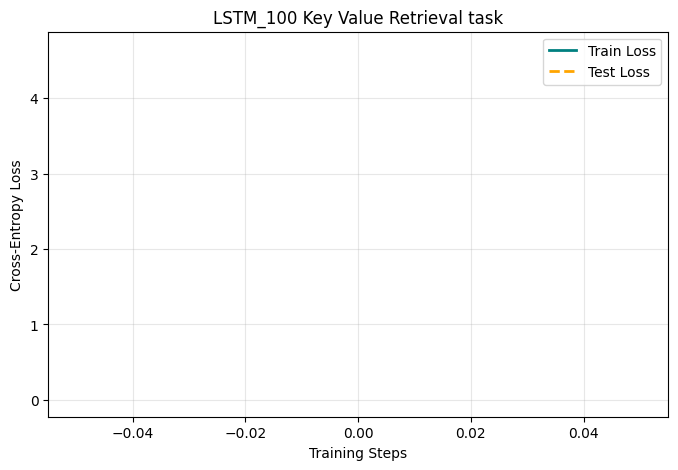

STEP: 0 | TRAIN LOSS: 0.0098 | TEST LOSS: 4.6467


  0%|          | 0/10 [00:00<?, ?it/s]

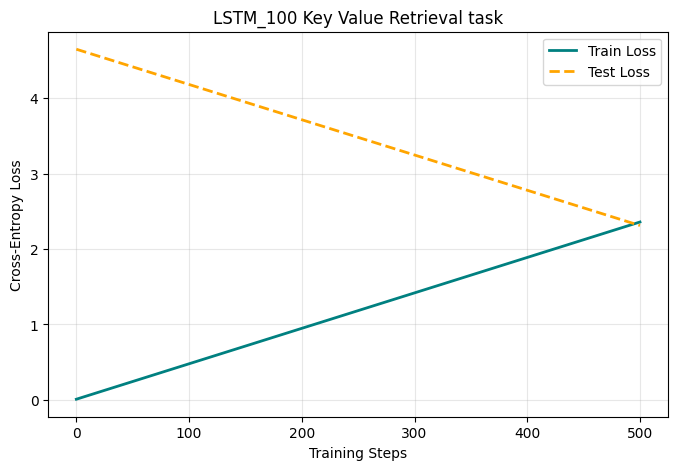

STEP: 500 | TRAIN LOSS: 2.3576 | TEST LOSS: 2.3113


  0%|          | 0/10 [00:00<?, ?it/s]

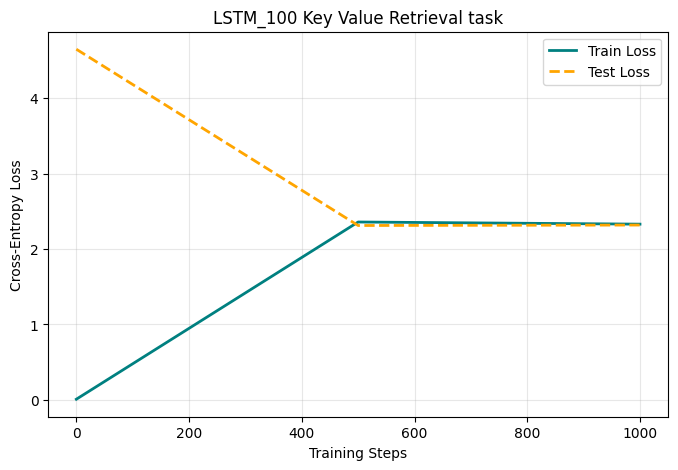

STEP: 1000 | TRAIN LOSS: 2.3292 | TEST LOSS: 2.3174


  0%|          | 0/10 [00:00<?, ?it/s]

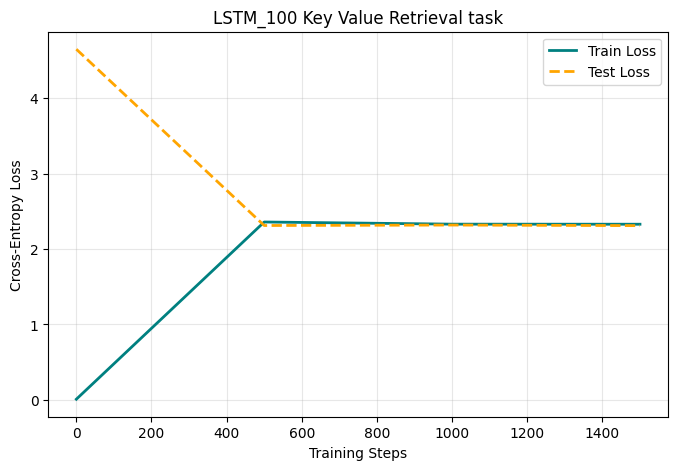

STEP: 1500 | TRAIN LOSS: 2.3282 | TEST LOSS: 2.3095


  0%|          | 0/10 [00:00<?, ?it/s]

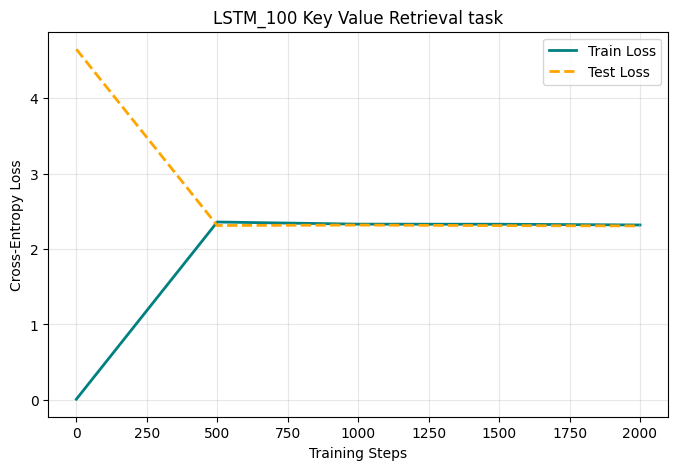

STEP: 2000 | TRAIN LOSS: 2.3184 | TEST LOSS: 2.3062


  0%|          | 0/10 [00:00<?, ?it/s]

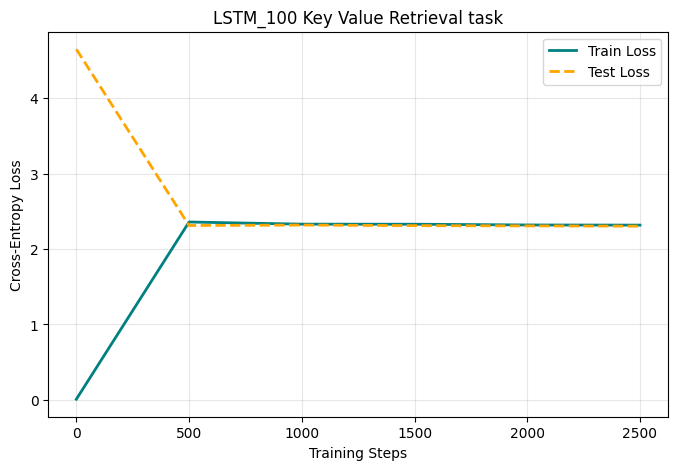

STEP: 2500 | TRAIN LOSS: 2.3164 | TEST LOSS: 2.3027


  0%|          | 0/10 [00:00<?, ?it/s]

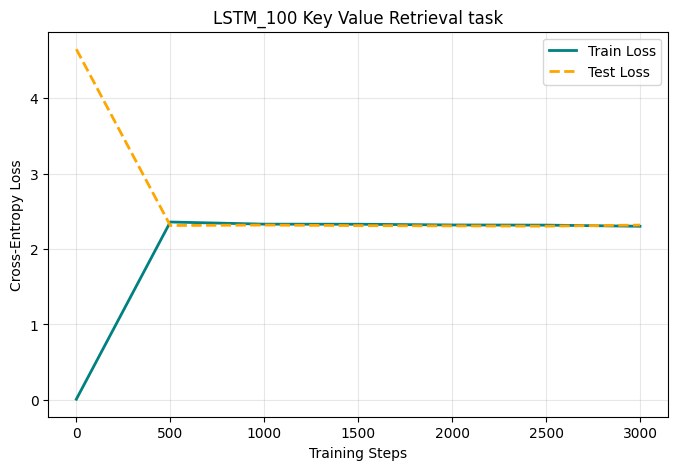

STEP: 3000 | TRAIN LOSS: 2.3013 | TEST LOSS: 2.3168


  0%|          | 0/10 [00:00<?, ?it/s]

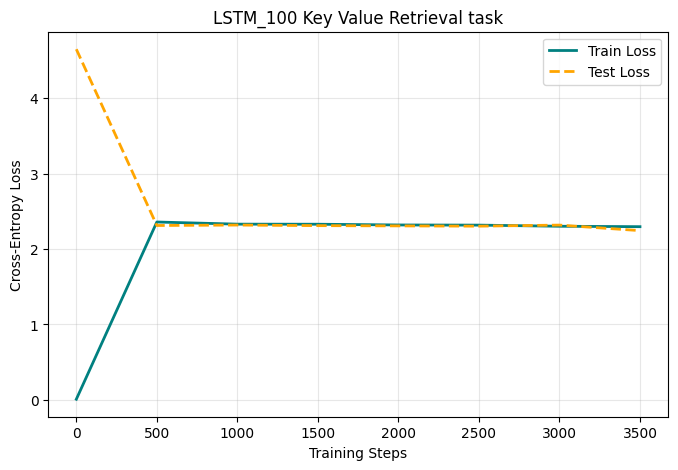

STEP: 3500 | TRAIN LOSS: 2.2957 | TEST LOSS: 2.2435


  0%|          | 0/10 [00:00<?, ?it/s]

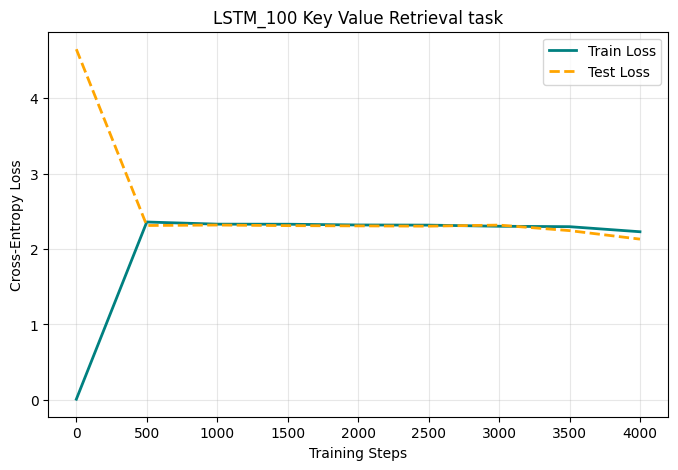

STEP: 4000 | TRAIN LOSS: 2.2286 | TEST LOSS: 2.1308


  0%|          | 0/10 [00:00<?, ?it/s]

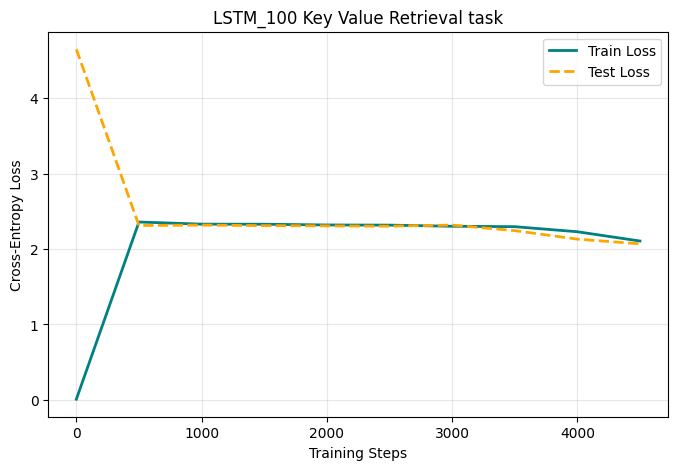

STEP: 4500 | TRAIN LOSS: 2.1056 | TEST LOSS: 2.0684


  0%|          | 0/10 [00:00<?, ?it/s]

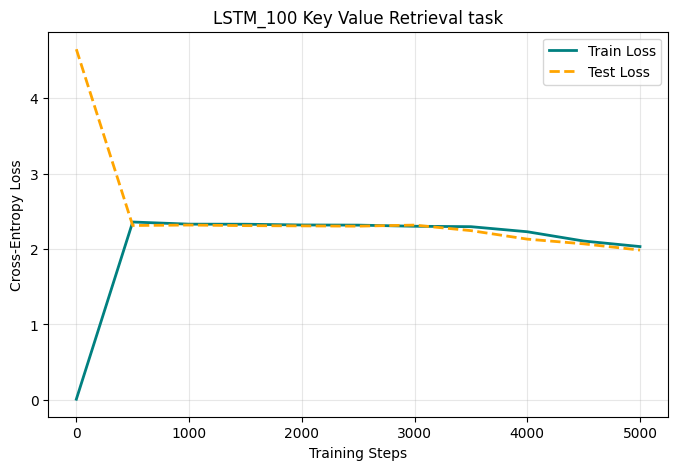

STEP: 5000 | TRAIN LOSS: 2.0322 | TEST LOSS: 1.9857


  0%|          | 0/10 [00:00<?, ?it/s]

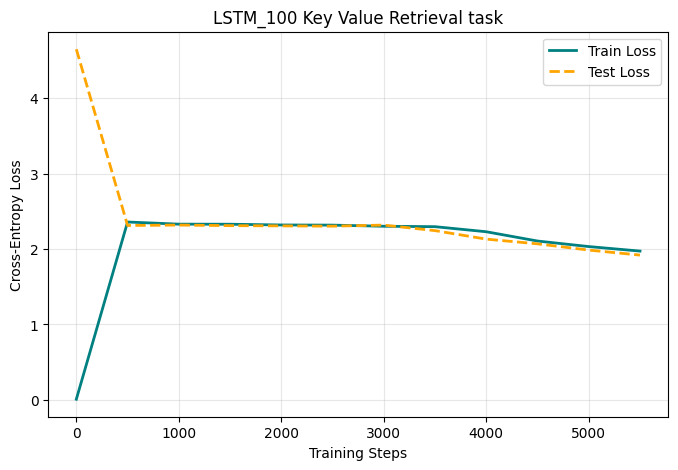

STEP: 5500 | TRAIN LOSS: 1.9723 | TEST LOSS: 1.9193


  0%|          | 0/10 [00:00<?, ?it/s]

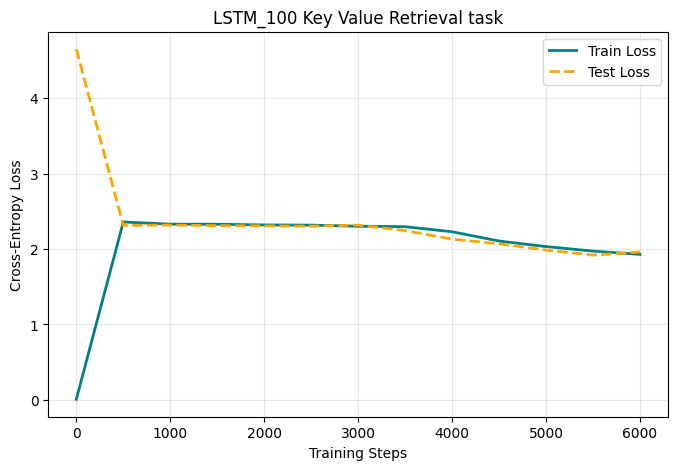

STEP: 6000 | TRAIN LOSS: 1.9287 | TEST LOSS: 1.9608


  0%|          | 0/10 [00:00<?, ?it/s]

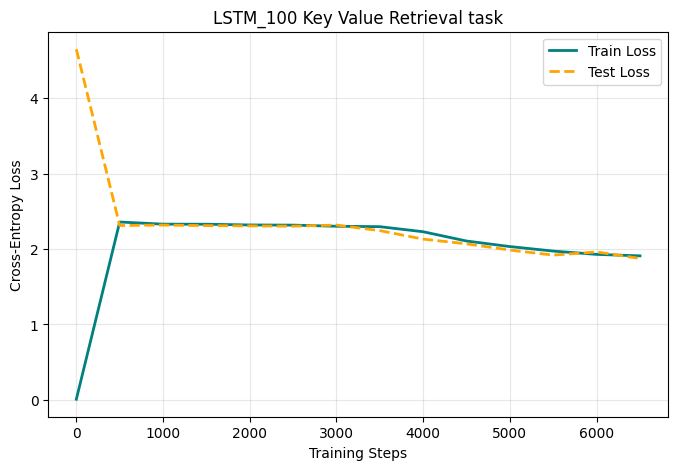

STEP: 6500 | TRAIN LOSS: 1.9092 | TEST LOSS: 1.8751


  0%|          | 0/10 [00:00<?, ?it/s]

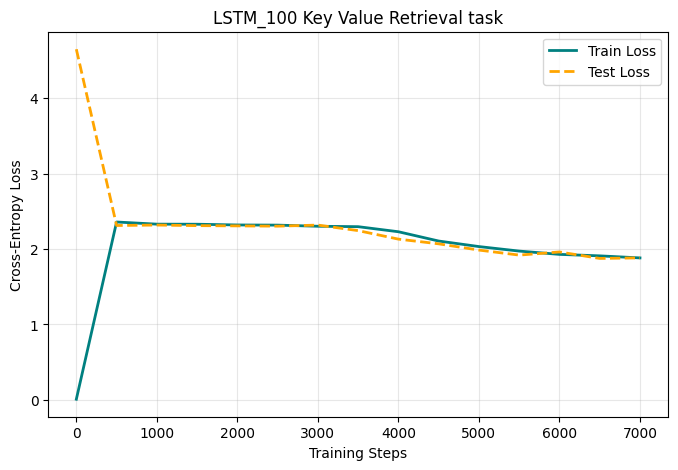

STEP: 7000 | TRAIN LOSS: 1.8820 | TEST LOSS: 1.8824


  0%|          | 0/10 [00:00<?, ?it/s]

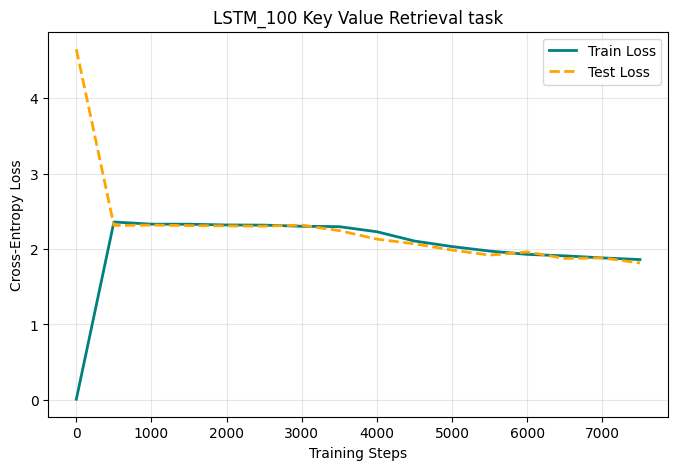

STEP: 7500 | TRAIN LOSS: 1.8601 | TEST LOSS: 1.8148


  0%|          | 0/10 [00:00<?, ?it/s]

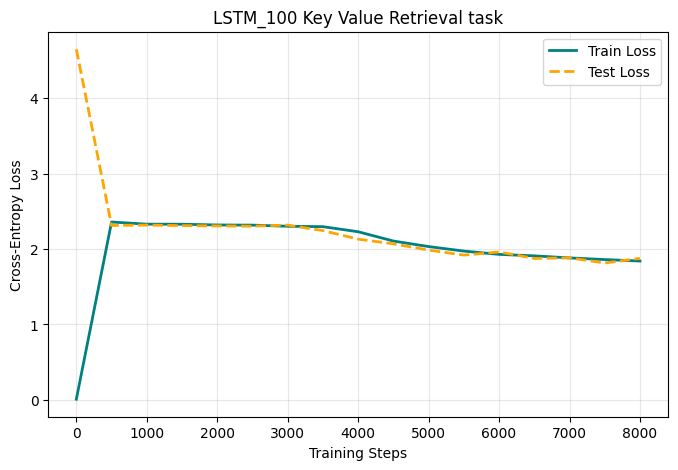

STEP: 8000 | TRAIN LOSS: 1.8404 | TEST LOSS: 1.8763


  0%|          | 0/10 [00:00<?, ?it/s]

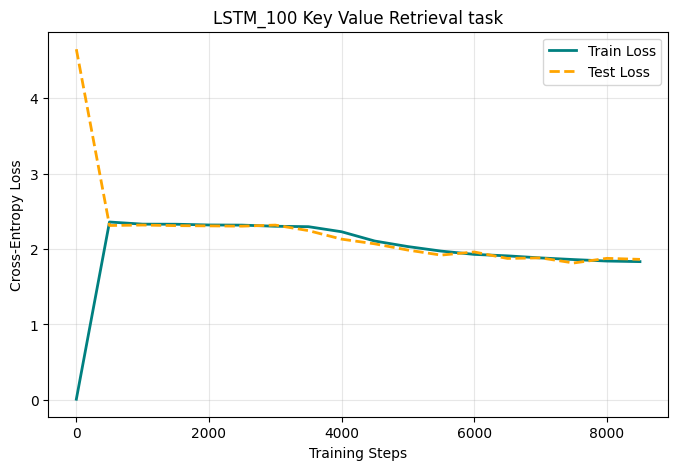

STEP: 8500 | TRAIN LOSS: 1.8328 | TEST LOSS: 1.8627


  0%|          | 0/10 [00:00<?, ?it/s]

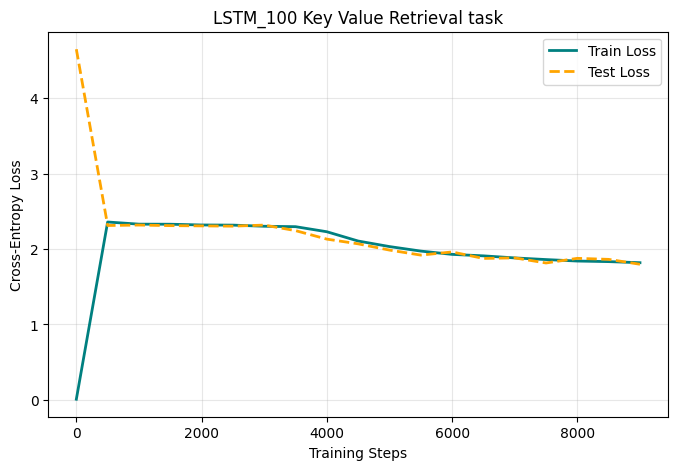

STEP: 9000 | TRAIN LOSS: 1.8185 | TEST LOSS: 1.7980


  0%|          | 0/10 [00:00<?, ?it/s]

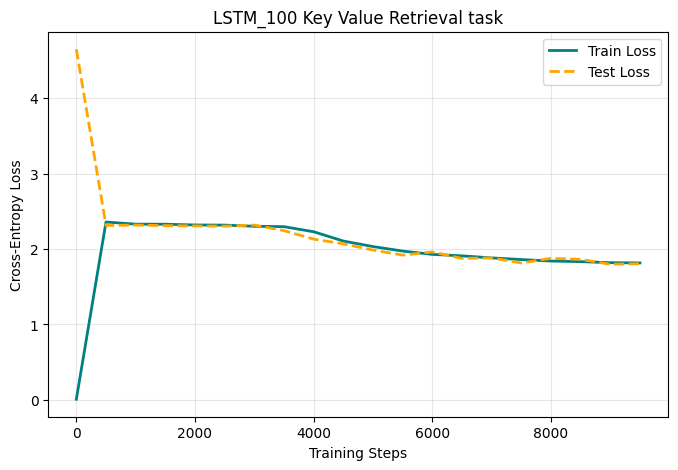

STEP: 9500 | TRAIN LOSS: 1.8157 | TEST LOSS: 1.8050


  0%|          | 0/10 [00:00<?, ?it/s]

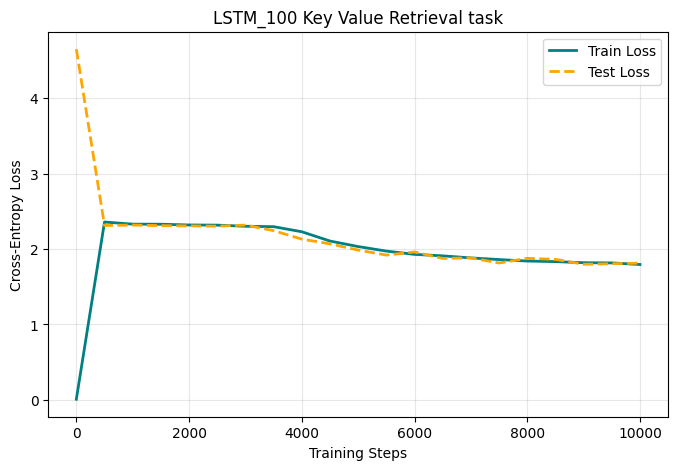

STEP: 10000 | TRAIN LOSS: 1.7947 | TEST LOSS: 1.8127


  0%|          | 0/10 [00:00<?, ?it/s]

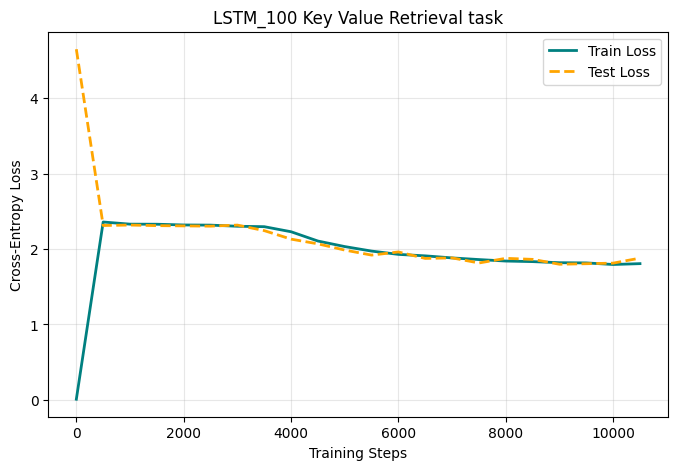

STEP: 10500 | TRAIN LOSS: 1.8060 | TEST LOSS: 1.8792


  0%|          | 0/10 [00:00<?, ?it/s]

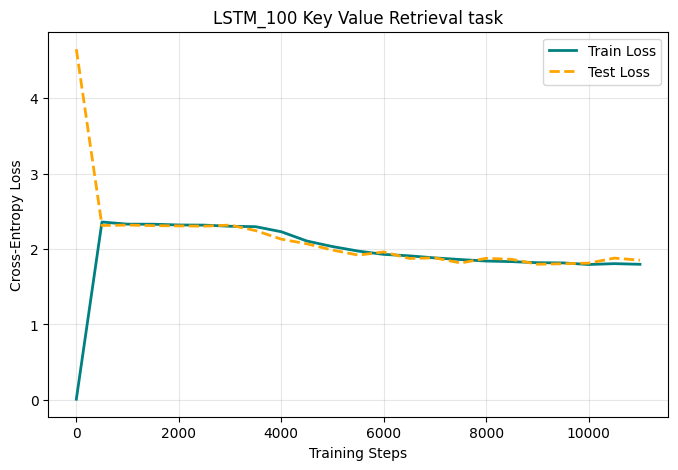

STEP: 11000 | TRAIN LOSS: 1.7973 | TEST LOSS: 1.8519


  0%|          | 0/10 [00:00<?, ?it/s]

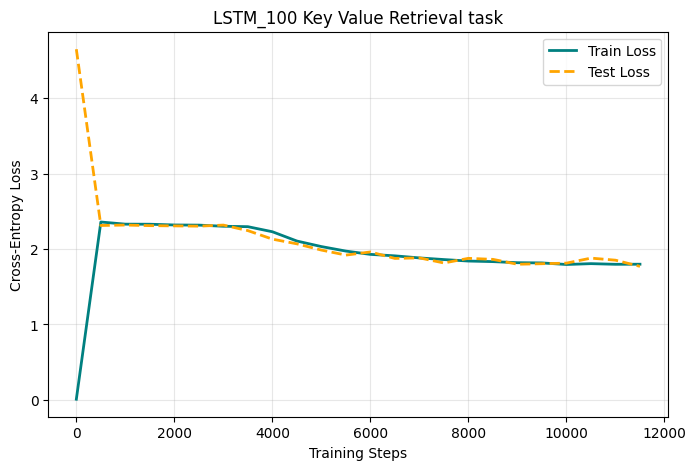

STEP: 11500 | TRAIN LOSS: 1.7984 | TEST LOSS: 1.7699


  0%|          | 0/10 [00:00<?, ?it/s]

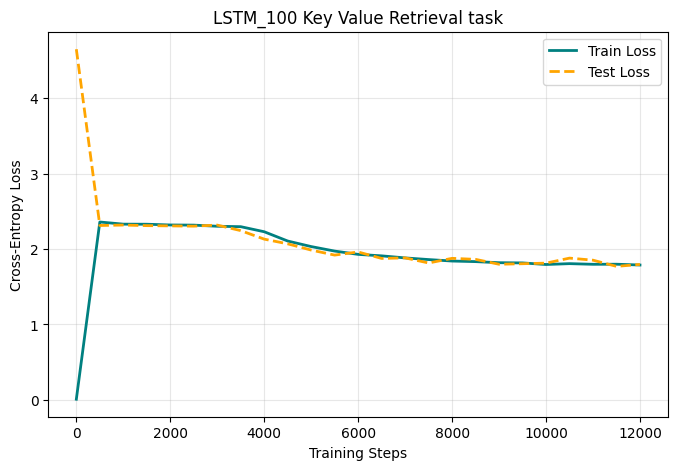

STEP: 12000 | TRAIN LOSS: 1.7878 | TEST LOSS: 1.7957


  0%|          | 0/10 [00:00<?, ?it/s]

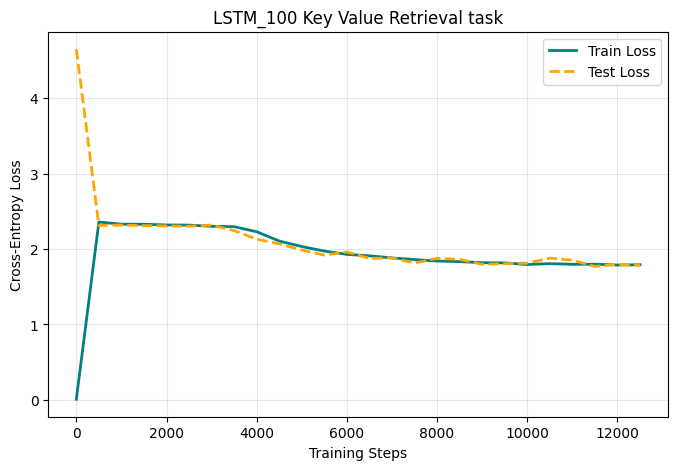

STEP: 12500 | TRAIN LOSS: 1.7911 | TEST LOSS: 1.7822


  0%|          | 0/10 [00:00<?, ?it/s]

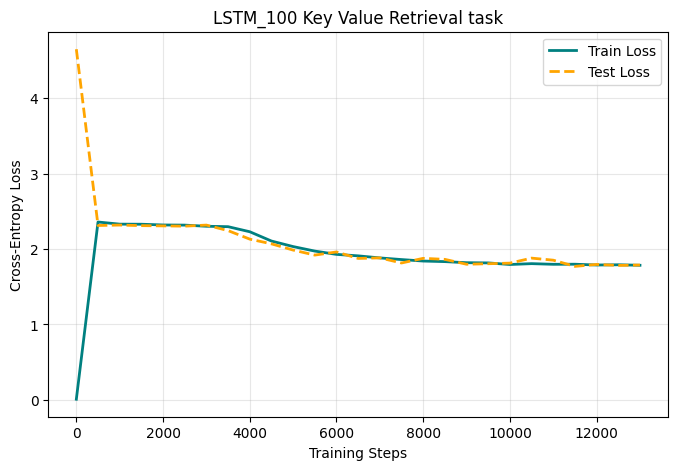

STEP: 13000 | TRAIN LOSS: 1.7844 | TEST LOSS: 1.7879


  0%|          | 0/10 [00:00<?, ?it/s]

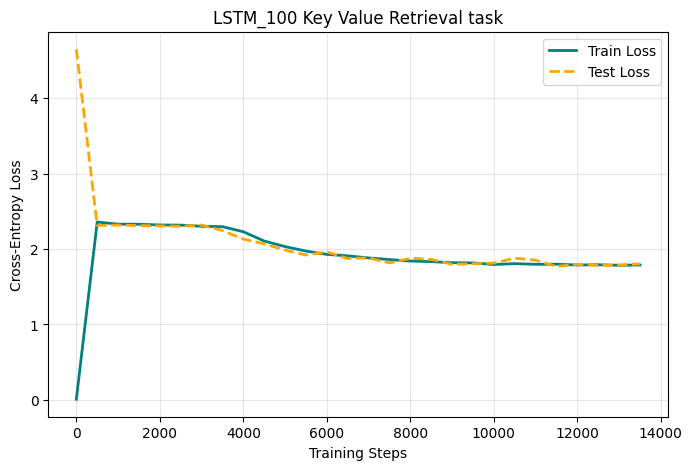

STEP: 13500 | TRAIN LOSS: 1.7884 | TEST LOSS: 1.8015


  0%|          | 0/10 [00:00<?, ?it/s]

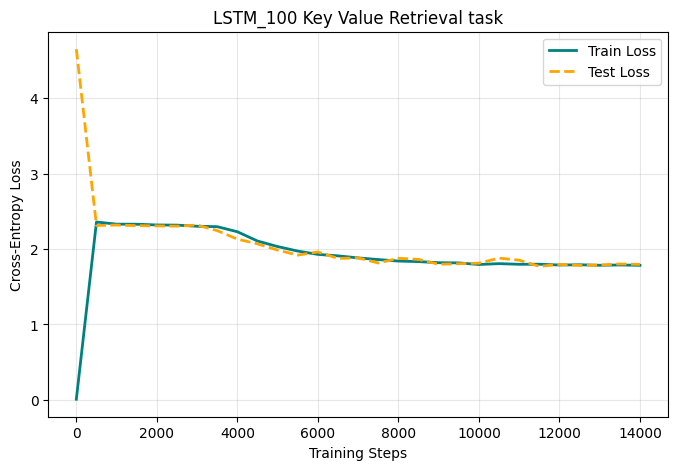

STEP: 14000 | TRAIN LOSS: 1.7837 | TEST LOSS: 1.7960


In [5]:
run_training_ex5(model=LSTM_model, 
                 batch_size=batch_size, 
                 total_batches=total_batches, 
                 test_batches=test_batches, 
                 lookup_size=copy_size, 
                 pairs=buffer_size, 
                 opt=opt_LSTM, 
                 test_break=500, 
                 model_name="LSTM_100",
                 steps_history=steps_history,
                 train_history=train_history,
                 test_history=test_history,
                 vocab=vocab)

  0%|          | 0/14001 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

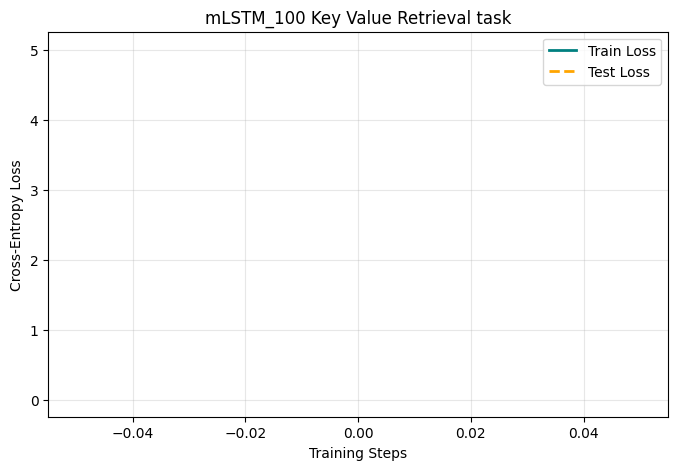

STEP: 0 | TRAIN LOSS: 0.0101 | TEST LOSS: 5.0062


  0%|          | 0/10 [00:00<?, ?it/s]

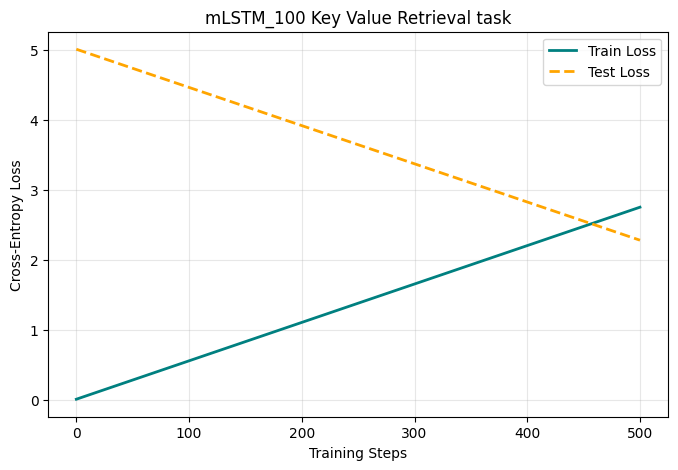

STEP: 500 | TRAIN LOSS: 2.7512 | TEST LOSS: 2.2801


  0%|          | 0/10 [00:00<?, ?it/s]

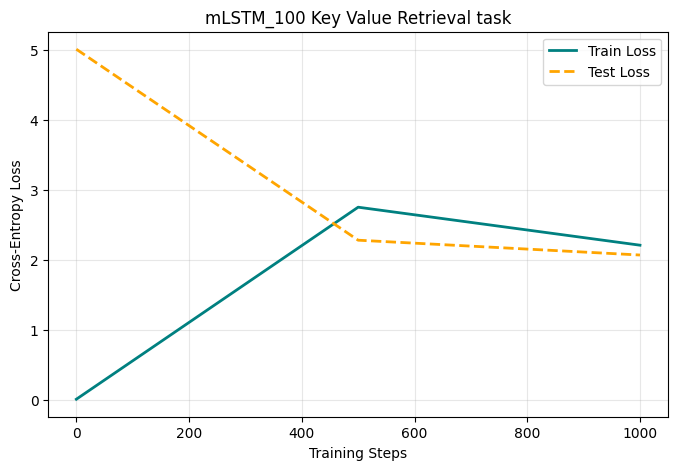

STEP: 1000 | TRAIN LOSS: 2.2088 | TEST LOSS: 2.0685


  0%|          | 0/10 [00:00<?, ?it/s]

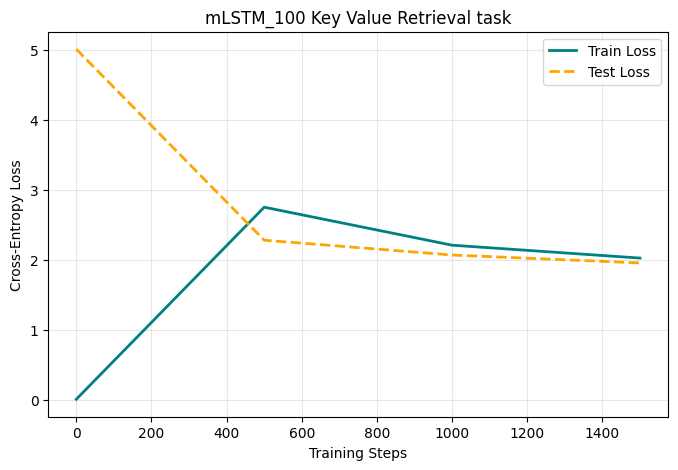

STEP: 1500 | TRAIN LOSS: 2.0249 | TEST LOSS: 1.9554


  0%|          | 0/10 [00:00<?, ?it/s]

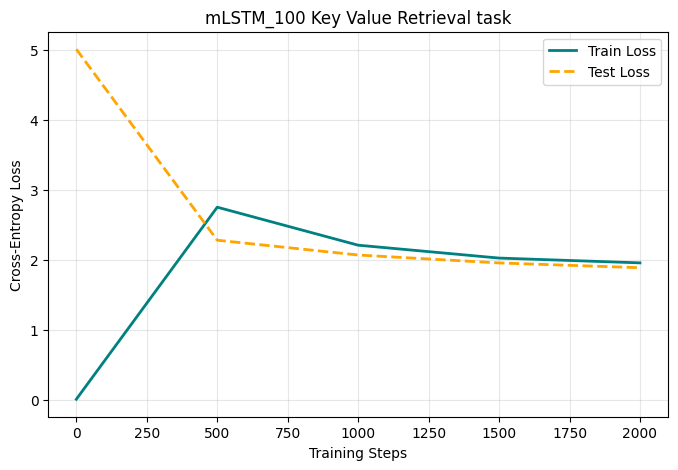

STEP: 2000 | TRAIN LOSS: 1.9565 | TEST LOSS: 1.8874


  0%|          | 0/10 [00:00<?, ?it/s]

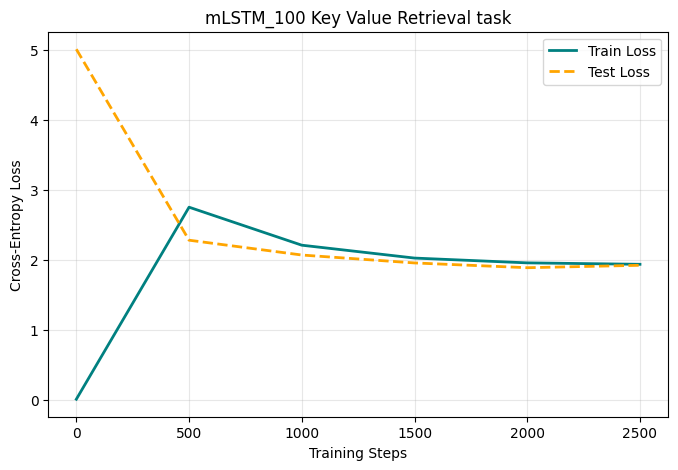

STEP: 2500 | TRAIN LOSS: 1.9360 | TEST LOSS: 1.9219


  0%|          | 0/10 [00:00<?, ?it/s]

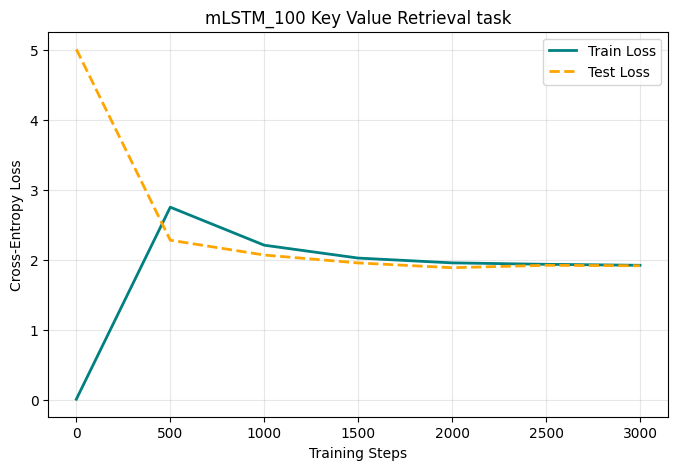

STEP: 3000 | TRAIN LOSS: 1.9217 | TEST LOSS: 1.9150


  0%|          | 0/10 [00:00<?, ?it/s]

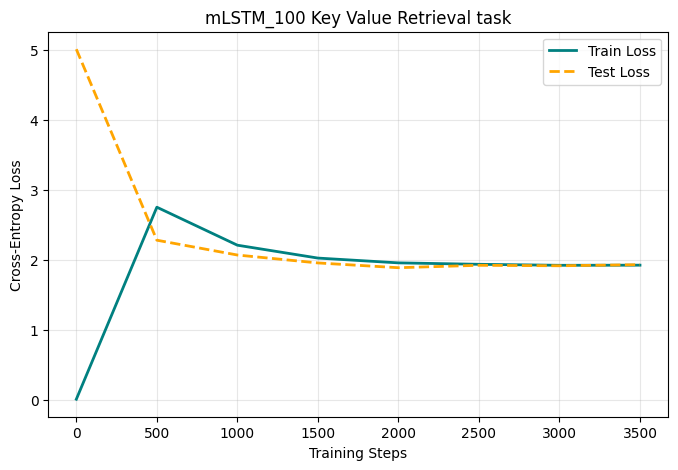

STEP: 3500 | TRAIN LOSS: 1.9236 | TEST LOSS: 1.9307


  0%|          | 0/10 [00:00<?, ?it/s]

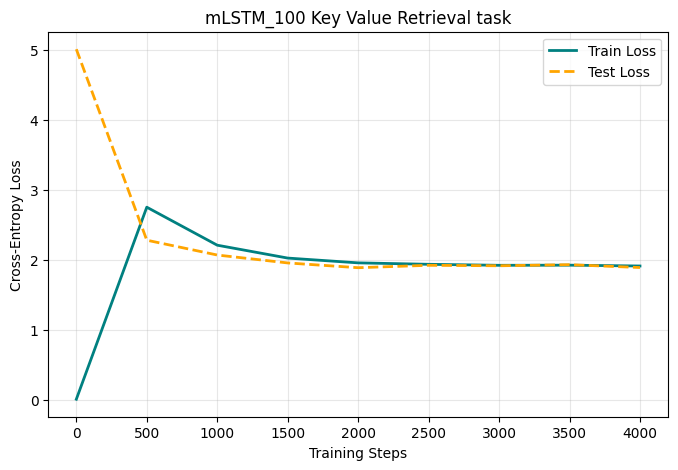

STEP: 4000 | TRAIN LOSS: 1.9117 | TEST LOSS: 1.8899


  0%|          | 0/10 [00:00<?, ?it/s]

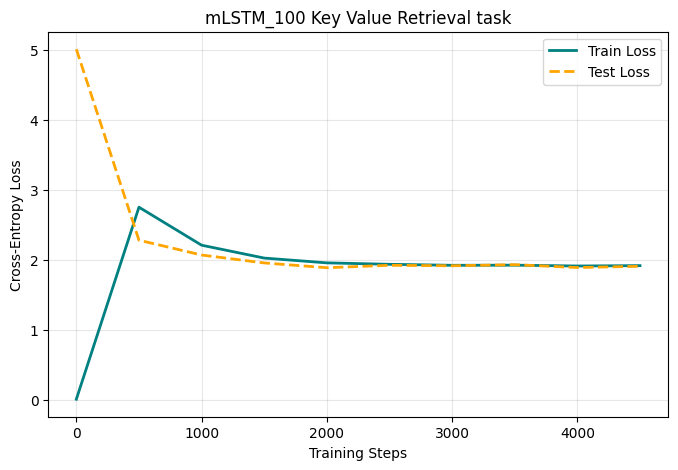

STEP: 4500 | TRAIN LOSS: 1.9171 | TEST LOSS: 1.9076


  0%|          | 0/10 [00:00<?, ?it/s]

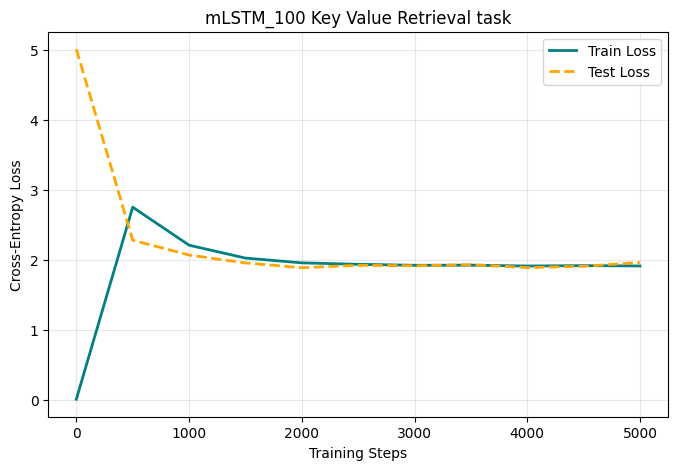

STEP: 5000 | TRAIN LOSS: 1.9124 | TEST LOSS: 1.9617


  0%|          | 0/10 [00:00<?, ?it/s]

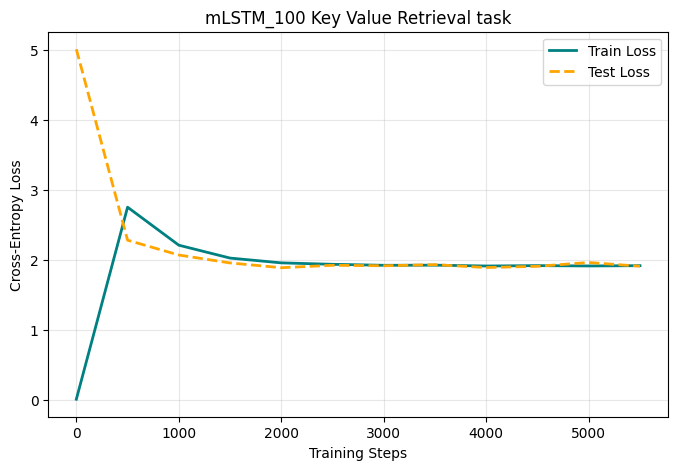

STEP: 5500 | TRAIN LOSS: 1.9165 | TEST LOSS: 1.9086


  0%|          | 0/10 [00:00<?, ?it/s]

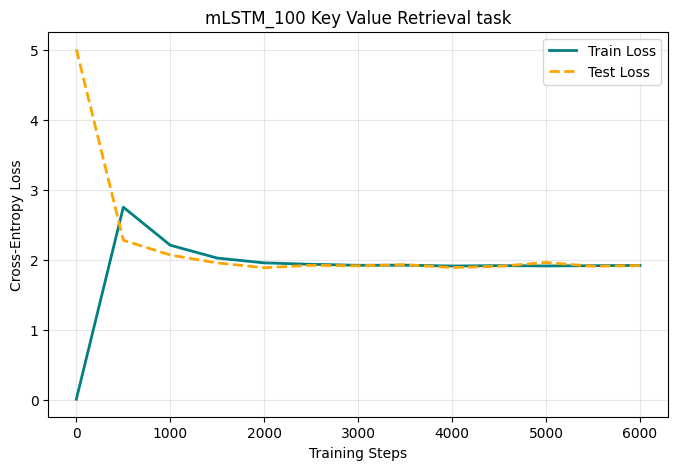

STEP: 6000 | TRAIN LOSS: 1.9197 | TEST LOSS: 1.9185


  0%|          | 0/10 [00:00<?, ?it/s]

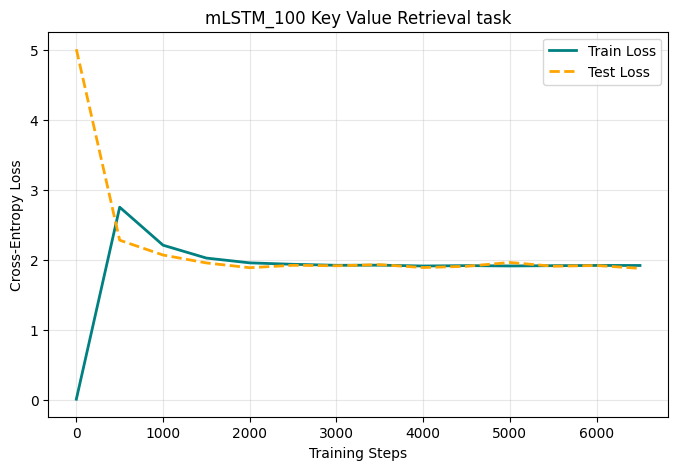

STEP: 6500 | TRAIN LOSS: 1.9193 | TEST LOSS: 1.8783


  0%|          | 0/10 [00:00<?, ?it/s]

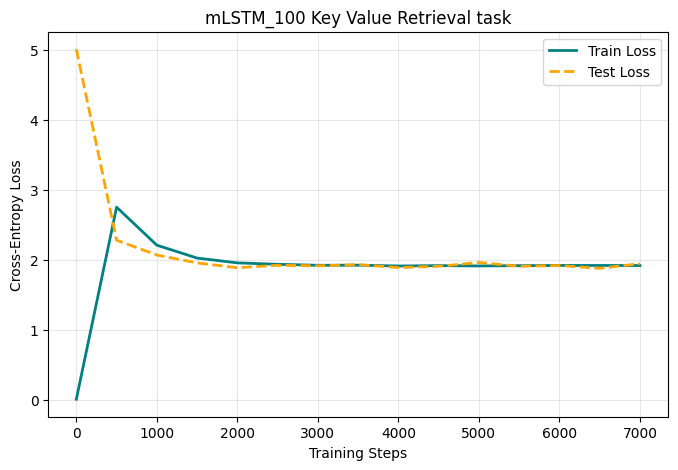

STEP: 7000 | TRAIN LOSS: 1.9183 | TEST LOSS: 1.9452


  0%|          | 0/10 [00:00<?, ?it/s]

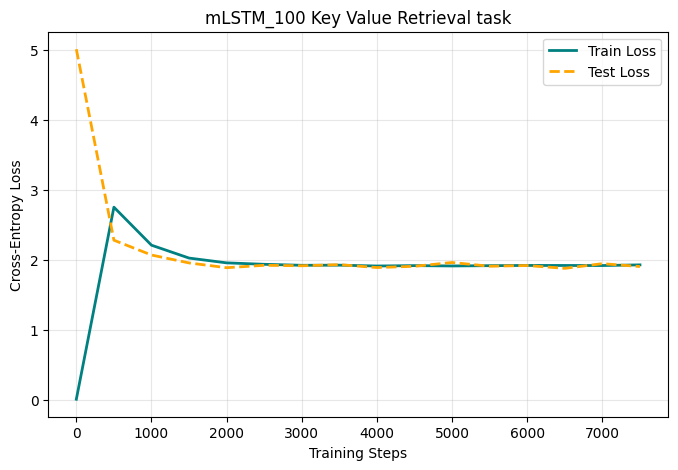

STEP: 7500 | TRAIN LOSS: 1.9278 | TEST LOSS: 1.9043


  0%|          | 0/10 [00:00<?, ?it/s]

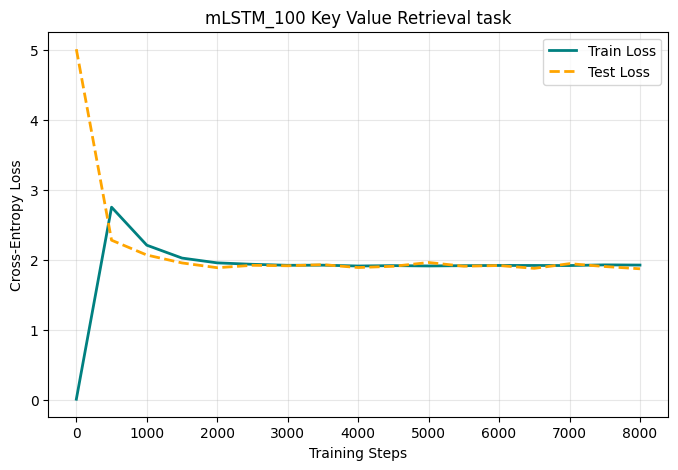

STEP: 8000 | TRAIN LOSS: 1.9250 | TEST LOSS: 1.8719


  0%|          | 0/10 [00:00<?, ?it/s]

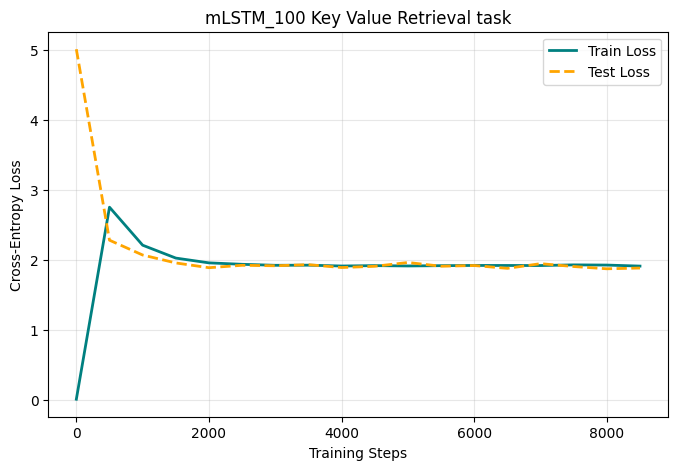

STEP: 8500 | TRAIN LOSS: 1.9104 | TEST LOSS: 1.8828


  0%|          | 0/10 [00:00<?, ?it/s]

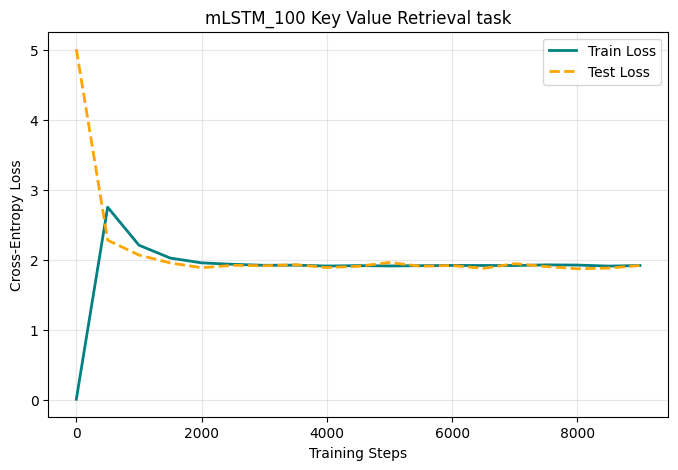

STEP: 9000 | TRAIN LOSS: 1.9186 | TEST LOSS: 1.9181


  0%|          | 0/10 [00:00<?, ?it/s]

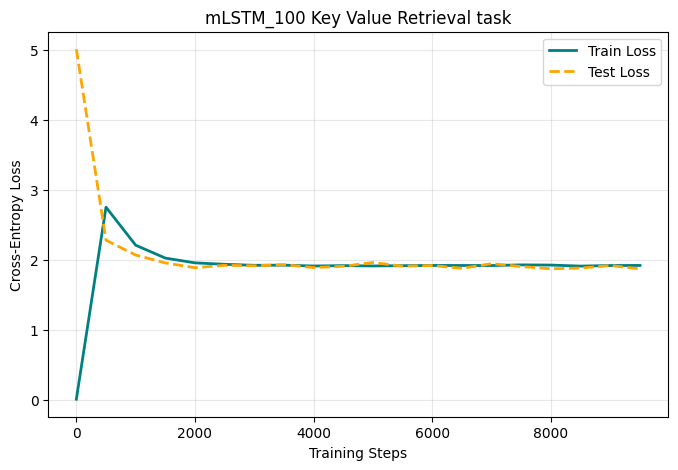

STEP: 9500 | TRAIN LOSS: 1.9198 | TEST LOSS: 1.8703


  0%|          | 0/10 [00:00<?, ?it/s]

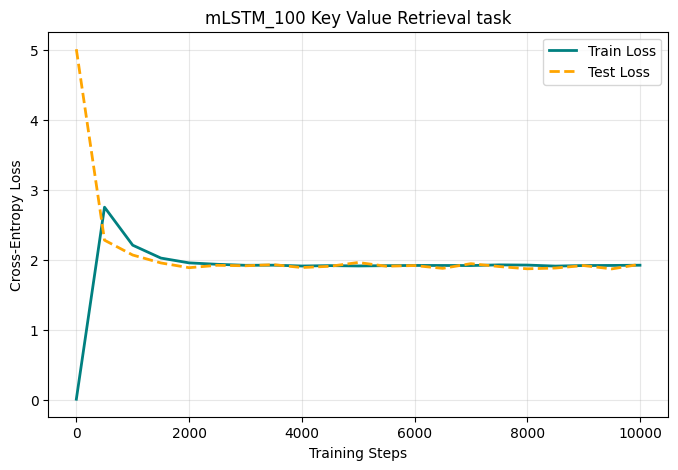

STEP: 10000 | TRAIN LOSS: 1.9230 | TEST LOSS: 1.9364


  0%|          | 0/10 [00:00<?, ?it/s]

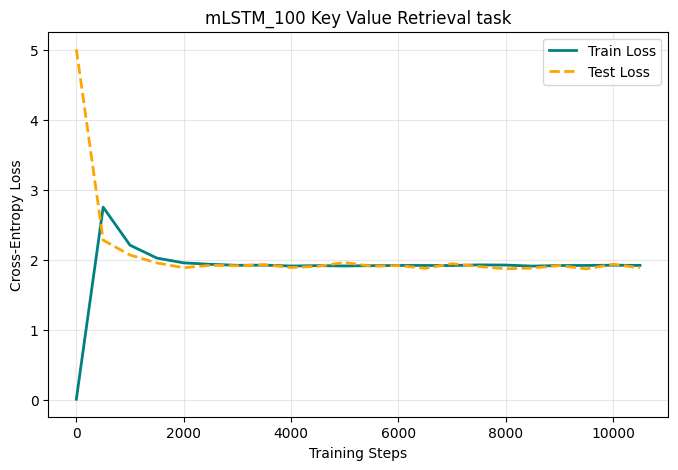

STEP: 10500 | TRAIN LOSS: 1.9202 | TEST LOSS: 1.8854


  0%|          | 0/10 [00:00<?, ?it/s]

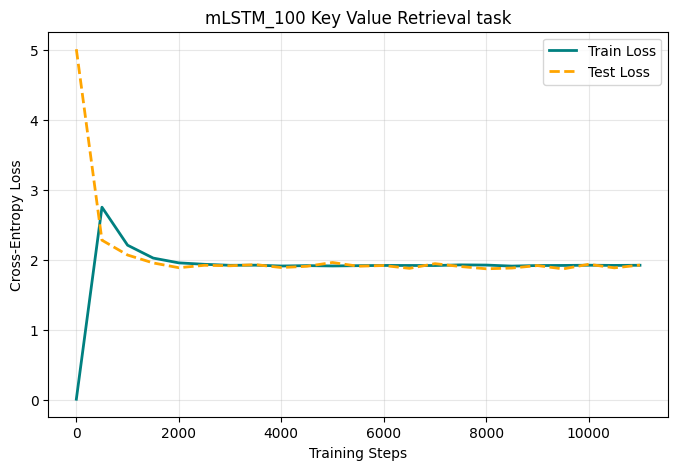

STEP: 11000 | TRAIN LOSS: 1.9224 | TEST LOSS: 1.9250


  0%|          | 0/10 [00:00<?, ?it/s]

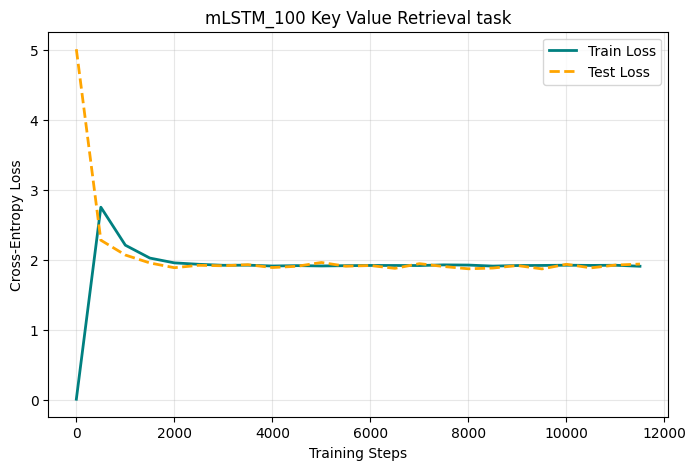

STEP: 11500 | TRAIN LOSS: 1.9082 | TEST LOSS: 1.9395


  0%|          | 0/10 [00:00<?, ?it/s]

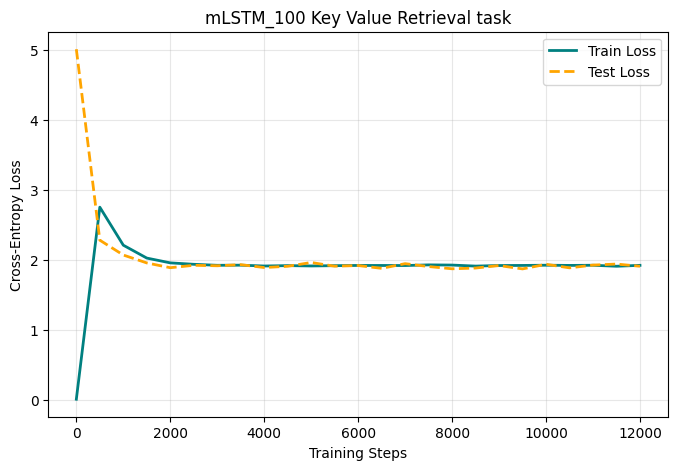

STEP: 12000 | TRAIN LOSS: 1.9213 | TEST LOSS: 1.9081


  0%|          | 0/10 [00:00<?, ?it/s]

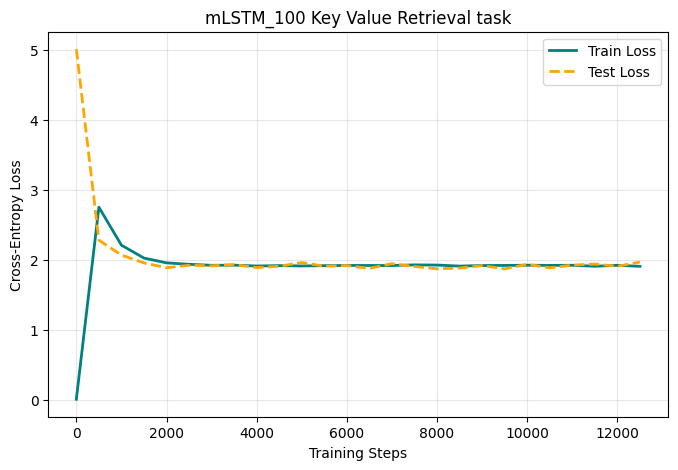

STEP: 12500 | TRAIN LOSS: 1.9071 | TEST LOSS: 1.9680


  0%|          | 0/10 [00:00<?, ?it/s]

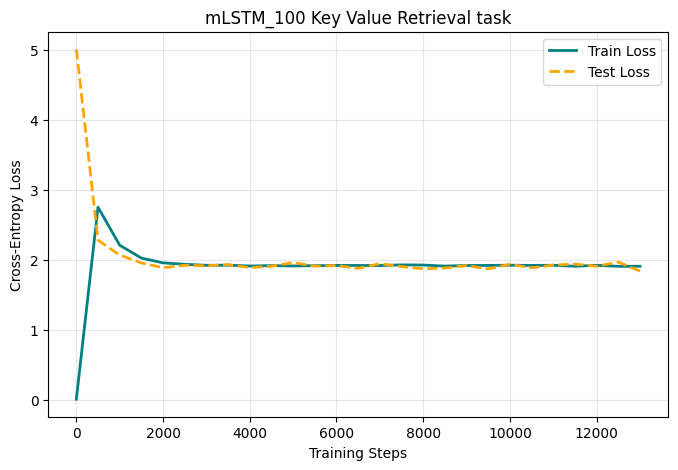

STEP: 13000 | TRAIN LOSS: 1.9082 | TEST LOSS: 1.8393


  0%|          | 0/10 [00:00<?, ?it/s]

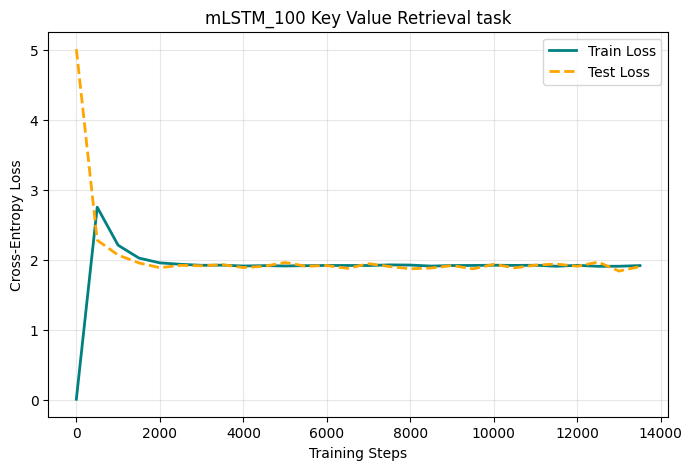

STEP: 13500 | TRAIN LOSS: 1.9179 | TEST LOSS: 1.9040


  0%|          | 0/10 [00:00<?, ?it/s]

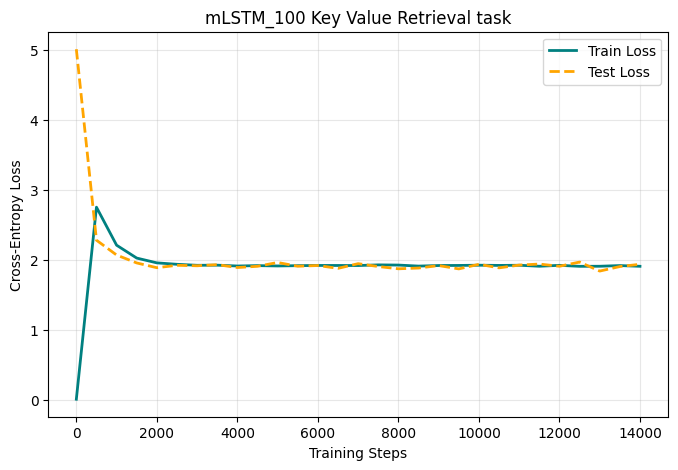

STEP: 14000 | TRAIN LOSS: 1.9076 | TEST LOSS: 1.9361


In [ ]:
steps_history = []
train_history = []
test_history = []

run_training_ex5(model=mLSTM_model, 
                 batch_size=batch_size, 
                 total_batches=total_batches, 
                 test_batches=test_batches, 
                 lookup_size=copy_size, 
                 pairs=buffer_size, 
                 opt=opt_mLSTM, 
                 test_break=500, 
                 model_name="mLSTM_100",
                 steps_history=steps_history,
                 train_history=train_history,
                 test_history=test_history,
                 vocab=vocab)

  0%|          | 0/14001 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

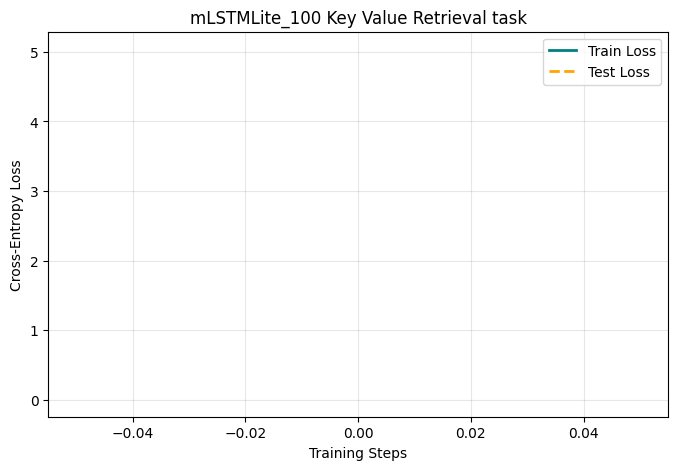

STEP: 0 | TRAIN LOSS: 0.0101 | TEST LOSS: 5.0374


  0%|          | 0/10 [00:00<?, ?it/s]

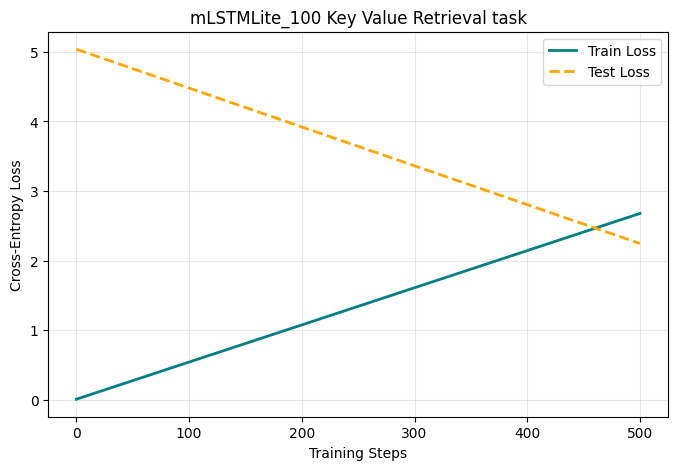

STEP: 500 | TRAIN LOSS: 2.6785 | TEST LOSS: 2.2468


  0%|          | 0/10 [00:00<?, ?it/s]

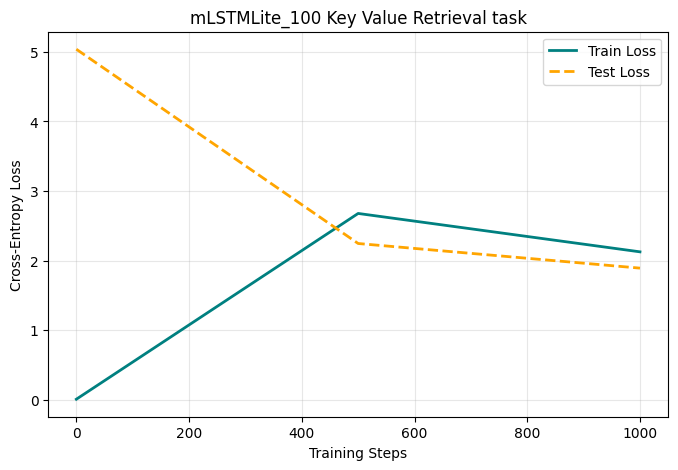

STEP: 1000 | TRAIN LOSS: 2.1271 | TEST LOSS: 1.8931


  0%|          | 0/10 [00:00<?, ?it/s]

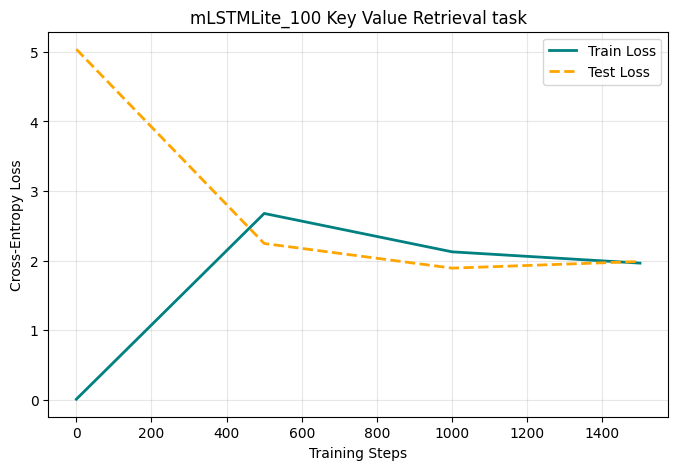

STEP: 1500 | TRAIN LOSS: 1.9649 | TEST LOSS: 1.9886


  0%|          | 0/10 [00:00<?, ?it/s]

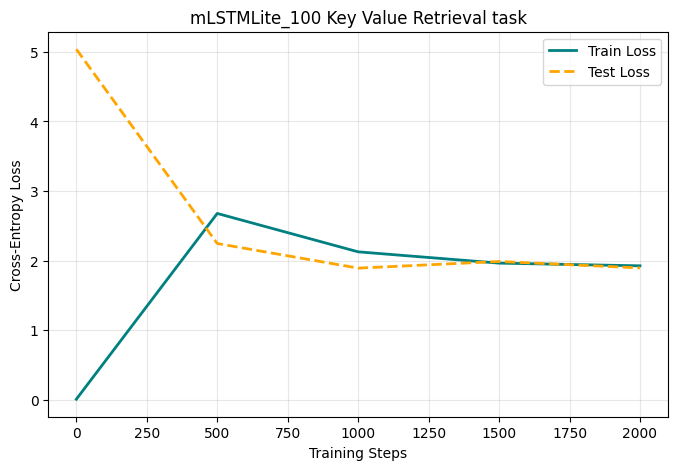

STEP: 2000 | TRAIN LOSS: 1.9262 | TEST LOSS: 1.8960


  0%|          | 0/10 [00:00<?, ?it/s]

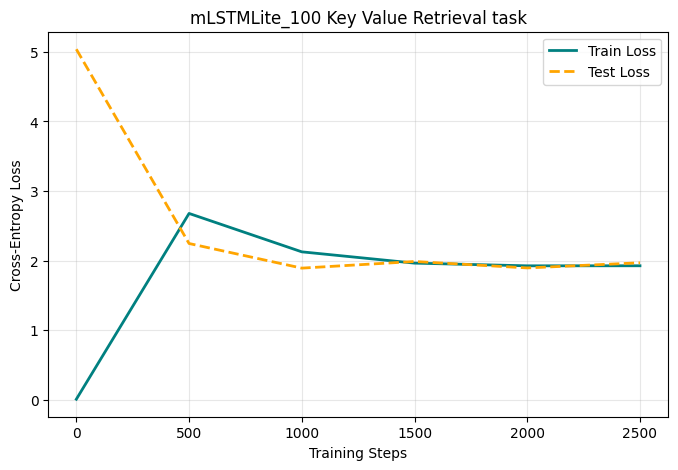

STEP: 2500 | TRAIN LOSS: 1.9270 | TEST LOSS: 1.9699


  0%|          | 0/10 [00:00<?, ?it/s]

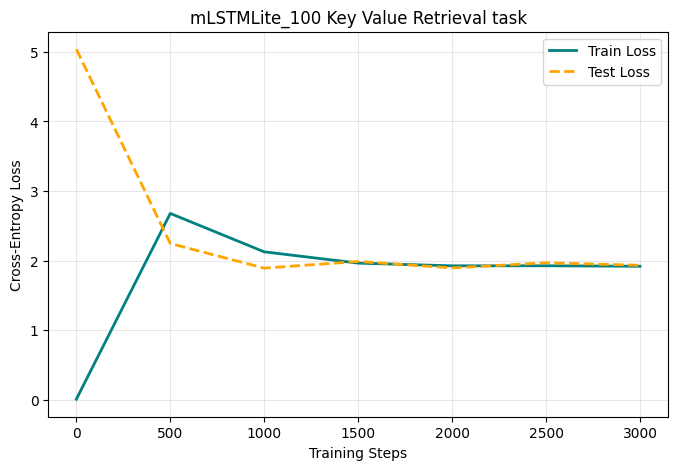

STEP: 3000 | TRAIN LOSS: 1.9200 | TEST LOSS: 1.9340


  0%|          | 0/10 [00:00<?, ?it/s]

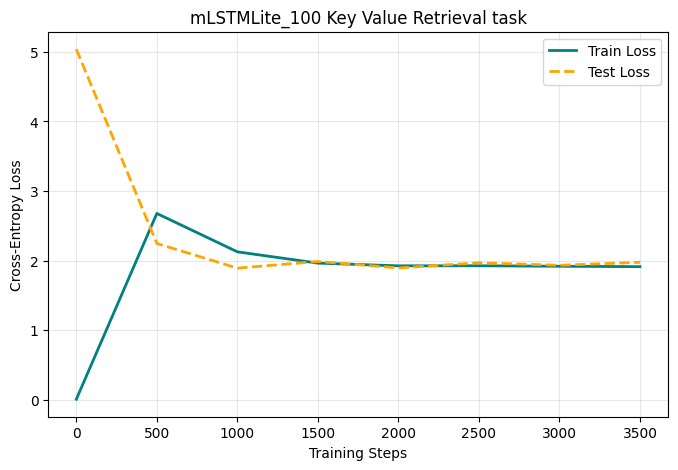

STEP: 3500 | TRAIN LOSS: 1.9142 | TEST LOSS: 1.9774


  0%|          | 0/10 [00:00<?, ?it/s]

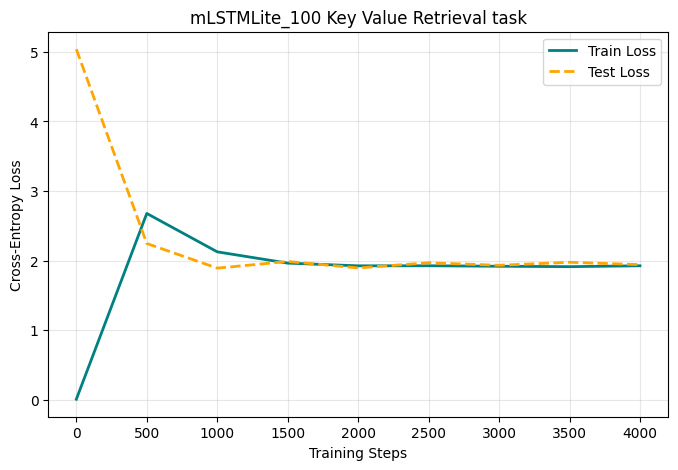

STEP: 4000 | TRAIN LOSS: 1.9266 | TEST LOSS: 1.9435


  0%|          | 0/10 [00:00<?, ?it/s]

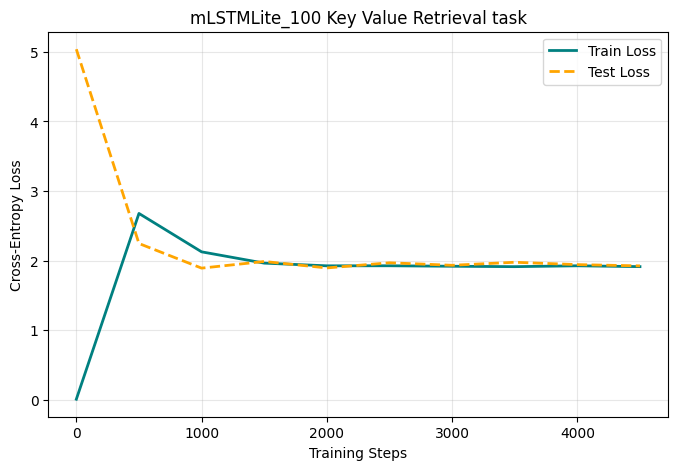

STEP: 4500 | TRAIN LOSS: 1.9145 | TEST LOSS: 1.9254


  0%|          | 0/10 [00:00<?, ?it/s]

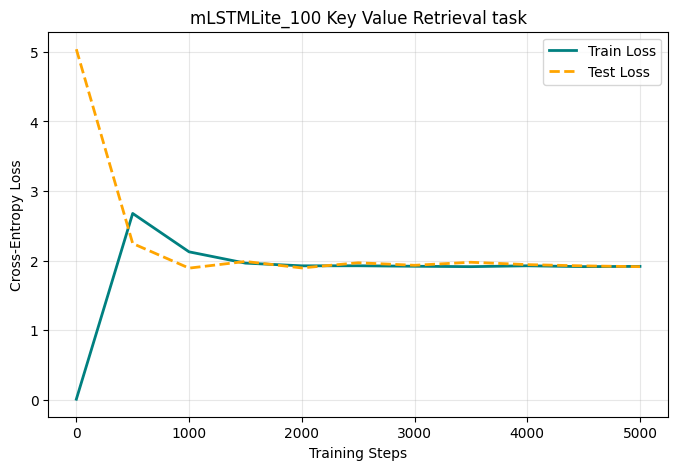

STEP: 5000 | TRAIN LOSS: 1.9183 | TEST LOSS: 1.9141


  0%|          | 0/10 [00:00<?, ?it/s]

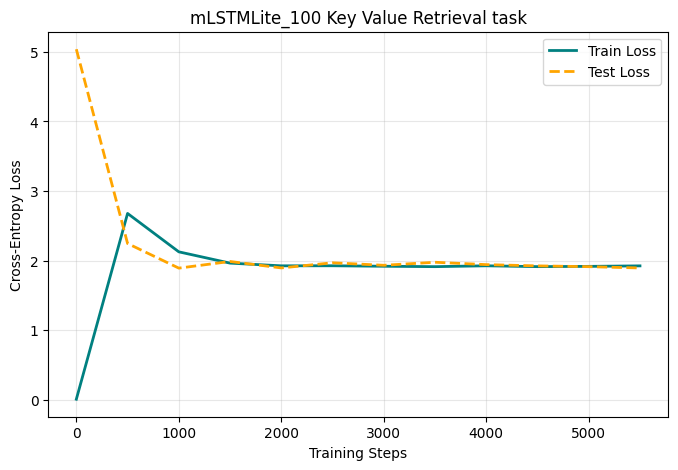

STEP: 5500 | TRAIN LOSS: 1.9256 | TEST LOSS: 1.8954


  0%|          | 0/10 [00:00<?, ?it/s]

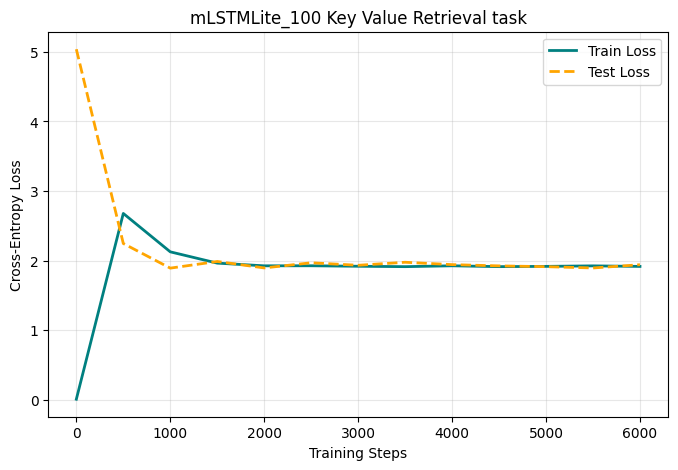

STEP: 6000 | TRAIN LOSS: 1.9177 | TEST LOSS: 1.9420


  0%|          | 0/10 [00:00<?, ?it/s]

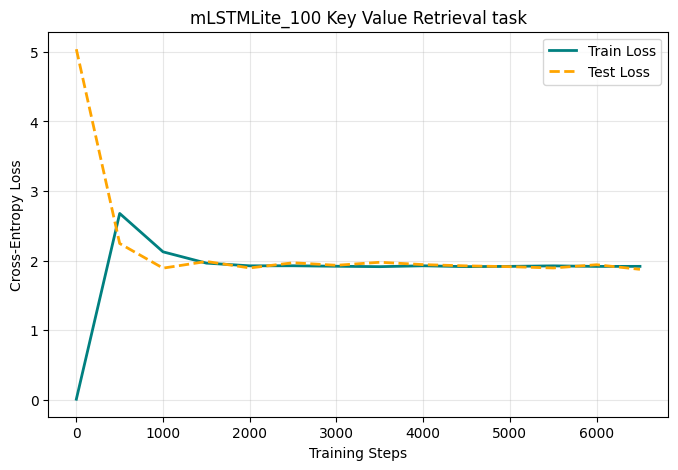

STEP: 6500 | TRAIN LOSS: 1.9186 | TEST LOSS: 1.8758


  0%|          | 0/10 [00:00<?, ?it/s]

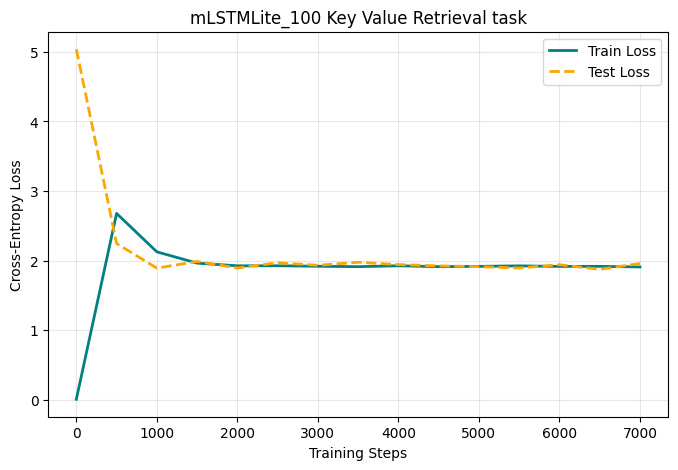

STEP: 7000 | TRAIN LOSS: 1.9097 | TEST LOSS: 1.9597


  0%|          | 0/10 [00:00<?, ?it/s]

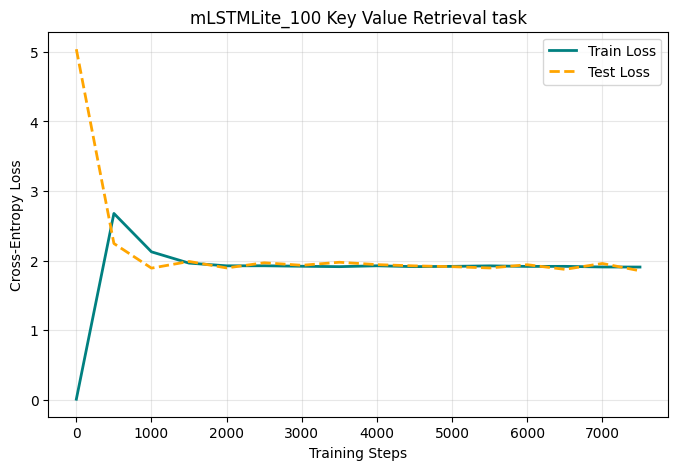

STEP: 7500 | TRAIN LOSS: 1.9087 | TEST LOSS: 1.8547


  0%|          | 0/10 [00:00<?, ?it/s]

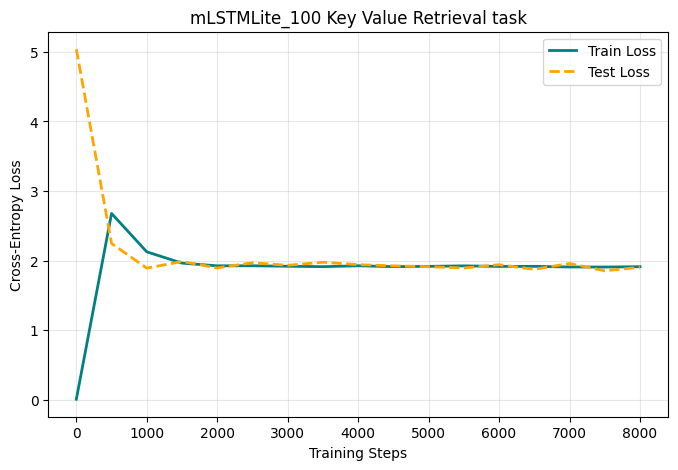

STEP: 8000 | TRAIN LOSS: 1.9140 | TEST LOSS: 1.9056


  0%|          | 0/10 [00:00<?, ?it/s]

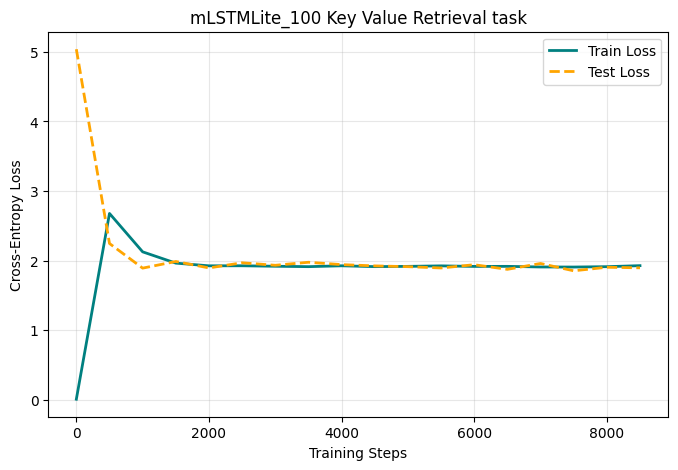

STEP: 8500 | TRAIN LOSS: 1.9285 | TEST LOSS: 1.8974


  0%|          | 0/10 [00:00<?, ?it/s]

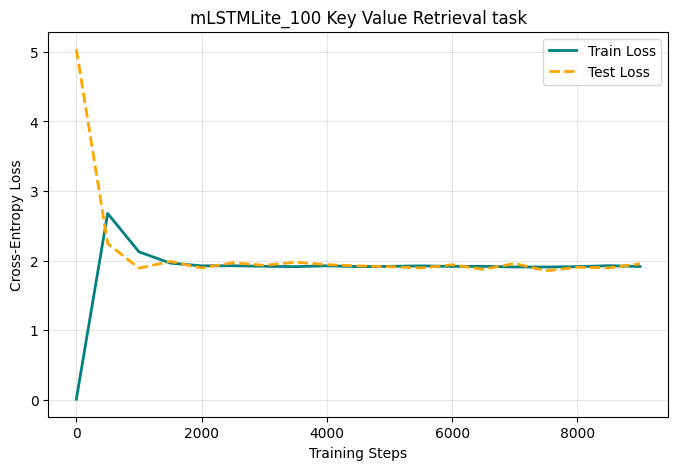

STEP: 9000 | TRAIN LOSS: 1.9164 | TEST LOSS: 1.9555


  0%|          | 0/10 [00:00<?, ?it/s]

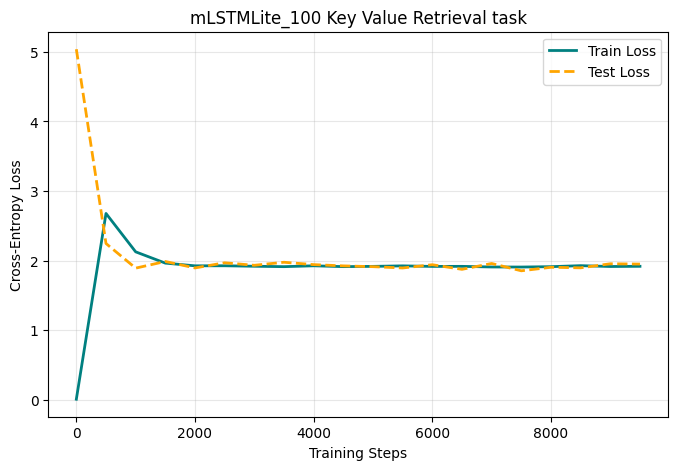

STEP: 9500 | TRAIN LOSS: 1.9192 | TEST LOSS: 1.9512


  0%|          | 0/10 [00:00<?, ?it/s]

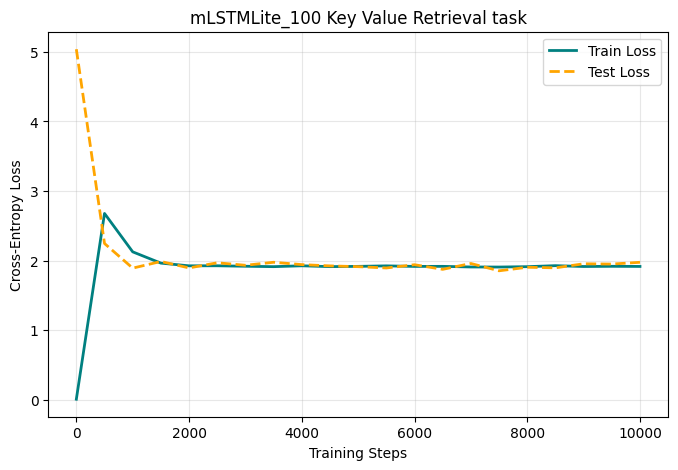

STEP: 10000 | TRAIN LOSS: 1.9174 | TEST LOSS: 1.9770


  0%|          | 0/10 [00:00<?, ?it/s]

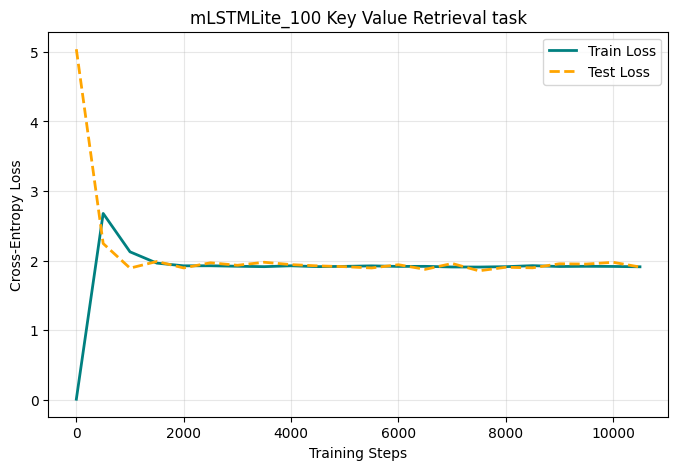

STEP: 10500 | TRAIN LOSS: 1.9124 | TEST LOSS: 1.9087


  0%|          | 0/10 [00:00<?, ?it/s]

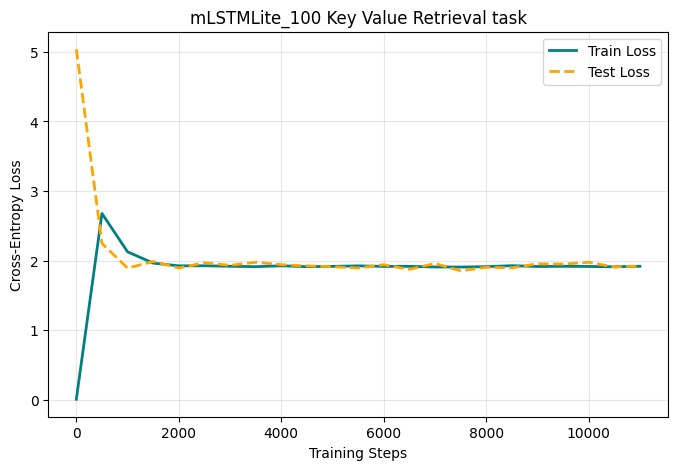

STEP: 11000 | TRAIN LOSS: 1.9199 | TEST LOSS: 1.9238


  0%|          | 0/10 [00:00<?, ?it/s]

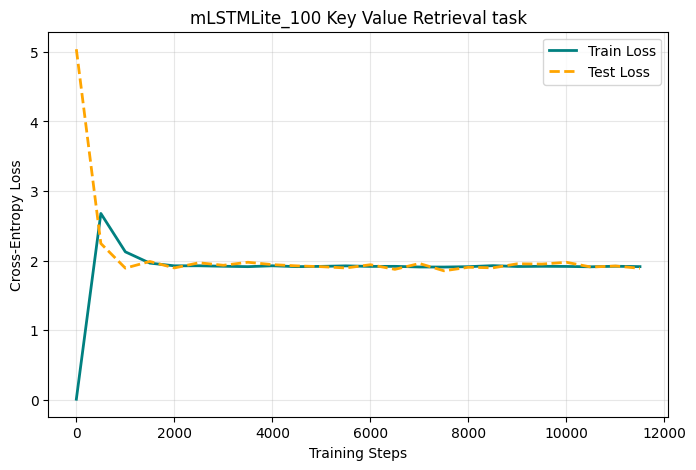

STEP: 11500 | TRAIN LOSS: 1.9148 | TEST LOSS: 1.8904


  0%|          | 0/10 [00:00<?, ?it/s]

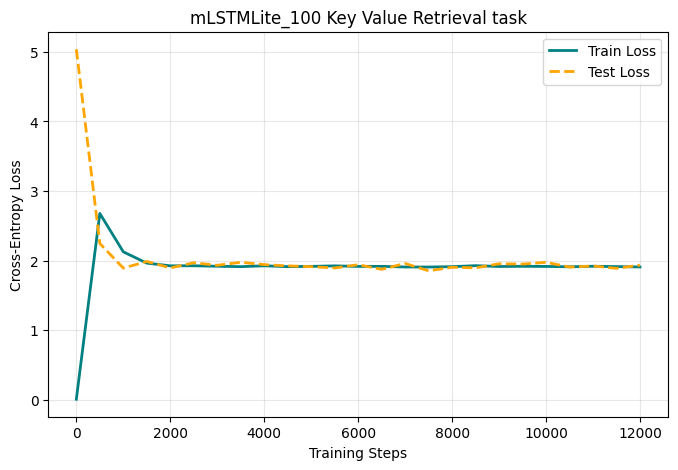

STEP: 12000 | TRAIN LOSS: 1.9098 | TEST LOSS: 1.9358


  0%|          | 0/10 [00:00<?, ?it/s]

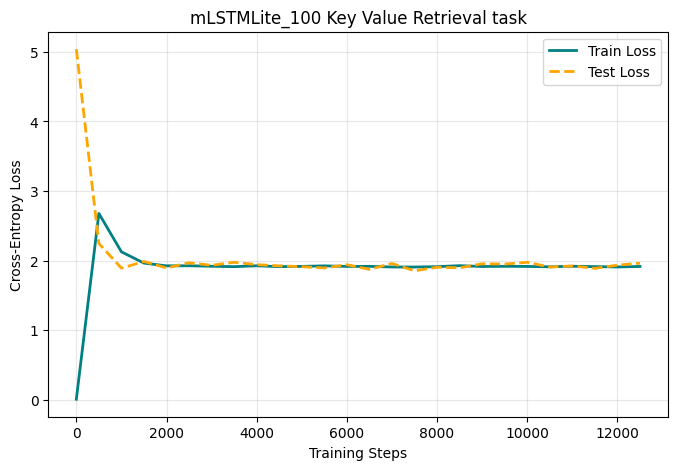

STEP: 12500 | TRAIN LOSS: 1.9171 | TEST LOSS: 1.9646


  0%|          | 0/10 [00:00<?, ?it/s]

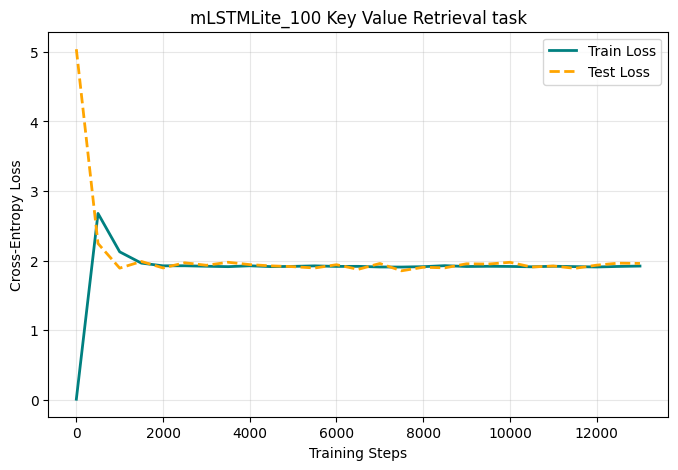

STEP: 13000 | TRAIN LOSS: 1.9228 | TEST LOSS: 1.9605


  0%|          | 0/10 [00:00<?, ?it/s]

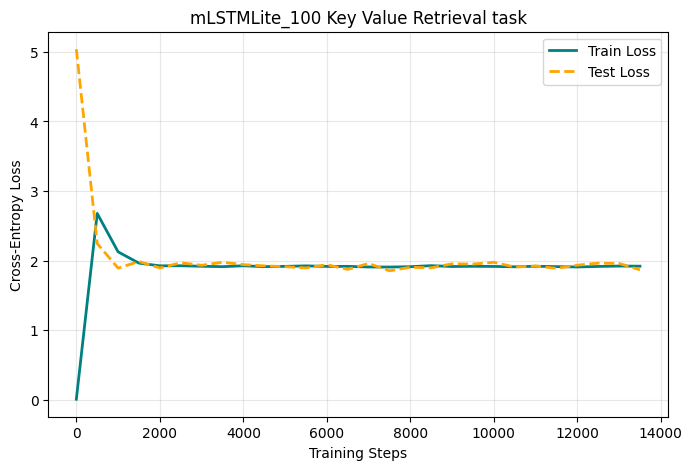

STEP: 13500 | TRAIN LOSS: 1.9211 | TEST LOSS: 1.8678


  0%|          | 0/10 [00:00<?, ?it/s]

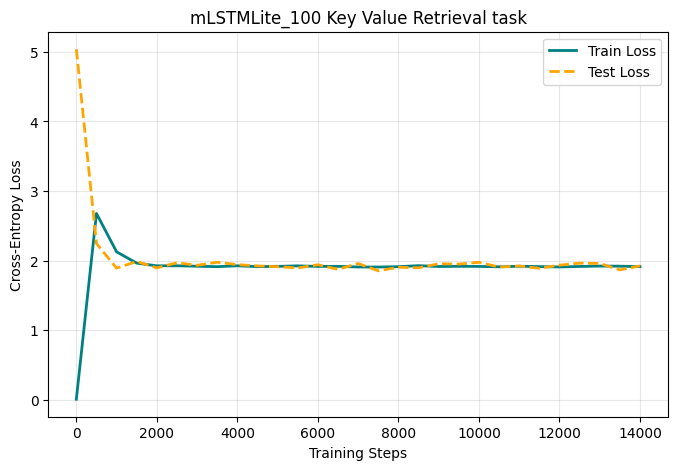

STEP: 14000 | TRAIN LOSS: 1.9142 | TEST LOSS: 1.9254


In [6]:
steps_history = []
train_history = []
test_history = []


run_training_ex5(model=mLSTMLite_model, 
                 batch_size=batch_size, 
                 total_batches=total_batches, 
                 test_batches=test_batches, 
                 lookup_size=copy_size, 
                 pairs=buffer_size, 
                 opt=opt_mLSTMLite, 
                 test_break=500, 
                 model_name="mLSTMLite_100",
                 steps_history=steps_history,
                 train_history=train_history,
                 test_history=test_history,
                 vocab=vocab)

  0%|          | 0/14001 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

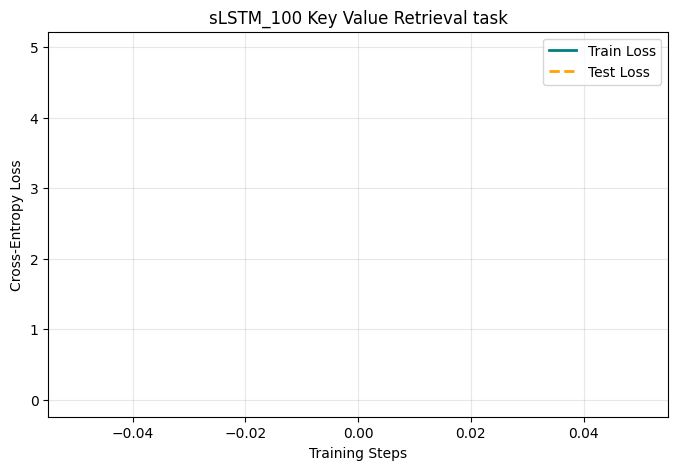

STEP: 0 | TRAIN LOSS: 0.0099 | TEST LOSS: 4.9709


  0%|          | 0/10 [00:00<?, ?it/s]

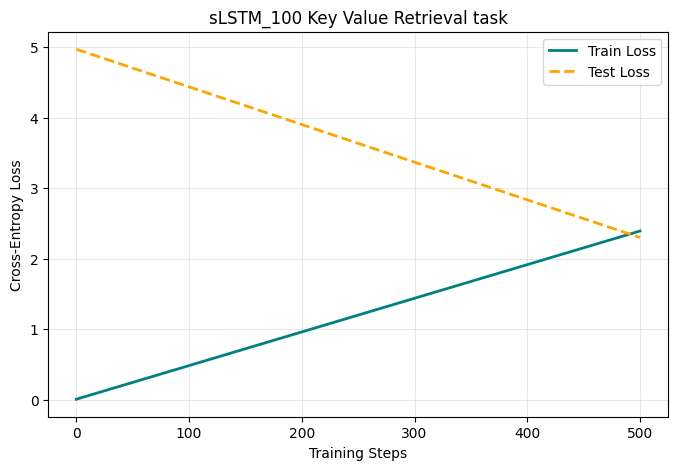

STEP: 500 | TRAIN LOSS: 2.3944 | TEST LOSS: 2.3029


  0%|          | 0/10 [00:00<?, ?it/s]

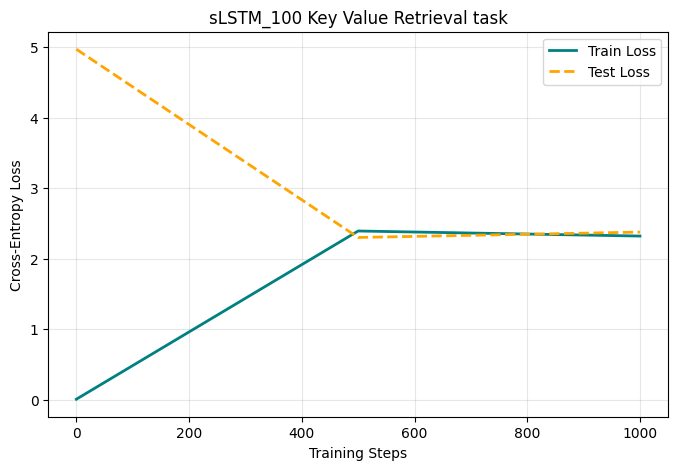

STEP: 1000 | TRAIN LOSS: 2.3226 | TEST LOSS: 2.3790


  0%|          | 0/10 [00:00<?, ?it/s]

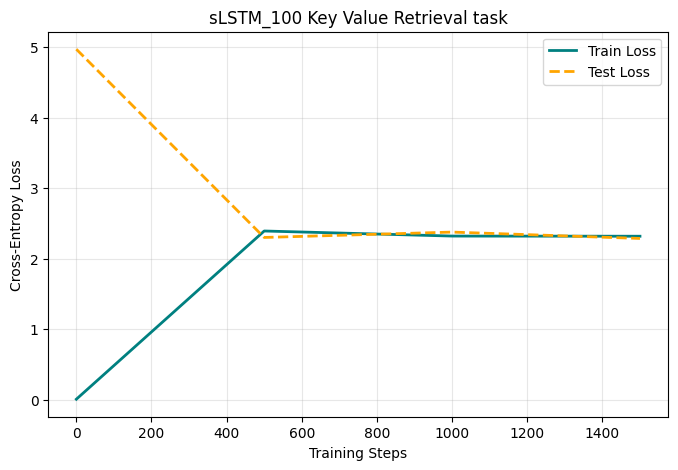

STEP: 1500 | TRAIN LOSS: 2.3202 | TEST LOSS: 2.2887


  0%|          | 0/10 [00:00<?, ?it/s]

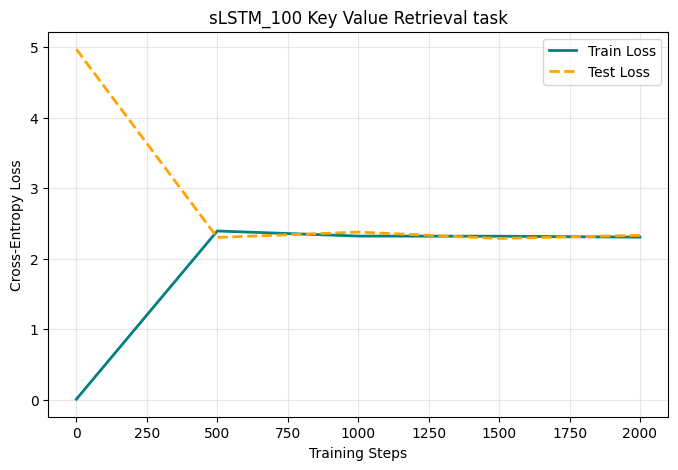

STEP: 2000 | TRAIN LOSS: 2.3072 | TEST LOSS: 2.3321


  0%|          | 0/10 [00:00<?, ?it/s]

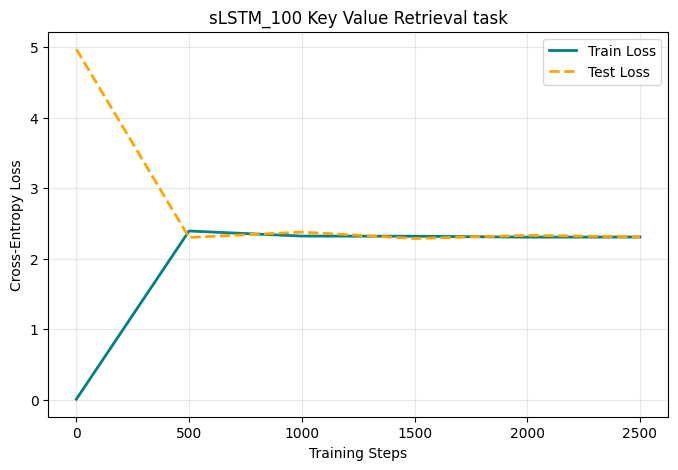

STEP: 2500 | TRAIN LOSS: 2.3089 | TEST LOSS: 2.3109


  0%|          | 0/10 [00:00<?, ?it/s]

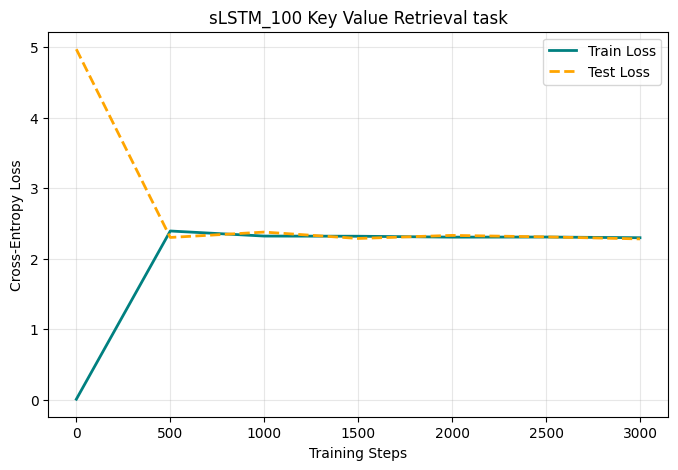

STEP: 3000 | TRAIN LOSS: 2.2991 | TEST LOSS: 2.2823


  0%|          | 0/10 [00:00<?, ?it/s]

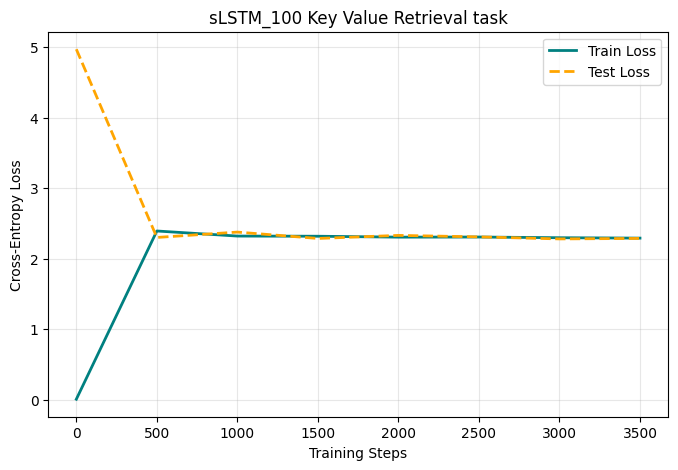

STEP: 3500 | TRAIN LOSS: 2.2934 | TEST LOSS: 2.2891


  0%|          | 0/10 [00:00<?, ?it/s]

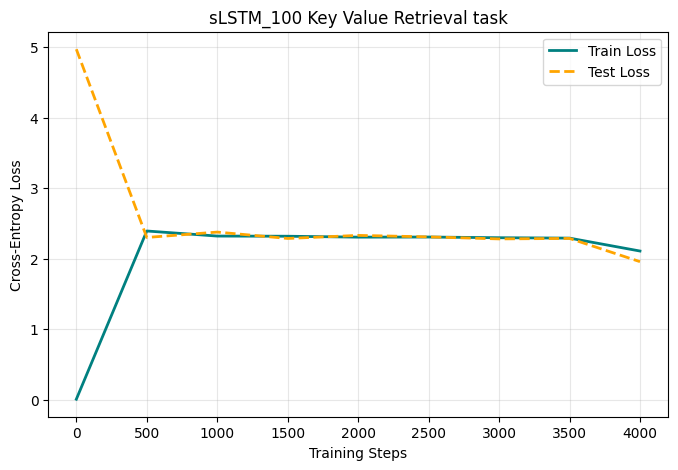

STEP: 4000 | TRAIN LOSS: 2.1104 | TEST LOSS: 1.9598


  0%|          | 0/10 [00:00<?, ?it/s]

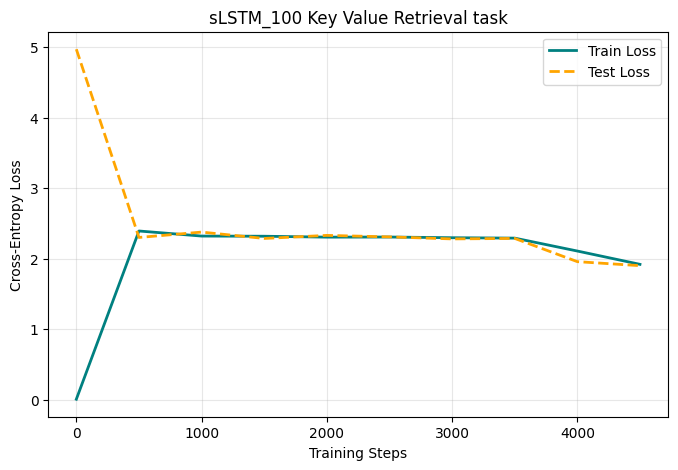

STEP: 4500 | TRAIN LOSS: 1.9217 | TEST LOSS: 1.9030


  0%|          | 0/10 [00:00<?, ?it/s]

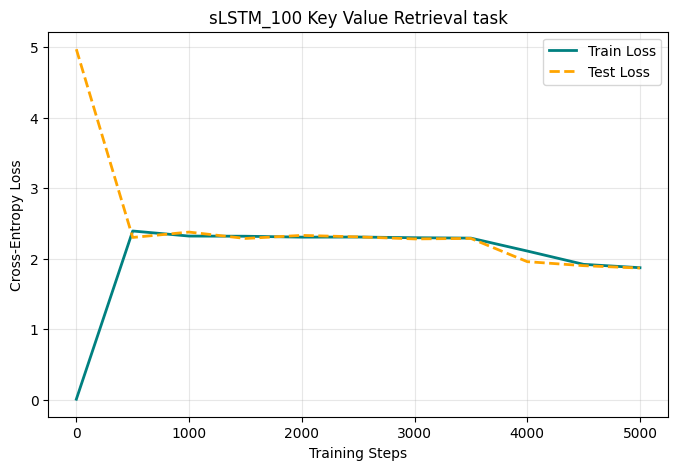

STEP: 5000 | TRAIN LOSS: 1.8740 | TEST LOSS: 1.8691


  0%|          | 0/10 [00:00<?, ?it/s]

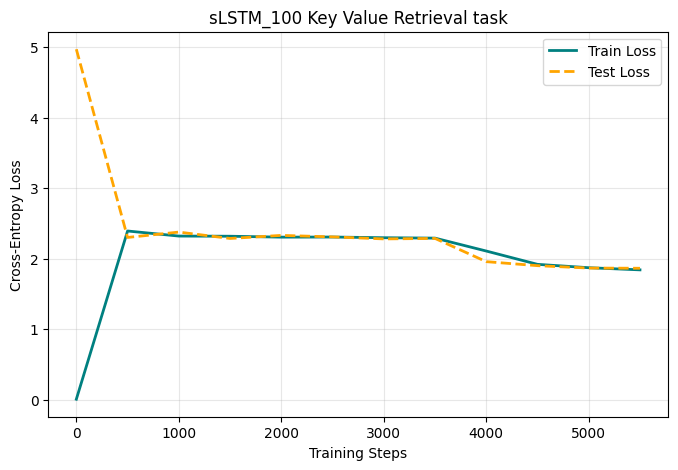

STEP: 5500 | TRAIN LOSS: 1.8436 | TEST LOSS: 1.8663


  0%|          | 0/10 [00:00<?, ?it/s]

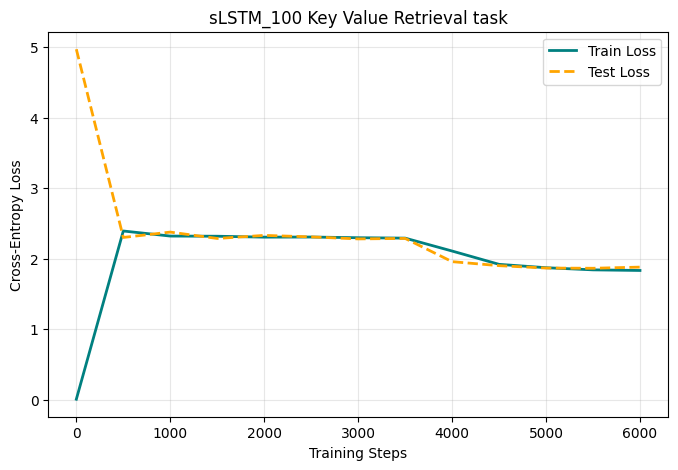

STEP: 6000 | TRAIN LOSS: 1.8350 | TEST LOSS: 1.8824


  0%|          | 0/10 [00:00<?, ?it/s]

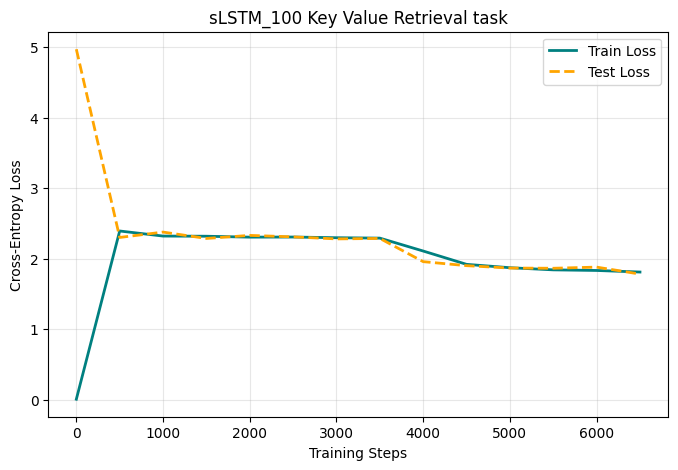

STEP: 6500 | TRAIN LOSS: 1.8127 | TEST LOSS: 1.7839


  0%|          | 0/10 [00:00<?, ?it/s]

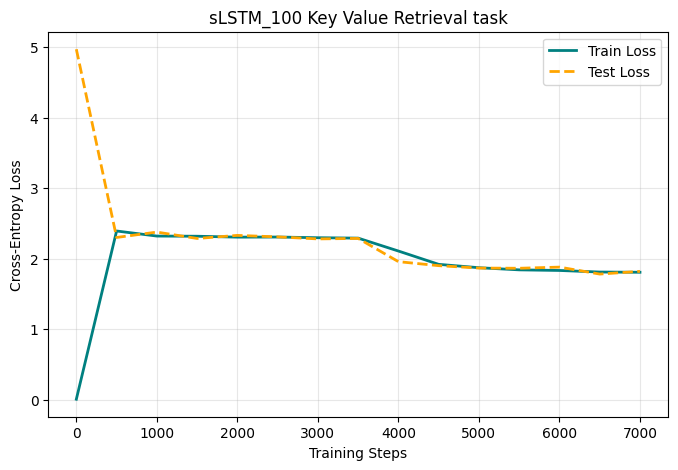

STEP: 7000 | TRAIN LOSS: 1.8095 | TEST LOSS: 1.8224


  0%|          | 0/10 [00:00<?, ?it/s]

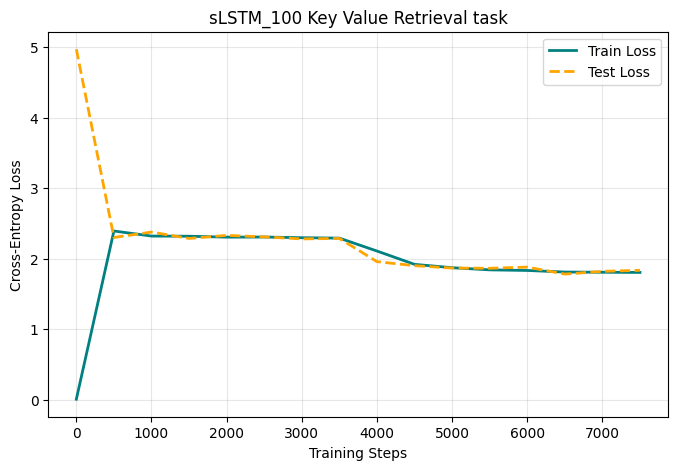

STEP: 7500 | TRAIN LOSS: 1.8073 | TEST LOSS: 1.8368


  0%|          | 0/10 [00:00<?, ?it/s]

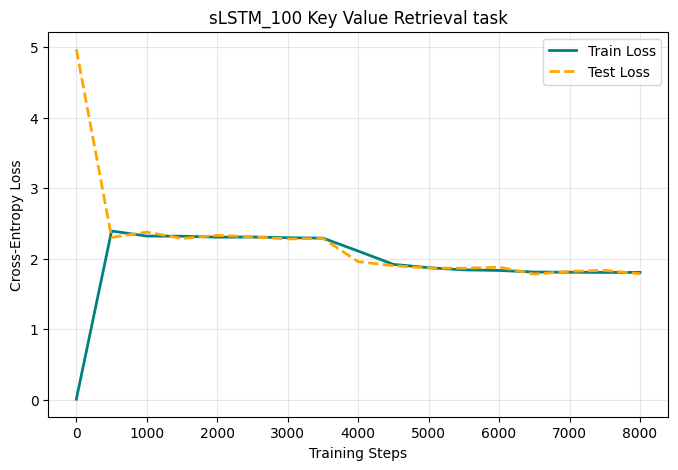

STEP: 8000 | TRAIN LOSS: 1.8074 | TEST LOSS: 1.7888


  0%|          | 0/10 [00:00<?, ?it/s]

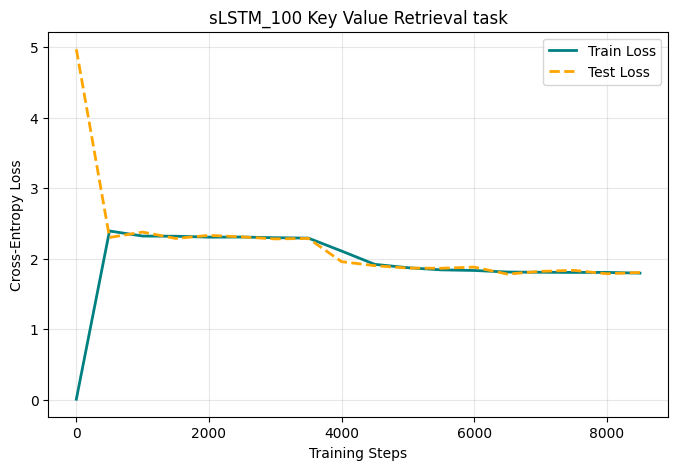

STEP: 8500 | TRAIN LOSS: 1.7970 | TEST LOSS: 1.8064


  0%|          | 0/10 [00:00<?, ?it/s]

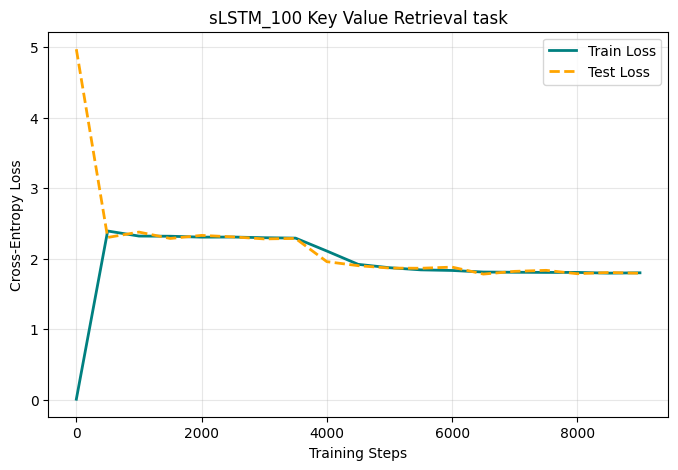

STEP: 9000 | TRAIN LOSS: 1.8019 | TEST LOSS: 1.7952


  0%|          | 0/10 [00:00<?, ?it/s]

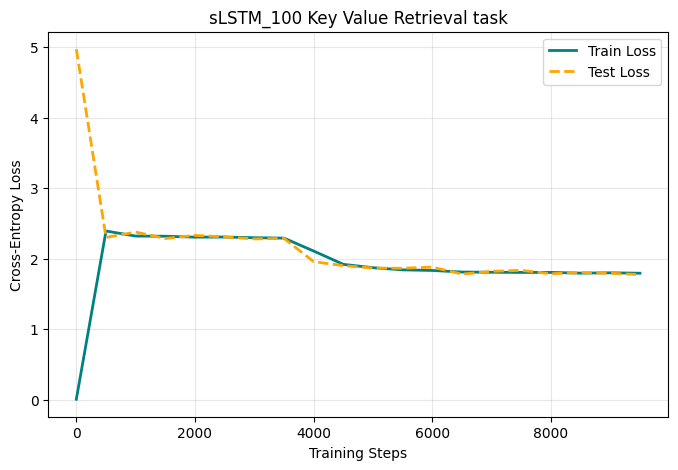

STEP: 9500 | TRAIN LOSS: 1.7959 | TEST LOSS: 1.7768


  0%|          | 0/10 [00:00<?, ?it/s]

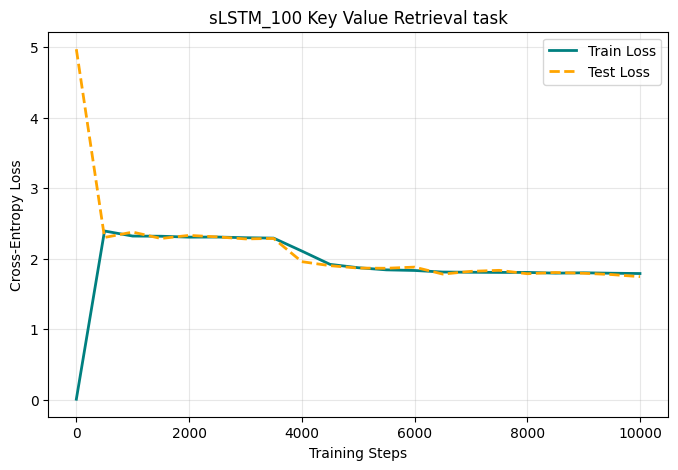

STEP: 10000 | TRAIN LOSS: 1.7915 | TEST LOSS: 1.7470


  0%|          | 0/10 [00:00<?, ?it/s]

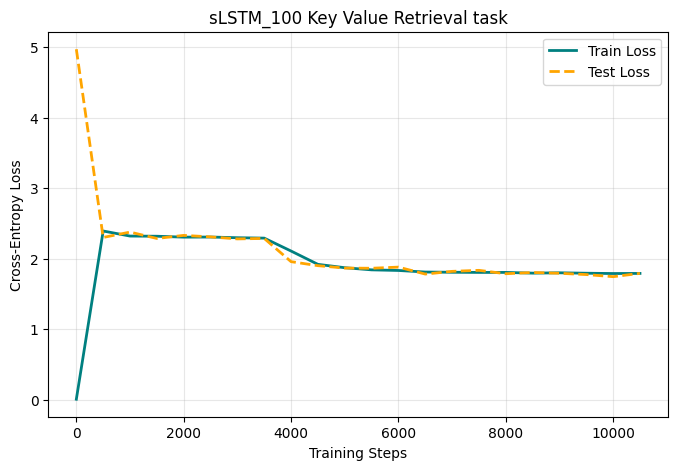

STEP: 10500 | TRAIN LOSS: 1.7931 | TEST LOSS: 1.7938


  0%|          | 0/10 [00:00<?, ?it/s]

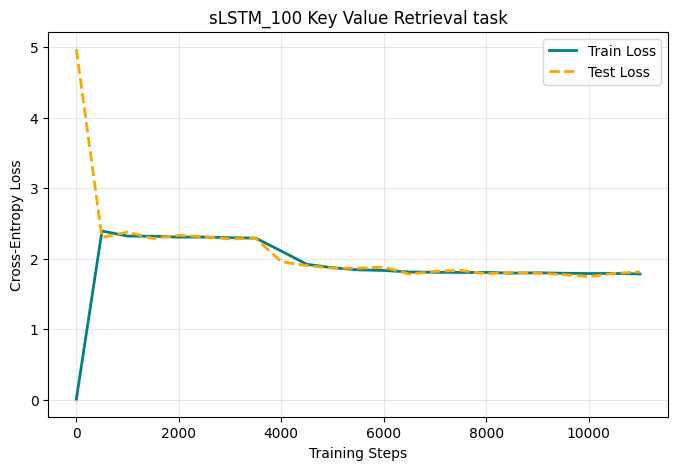

STEP: 11000 | TRAIN LOSS: 1.7859 | TEST LOSS: 1.8148


  0%|          | 0/10 [00:00<?, ?it/s]

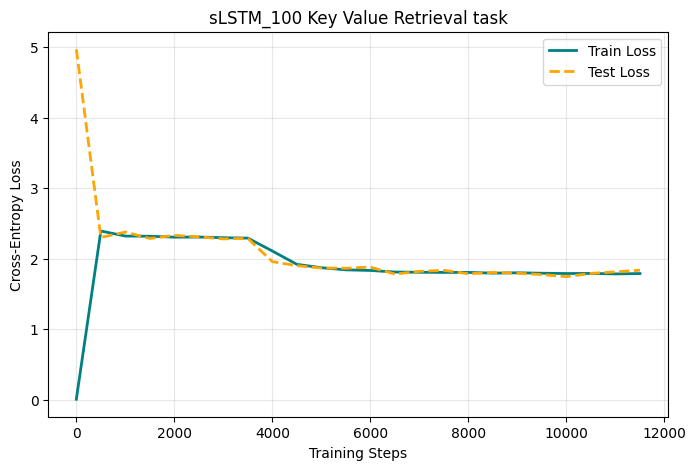

STEP: 11500 | TRAIN LOSS: 1.7912 | TEST LOSS: 1.8393


  0%|          | 0/10 [00:00<?, ?it/s]

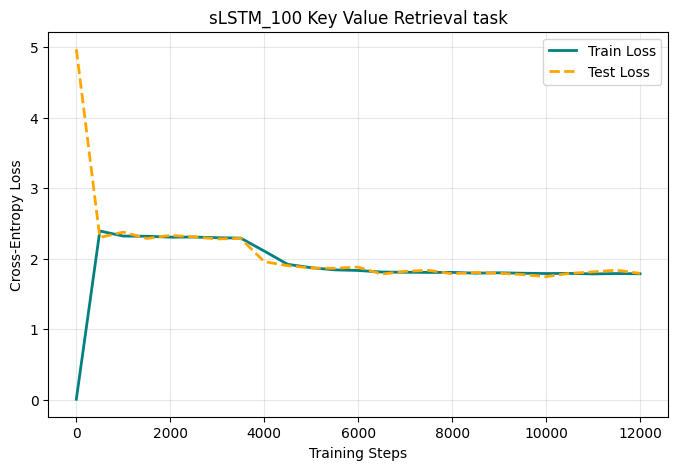

STEP: 12000 | TRAIN LOSS: 1.7879 | TEST LOSS: 1.7936


  0%|          | 0/10 [00:00<?, ?it/s]

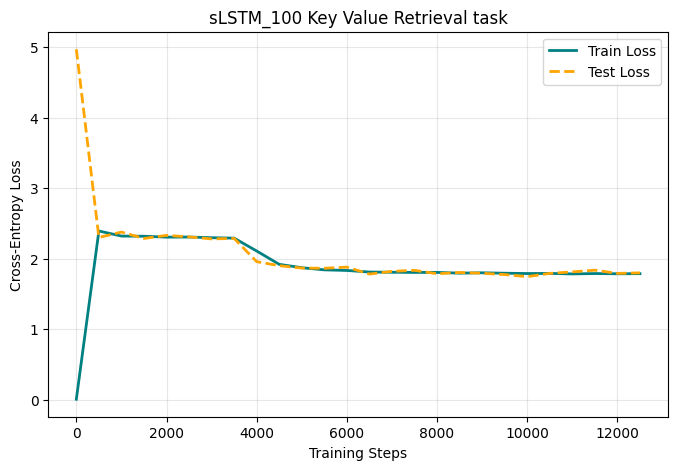

STEP: 12500 | TRAIN LOSS: 1.7895 | TEST LOSS: 1.8011


  0%|          | 0/10 [00:00<?, ?it/s]

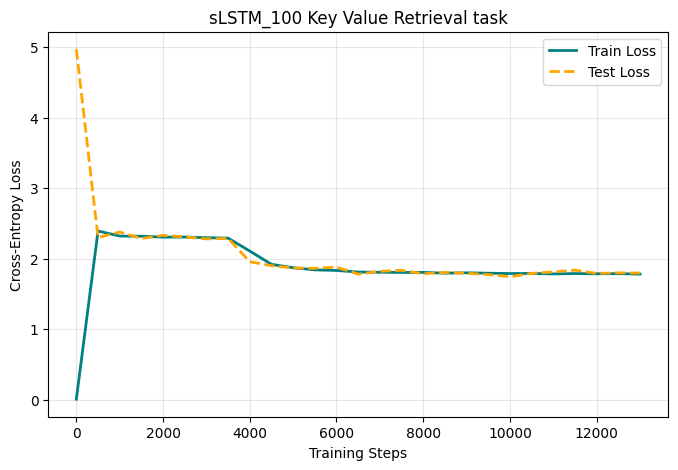

STEP: 13000 | TRAIN LOSS: 1.7834 | TEST LOSS: 1.7989


  0%|          | 0/10 [00:00<?, ?it/s]

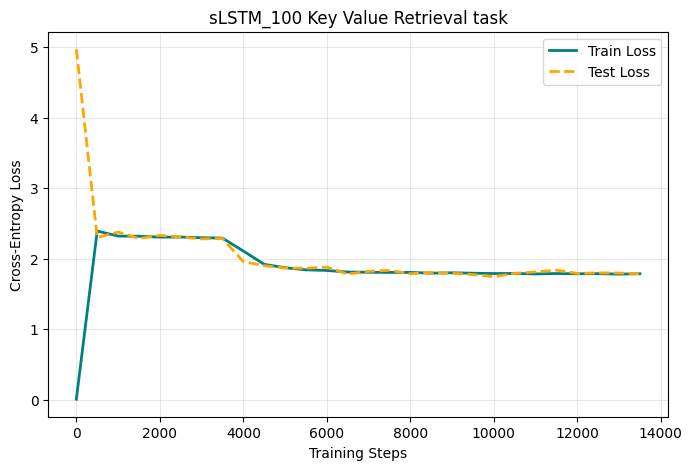

STEP: 13500 | TRAIN LOSS: 1.7882 | TEST LOSS: 1.7881


  0%|          | 0/10 [00:00<?, ?it/s]

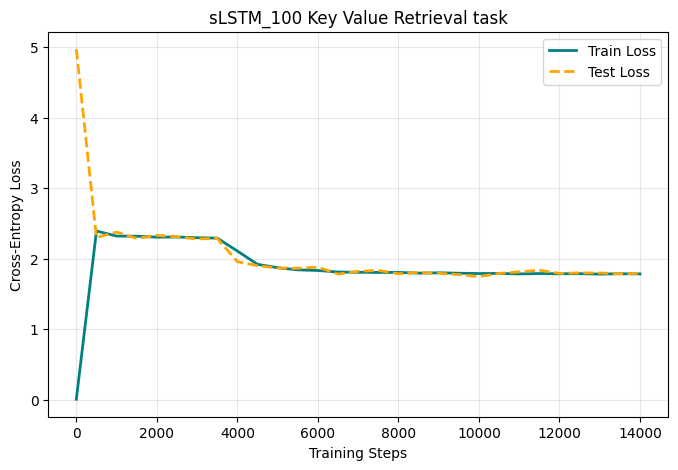

STEP: 14000 | TRAIN LOSS: 1.7864 | TEST LOSS: 1.7933


In [7]:
steps_history = []
train_history = []
test_history = []


run_training_ex5(model=sLSTM_model, 
                 batch_size=batch_size, 
                 total_batches=total_batches, 
                 test_batches=test_batches, 
                 lookup_size=copy_size, 
                 pairs=buffer_size, 
                 opt=opt_sLSTM, 
                 test_break=500, 
                 model_name="sLSTM_100",
                 steps_history=steps_history,
                 train_history=train_history,
                 test_history=test_history,
                 vocab=vocab)

  0%|          | 0/14001 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

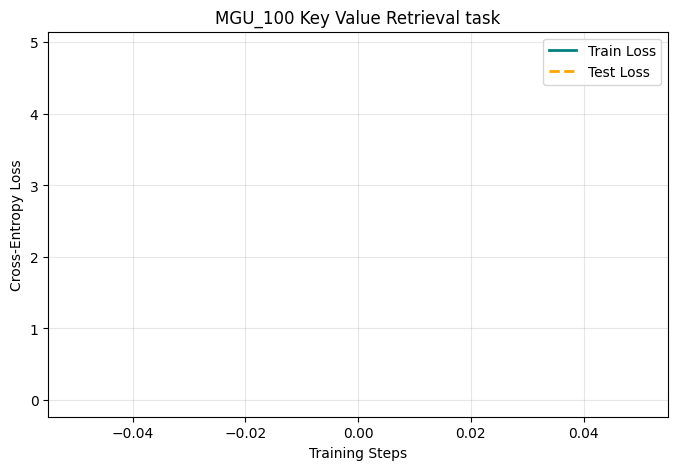

STEP: 0 | TRAIN LOSS: 0.0100 | TEST LOSS: 4.9044


  0%|          | 0/10 [00:00<?, ?it/s]

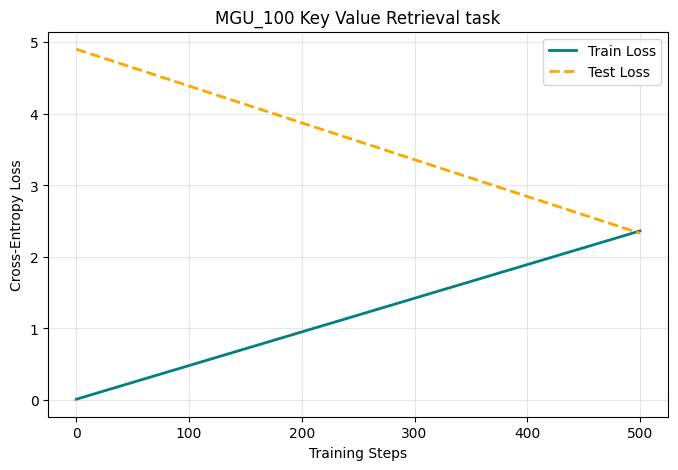

STEP: 500 | TRAIN LOSS: 2.3632 | TEST LOSS: 2.3311


  0%|          | 0/10 [00:00<?, ?it/s]

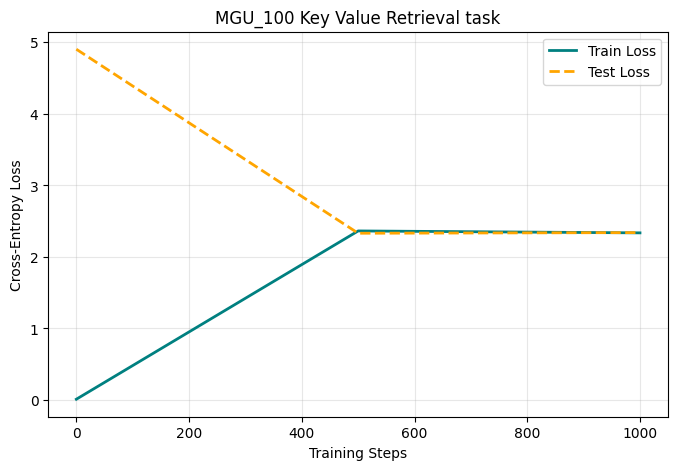

STEP: 1000 | TRAIN LOSS: 2.3363 | TEST LOSS: 2.3399


  0%|          | 0/10 [00:00<?, ?it/s]

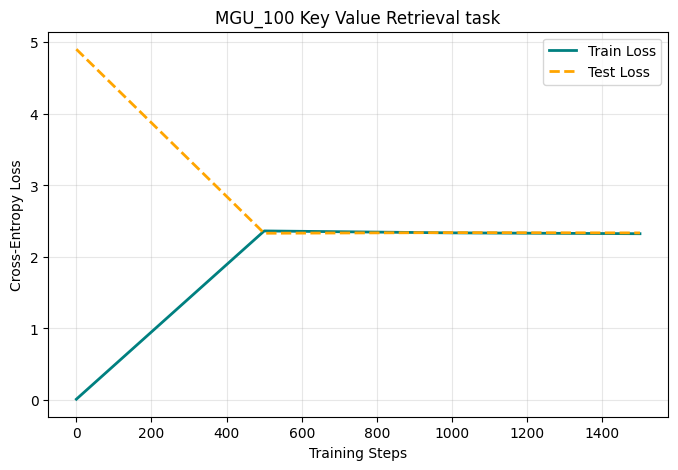

STEP: 1500 | TRAIN LOSS: 2.3246 | TEST LOSS: 2.3358


  0%|          | 0/10 [00:00<?, ?it/s]

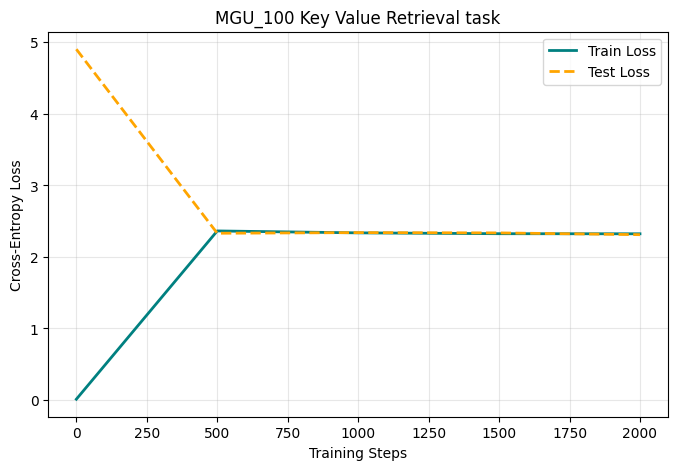

STEP: 2000 | TRAIN LOSS: 2.3234 | TEST LOSS: 2.3110


  0%|          | 0/10 [00:00<?, ?it/s]

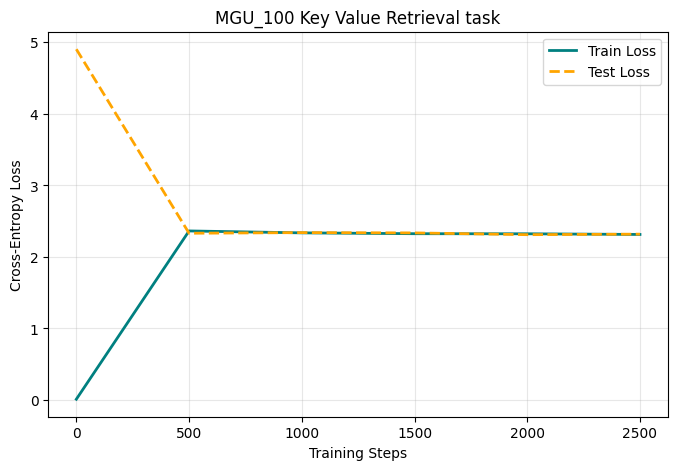

STEP: 2500 | TRAIN LOSS: 2.3139 | TEST LOSS: 2.3184


  0%|          | 0/10 [00:00<?, ?it/s]

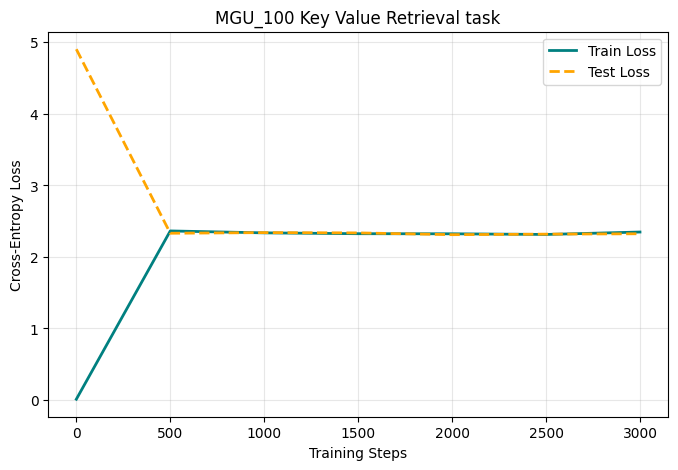

STEP: 3000 | TRAIN LOSS: 2.3480 | TEST LOSS: 2.3239


  0%|          | 0/10 [00:00<?, ?it/s]

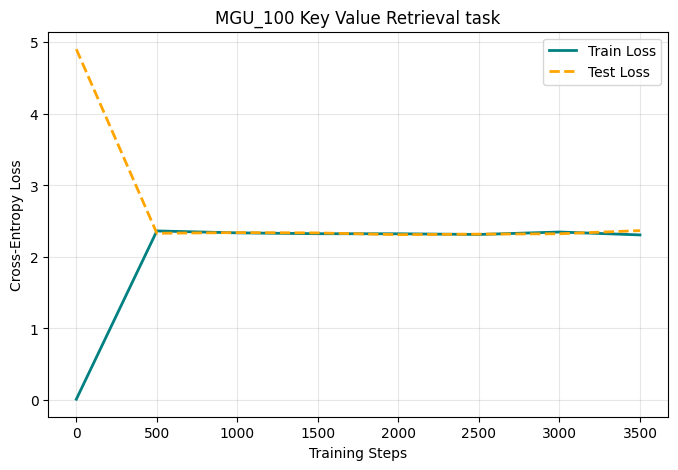

STEP: 3500 | TRAIN LOSS: 2.3076 | TEST LOSS: 2.3678


  0%|          | 0/10 [00:00<?, ?it/s]

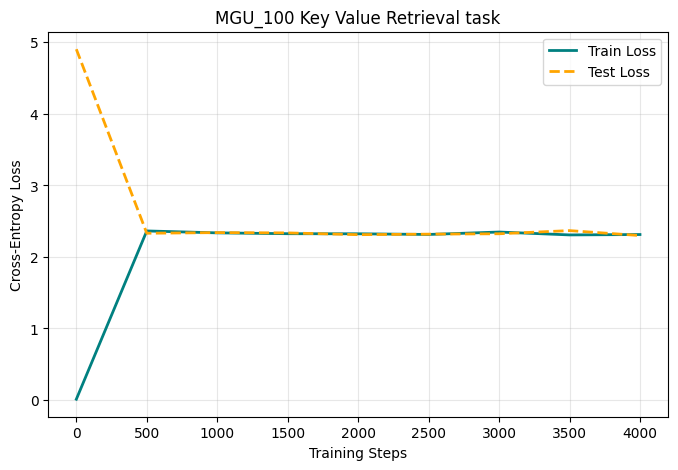

STEP: 4000 | TRAIN LOSS: 2.3131 | TEST LOSS: 2.2988


  0%|          | 0/10 [00:00<?, ?it/s]

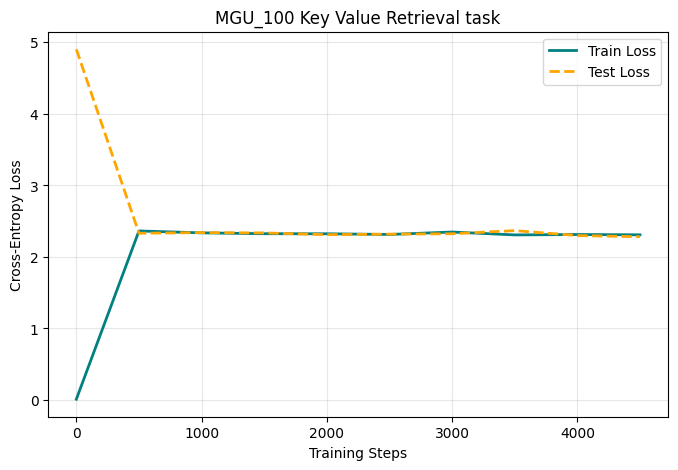

STEP: 4500 | TRAIN LOSS: 2.3089 | TEST LOSS: 2.2826


  0%|          | 0/10 [00:00<?, ?it/s]

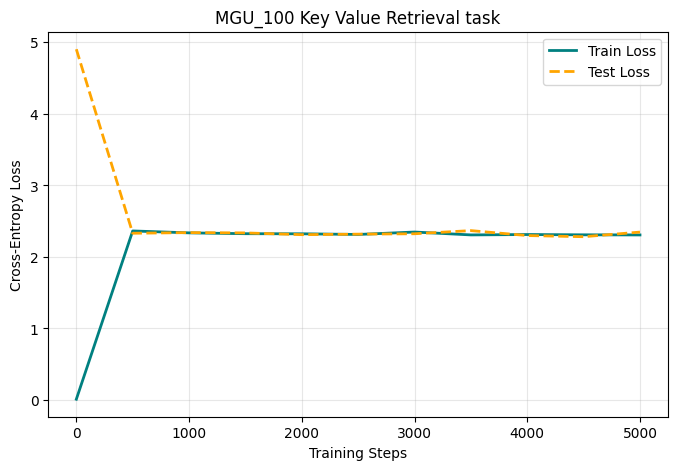

STEP: 5000 | TRAIN LOSS: 2.3073 | TEST LOSS: 2.3471


  0%|          | 0/10 [00:00<?, ?it/s]

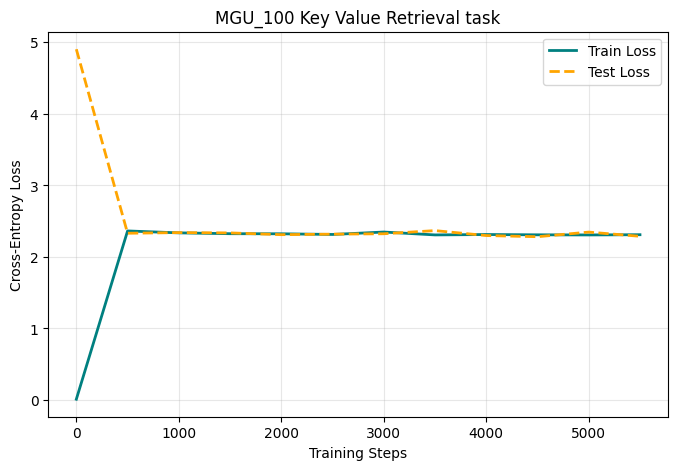

STEP: 5500 | TRAIN LOSS: 2.3106 | TEST LOSS: 2.2883


  0%|          | 0/10 [00:00<?, ?it/s]

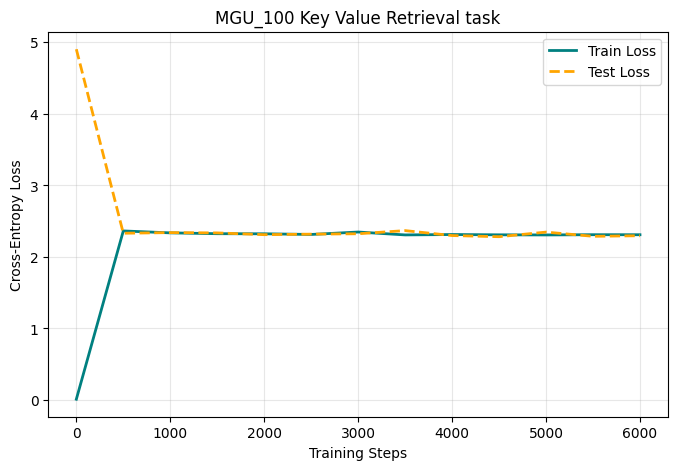

STEP: 6000 | TRAIN LOSS: 2.3102 | TEST LOSS: 2.2964


  0%|          | 0/10 [00:00<?, ?it/s]

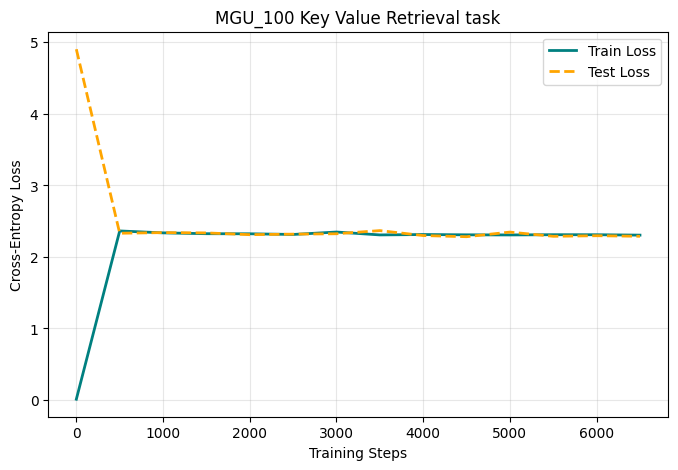

STEP: 6500 | TRAIN LOSS: 2.3046 | TEST LOSS: 2.2888


  0%|          | 0/10 [00:00<?, ?it/s]

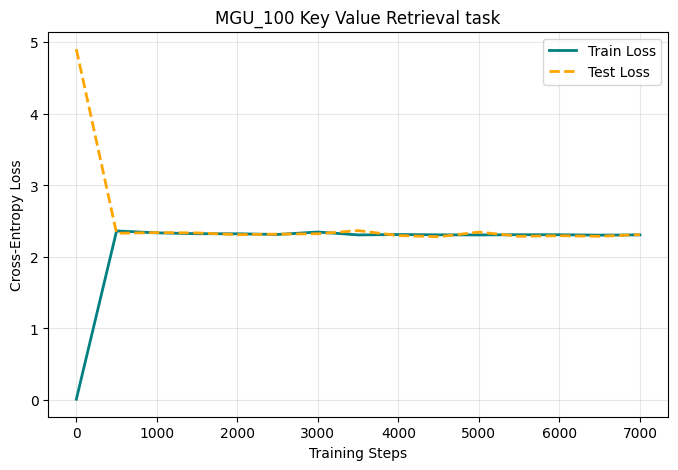

STEP: 7000 | TRAIN LOSS: 2.3081 | TEST LOSS: 2.3115


  0%|          | 0/10 [00:00<?, ?it/s]

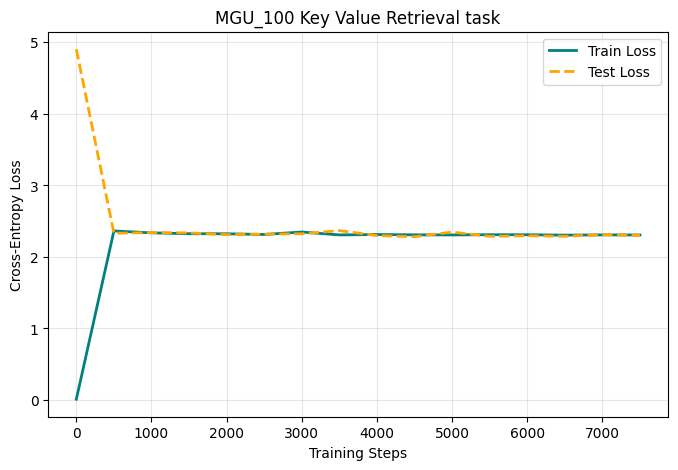

STEP: 7500 | TRAIN LOSS: 2.3069 | TEST LOSS: 2.3012


  0%|          | 0/10 [00:00<?, ?it/s]

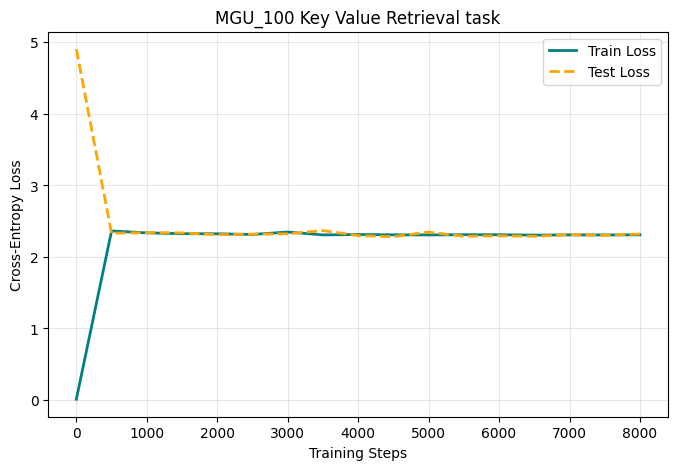

STEP: 8000 | TRAIN LOSS: 2.3089 | TEST LOSS: 2.3204


  0%|          | 0/10 [00:00<?, ?it/s]

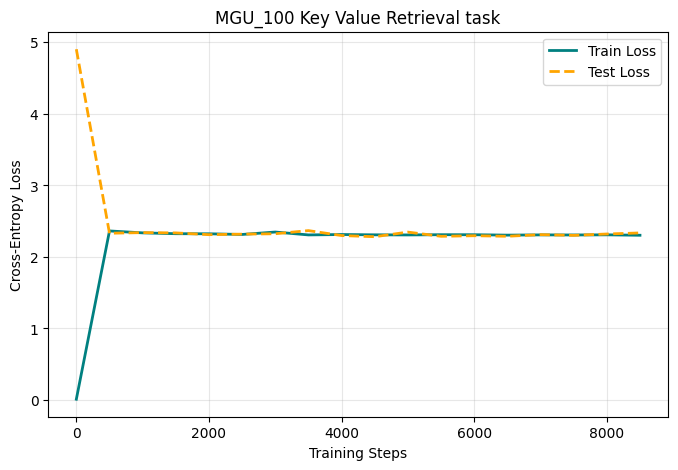

STEP: 8500 | TRAIN LOSS: 2.3029 | TEST LOSS: 2.3353


  0%|          | 0/10 [00:00<?, ?it/s]

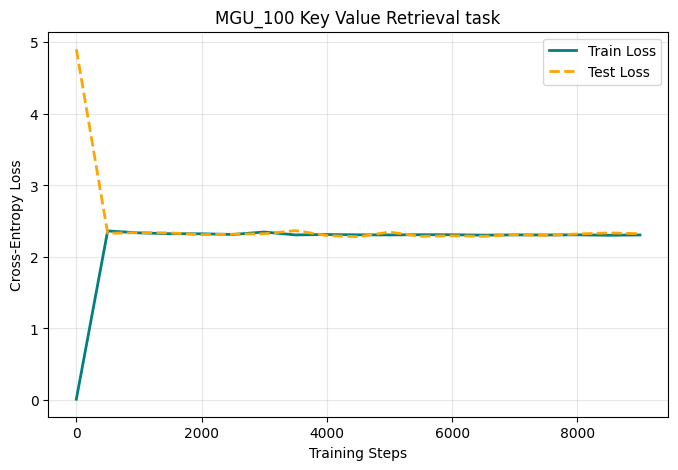

STEP: 9000 | TRAIN LOSS: 2.3070 | TEST LOSS: 2.3252


  0%|          | 0/10 [00:00<?, ?it/s]

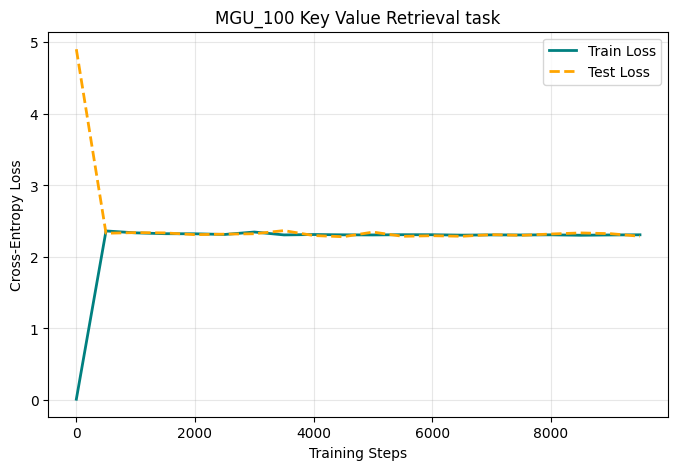

STEP: 9500 | TRAIN LOSS: 2.3094 | TEST LOSS: 2.2889


  0%|          | 0/10 [00:00<?, ?it/s]

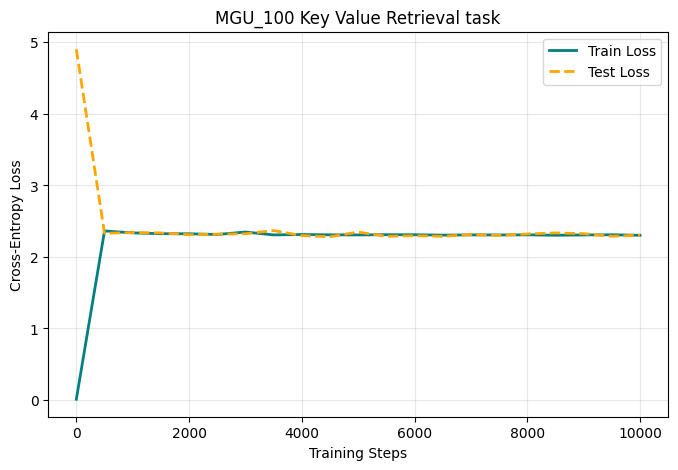

STEP: 10000 | TRAIN LOSS: 2.3025 | TEST LOSS: 2.3039


  0%|          | 0/10 [00:00<?, ?it/s]

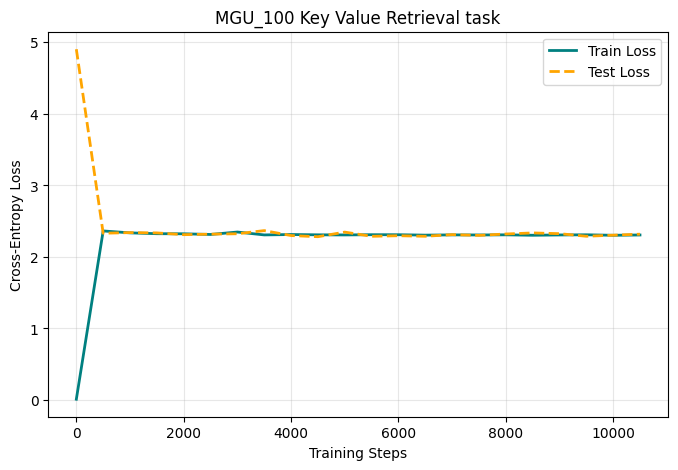

STEP: 10500 | TRAIN LOSS: 2.3068 | TEST LOSS: 2.3179


  0%|          | 0/10 [00:00<?, ?it/s]

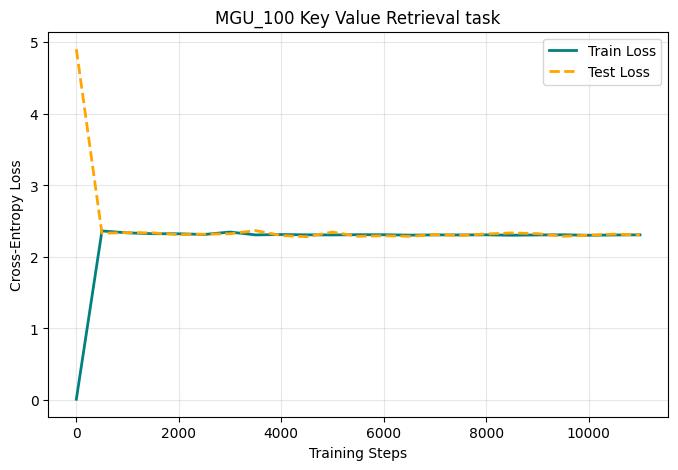

STEP: 11000 | TRAIN LOSS: 2.3085 | TEST LOSS: 2.3065


  0%|          | 0/10 [00:00<?, ?it/s]

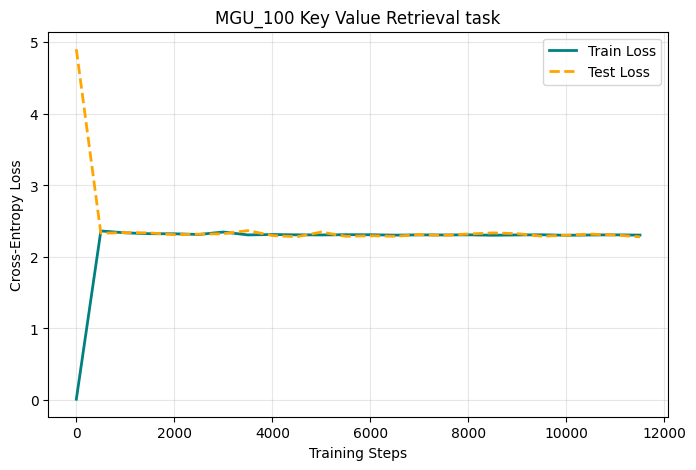

STEP: 11500 | TRAIN LOSS: 2.3051 | TEST LOSS: 2.2807


  0%|          | 0/10 [00:00<?, ?it/s]

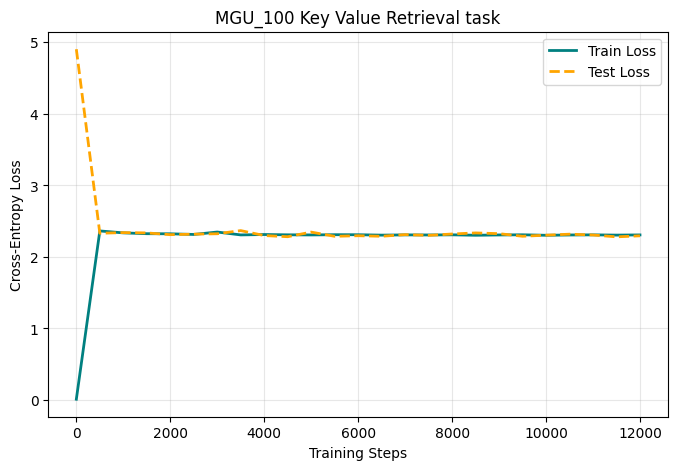

STEP: 12000 | TRAIN LOSS: 2.3075 | TEST LOSS: 2.2951


  0%|          | 0/10 [00:00<?, ?it/s]

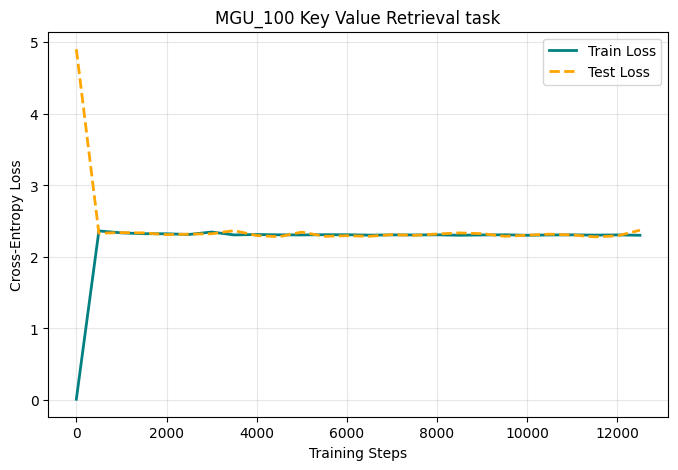

STEP: 12500 | TRAIN LOSS: 2.3027 | TEST LOSS: 2.3731


  0%|          | 0/10 [00:00<?, ?it/s]

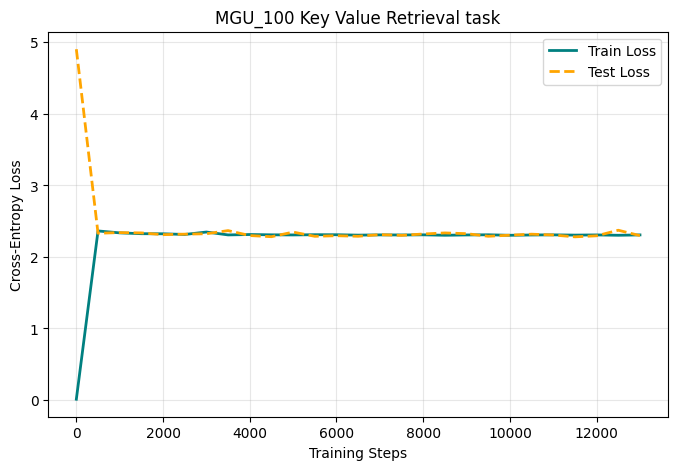

STEP: 13000 | TRAIN LOSS: 2.3077 | TEST LOSS: 2.2975


  0%|          | 0/10 [00:00<?, ?it/s]

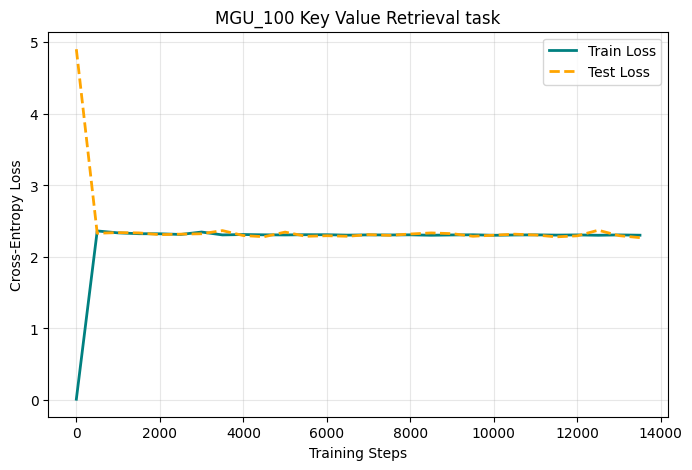

STEP: 13500 | TRAIN LOSS: 2.3036 | TEST LOSS: 2.2696


  0%|          | 0/10 [00:00<?, ?it/s]

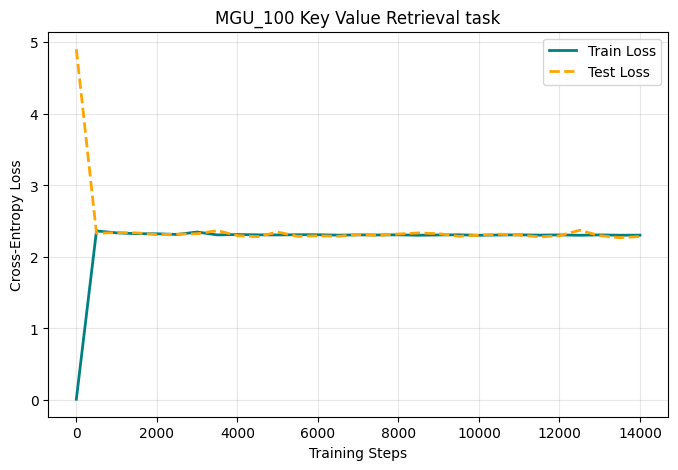

STEP: 14000 | TRAIN LOSS: 2.3042 | TEST LOSS: 2.2849


In [8]:
steps_history = []
train_history = []
test_history = []

run_training_ex5(MGU_model, 
                 batch_size, 
                 total_batches, 
                 test_batches, 
                 copy_size, 
                 buffer_size, 
                 opt_MGU, 
                 test_break=500, 
                 model_name="MGU_100",
                 steps_history=steps_history,
                 train_history=train_history,
                 test_history=test_history,
                 vocab=vocab)

  0%|          | 0/14001 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

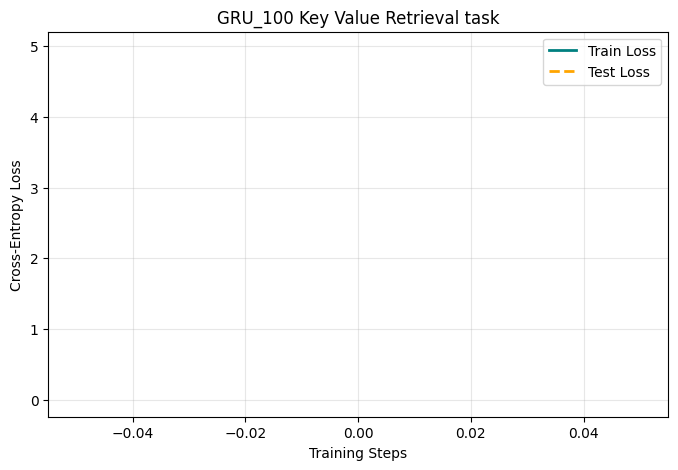

STEP: 0 | TRAIN LOSS: 0.0100 | TEST LOSS: 4.9531


  0%|          | 0/10 [00:00<?, ?it/s]

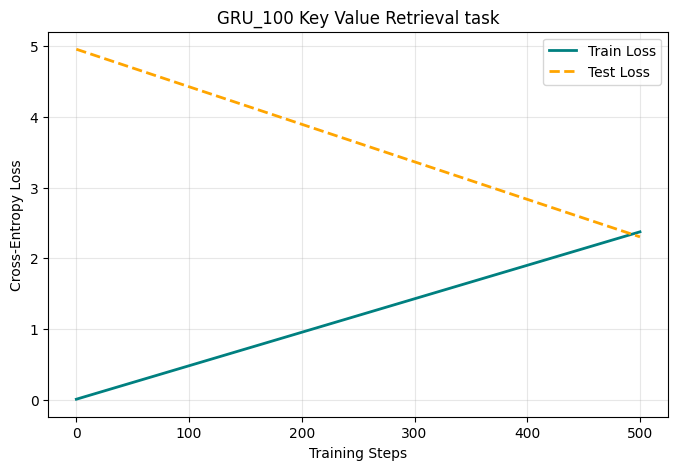

STEP: 500 | TRAIN LOSS: 2.3742 | TEST LOSS: 2.3029


  0%|          | 0/10 [00:00<?, ?it/s]

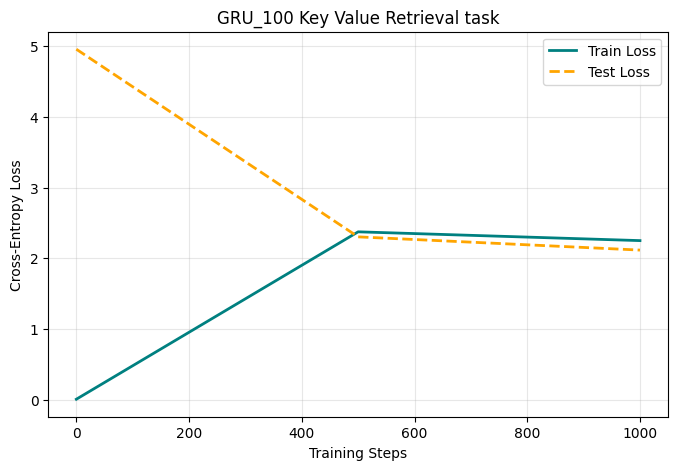

STEP: 1000 | TRAIN LOSS: 2.2501 | TEST LOSS: 2.1161


  0%|          | 0/10 [00:00<?, ?it/s]

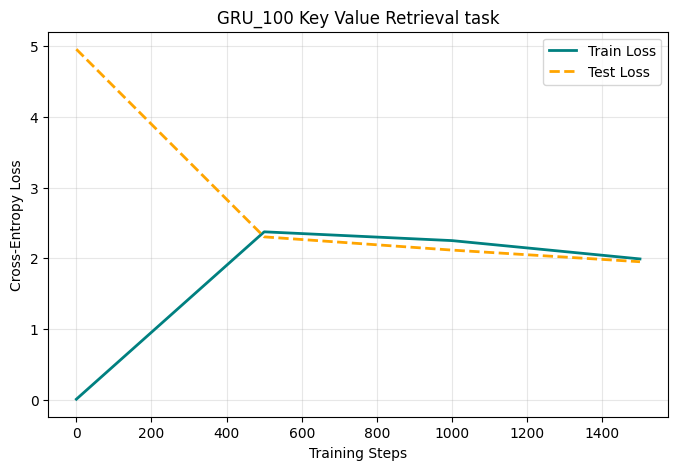

STEP: 1500 | TRAIN LOSS: 1.9912 | TEST LOSS: 1.9517


  0%|          | 0/10 [00:00<?, ?it/s]

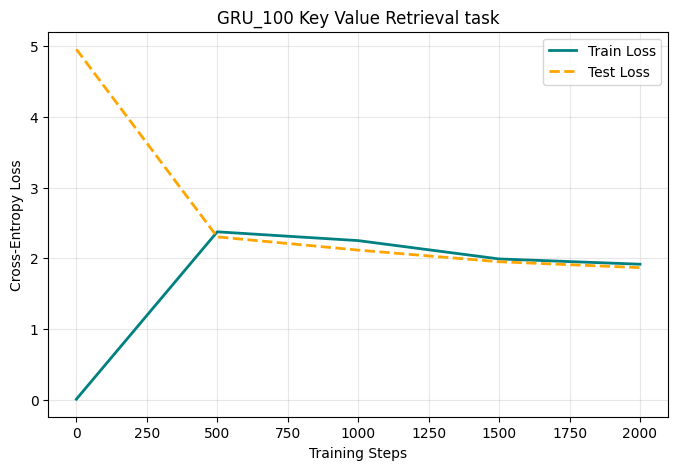

STEP: 2000 | TRAIN LOSS: 1.9167 | TEST LOSS: 1.8681


  0%|          | 0/10 [00:00<?, ?it/s]

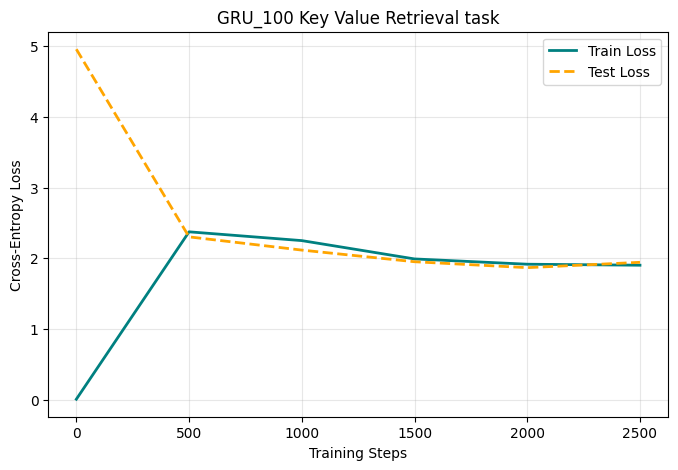

STEP: 2500 | TRAIN LOSS: 1.9026 | TEST LOSS: 1.9436


  0%|          | 0/10 [00:00<?, ?it/s]

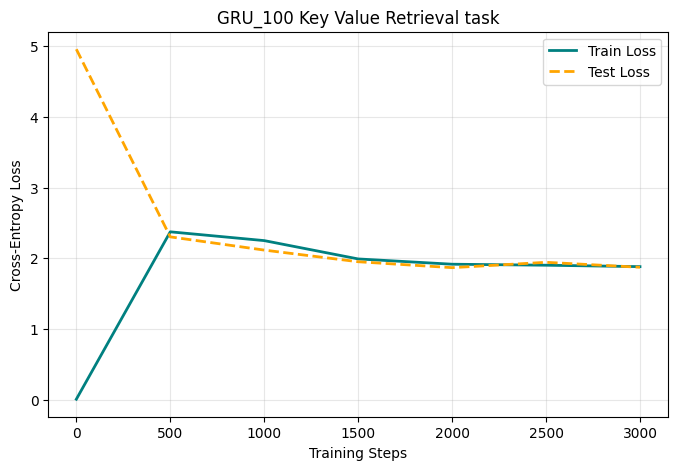

STEP: 3000 | TRAIN LOSS: 1.8824 | TEST LOSS: 1.8734


  0%|          | 0/10 [00:00<?, ?it/s]

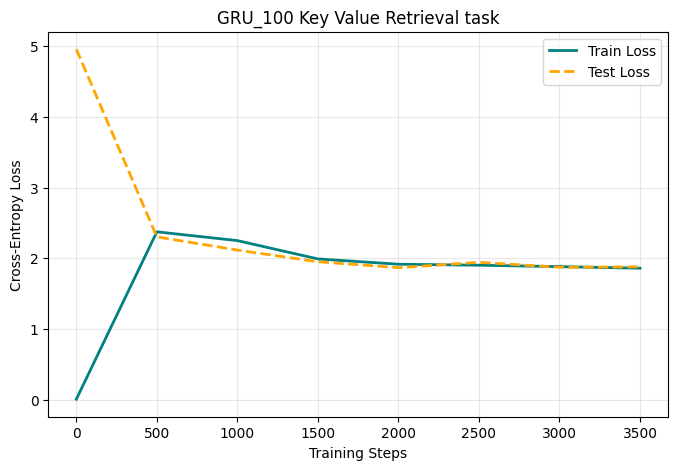

STEP: 3500 | TRAIN LOSS: 1.8605 | TEST LOSS: 1.8793


  0%|          | 0/10 [00:00<?, ?it/s]

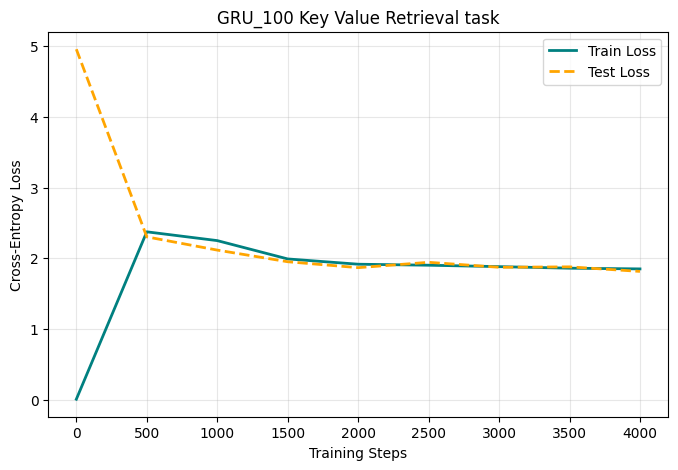

STEP: 4000 | TRAIN LOSS: 1.8505 | TEST LOSS: 1.8152


  0%|          | 0/10 [00:00<?, ?it/s]

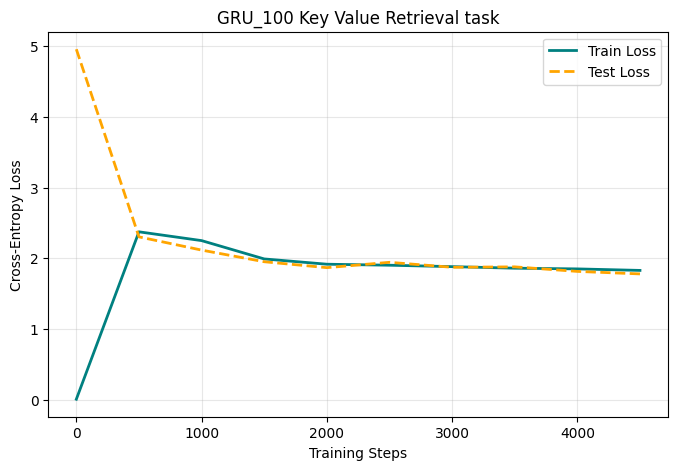

STEP: 4500 | TRAIN LOSS: 1.8292 | TEST LOSS: 1.7797


  0%|          | 0/10 [00:00<?, ?it/s]

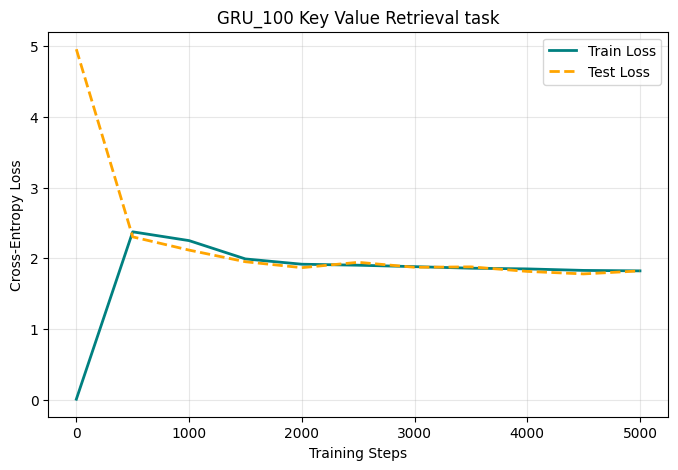

STEP: 5000 | TRAIN LOSS: 1.8228 | TEST LOSS: 1.8222


  0%|          | 0/10 [00:00<?, ?it/s]

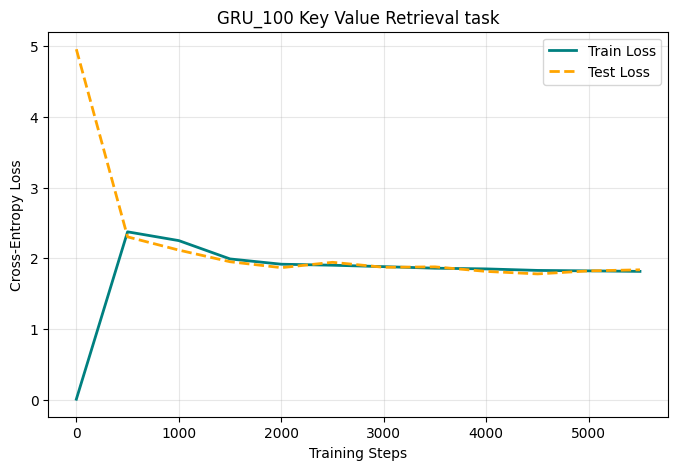

STEP: 5500 | TRAIN LOSS: 1.8154 | TEST LOSS: 1.8376


  0%|          | 0/10 [00:00<?, ?it/s]

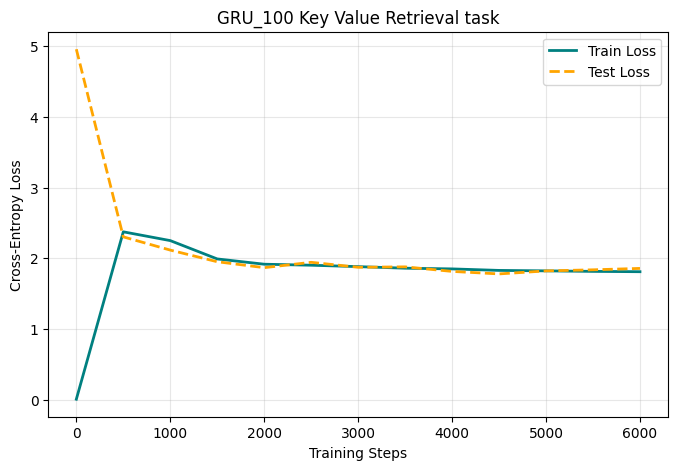

STEP: 6000 | TRAIN LOSS: 1.8108 | TEST LOSS: 1.8575


  0%|          | 0/10 [00:00<?, ?it/s]

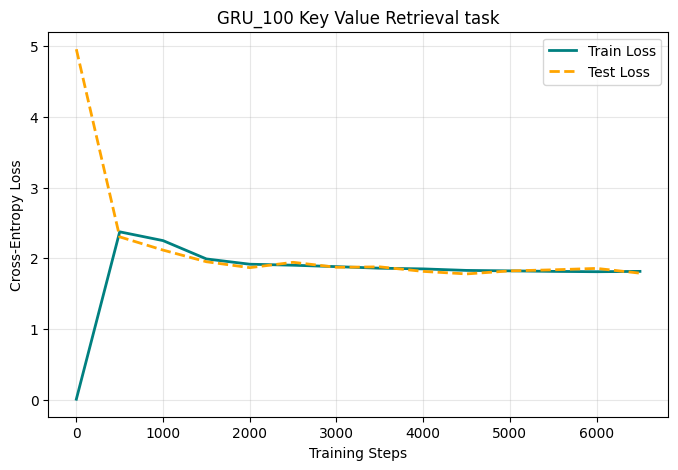

STEP: 6500 | TRAIN LOSS: 1.8155 | TEST LOSS: 1.7904


  0%|          | 0/10 [00:00<?, ?it/s]

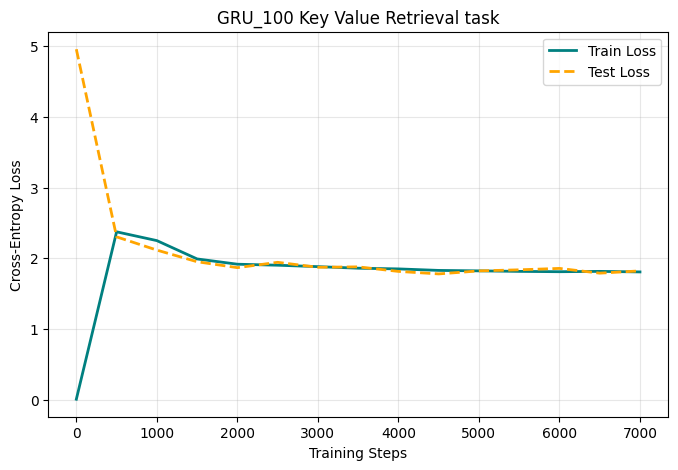

STEP: 7000 | TRAIN LOSS: 1.8079 | TEST LOSS: 1.8225


  0%|          | 0/10 [00:00<?, ?it/s]

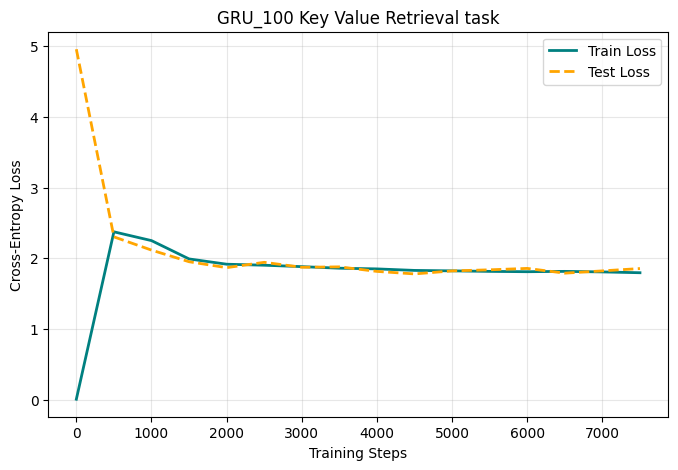

STEP: 7500 | TRAIN LOSS: 1.7964 | TEST LOSS: 1.8556


  0%|          | 0/10 [00:00<?, ?it/s]

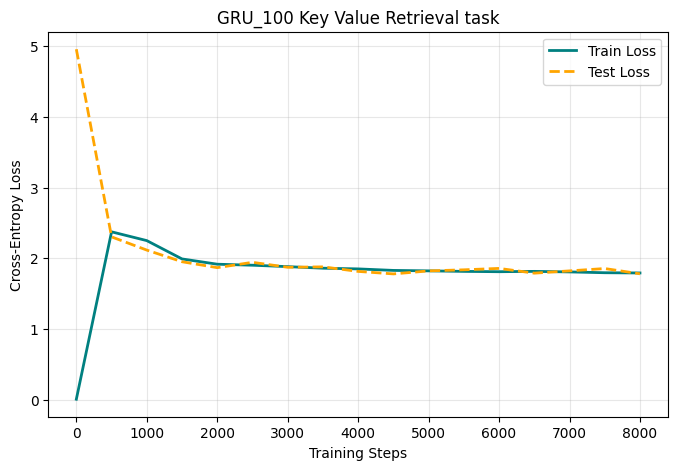

STEP: 8000 | TRAIN LOSS: 1.7931 | TEST LOSS: 1.7814


  0%|          | 0/10 [00:00<?, ?it/s]

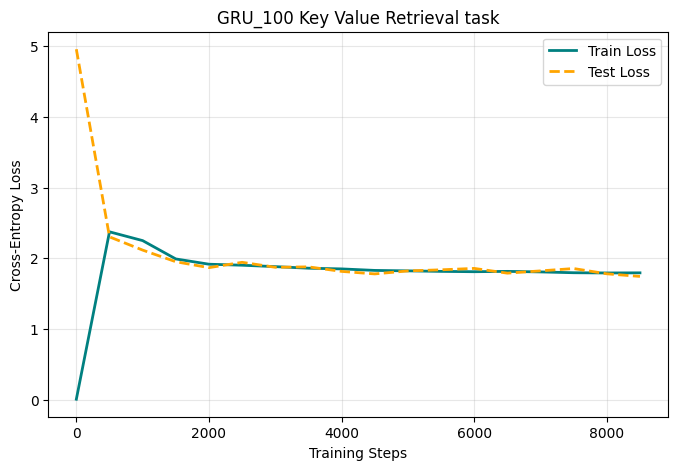

STEP: 8500 | TRAIN LOSS: 1.7949 | TEST LOSS: 1.7441


  0%|          | 0/10 [00:00<?, ?it/s]

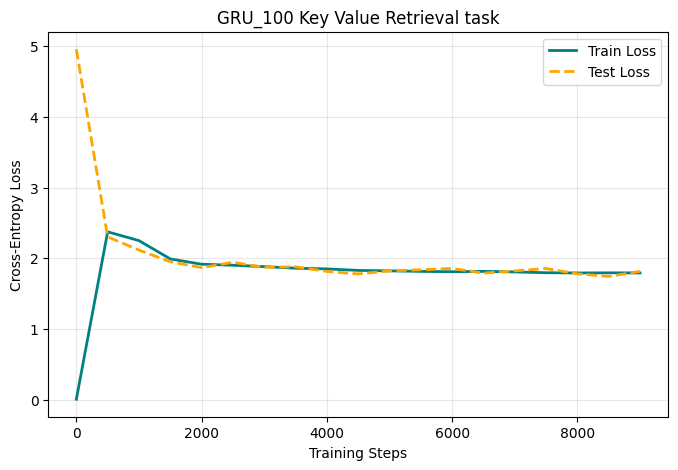

STEP: 9000 | TRAIN LOSS: 1.7938 | TEST LOSS: 1.8155


  0%|          | 0/10 [00:00<?, ?it/s]

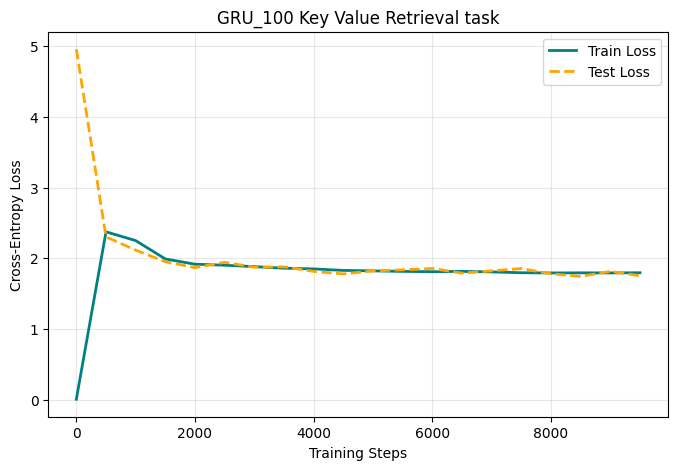

STEP: 9500 | TRAIN LOSS: 1.7961 | TEST LOSS: 1.7541


  0%|          | 0/10 [00:00<?, ?it/s]

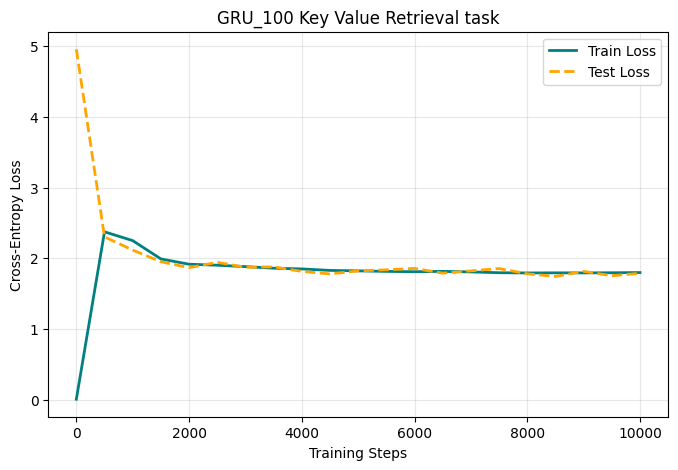

STEP: 10000 | TRAIN LOSS: 1.7990 | TEST LOSS: 1.7882


  0%|          | 0/10 [00:00<?, ?it/s]

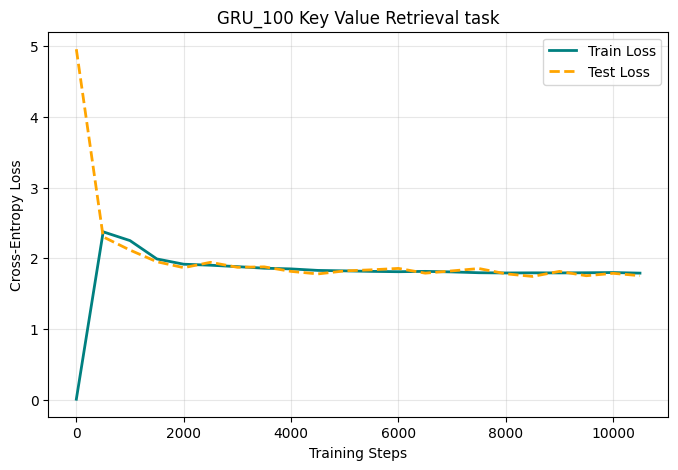

STEP: 10500 | TRAIN LOSS: 1.7909 | TEST LOSS: 1.7546


  0%|          | 0/10 [00:00<?, ?it/s]

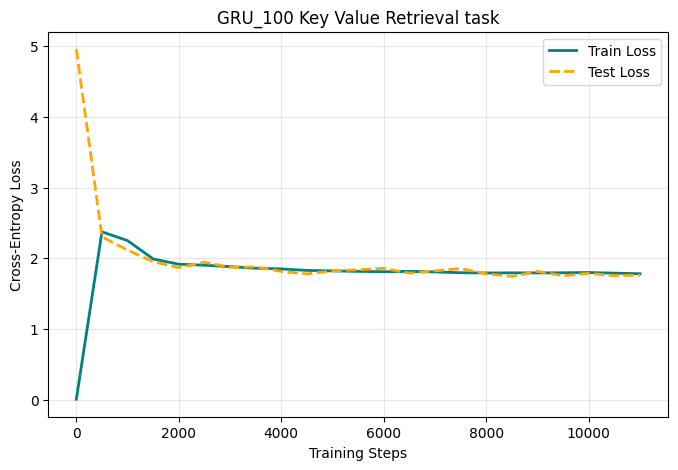

STEP: 11000 | TRAIN LOSS: 1.7819 | TEST LOSS: 1.7613


  0%|          | 0/10 [00:00<?, ?it/s]

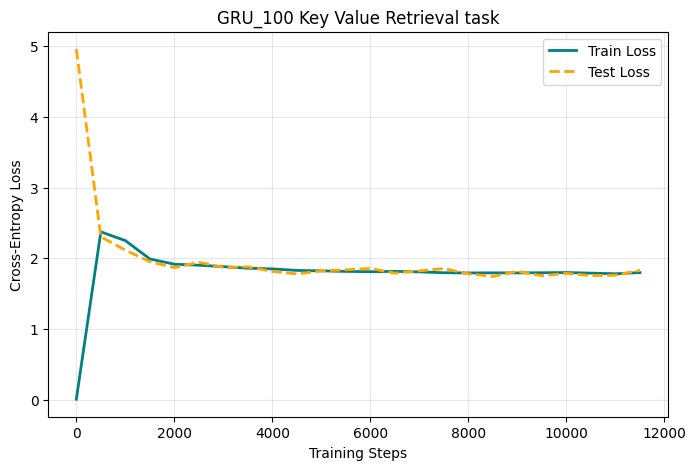

STEP: 11500 | TRAIN LOSS: 1.7985 | TEST LOSS: 1.8301


  0%|          | 0/10 [00:00<?, ?it/s]

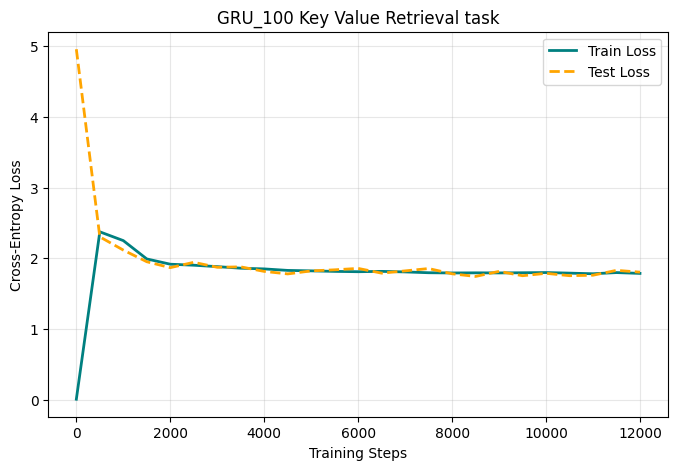

STEP: 12000 | TRAIN LOSS: 1.7870 | TEST LOSS: 1.8046


  0%|          | 0/10 [00:00<?, ?it/s]

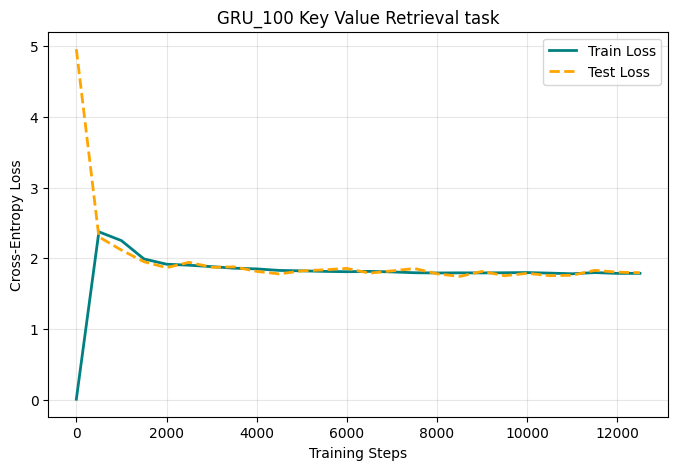

STEP: 12500 | TRAIN LOSS: 1.7877 | TEST LOSS: 1.7968


  0%|          | 0/10 [00:00<?, ?it/s]

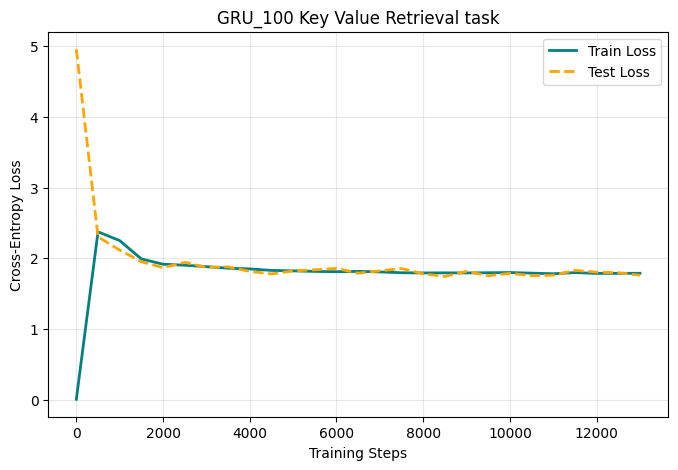

STEP: 13000 | TRAIN LOSS: 1.7888 | TEST LOSS: 1.7613


  0%|          | 0/10 [00:00<?, ?it/s]

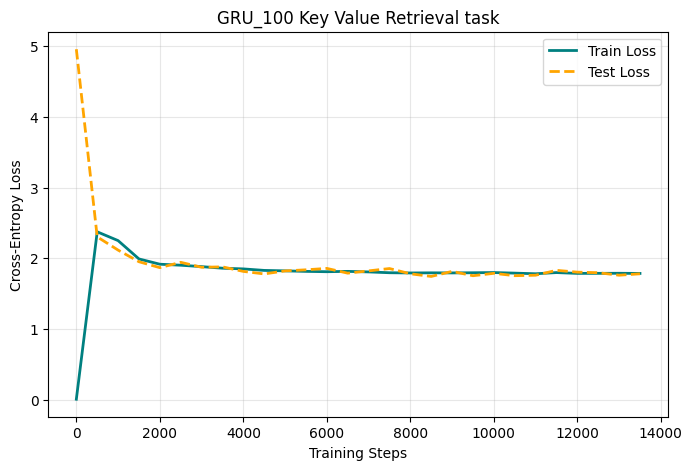

STEP: 13500 | TRAIN LOSS: 1.7867 | TEST LOSS: 1.7813


  0%|          | 0/10 [00:00<?, ?it/s]

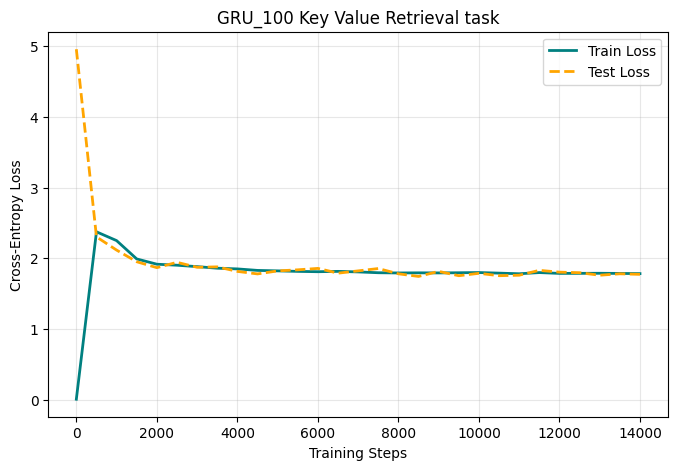

STEP: 14000 | TRAIN LOSS: 1.7839 | TEST LOSS: 1.7735


In [9]:
steps_history = []
train_history = []
test_history = []

run_training_ex5(GRU_model, 
                 batch_size, 
                 total_batches, 
                 test_batches, 
                 copy_size, 
                 buffer_size, 
                 opt_GRU, 
                 test_break=500, 
                 model_name="GRU_100",
                 steps_history=steps_history,
                 train_history=train_history,
                 test_history=test_history,
                 vocab=vocab)

  0%|          | 0/14001 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

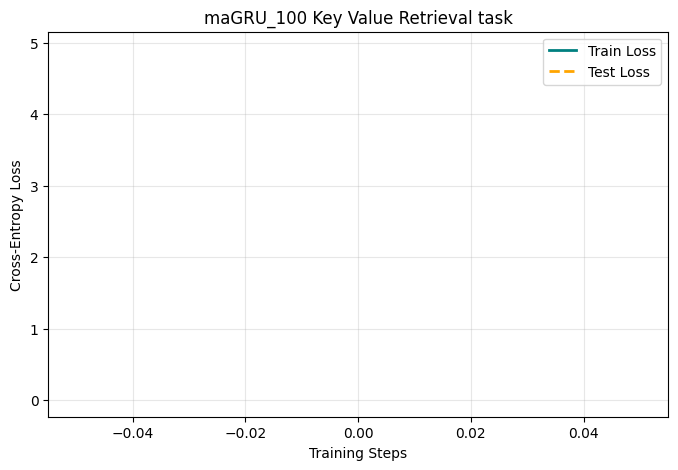

STEP: 0 | TRAIN LOSS: 0.0100 | TEST LOSS: 4.9122


  0%|          | 0/10 [00:00<?, ?it/s]

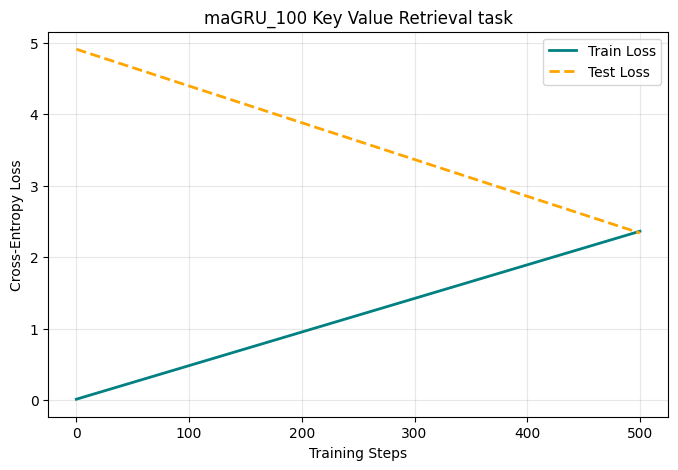

STEP: 500 | TRAIN LOSS: 2.3629 | TEST LOSS: 2.3378


  0%|          | 0/10 [00:00<?, ?it/s]

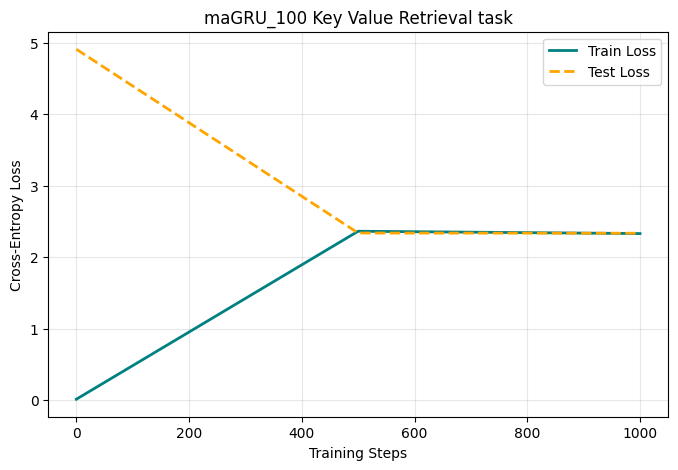

STEP: 1000 | TRAIN LOSS: 2.3300 | TEST LOSS: 2.3350


  0%|          | 0/10 [00:00<?, ?it/s]

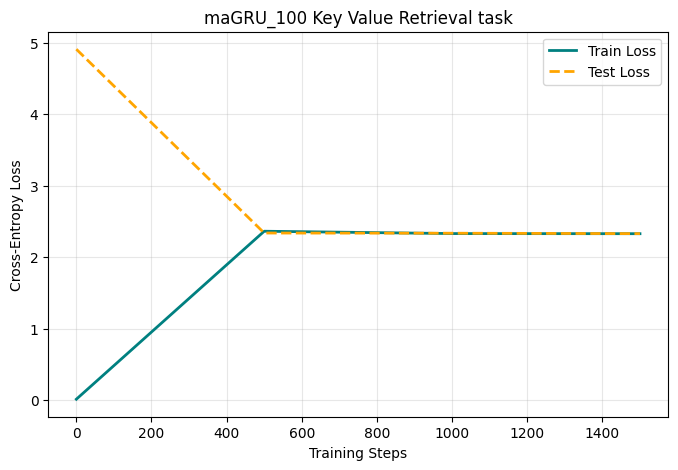

STEP: 1500 | TRAIN LOSS: 2.3283 | TEST LOSS: 2.3292


  0%|          | 0/10 [00:00<?, ?it/s]

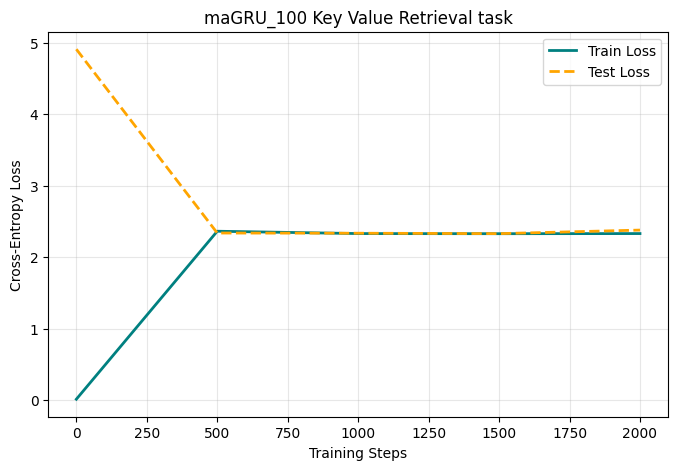

STEP: 2000 | TRAIN LOSS: 2.3302 | TEST LOSS: 2.3790


  0%|          | 0/10 [00:00<?, ?it/s]

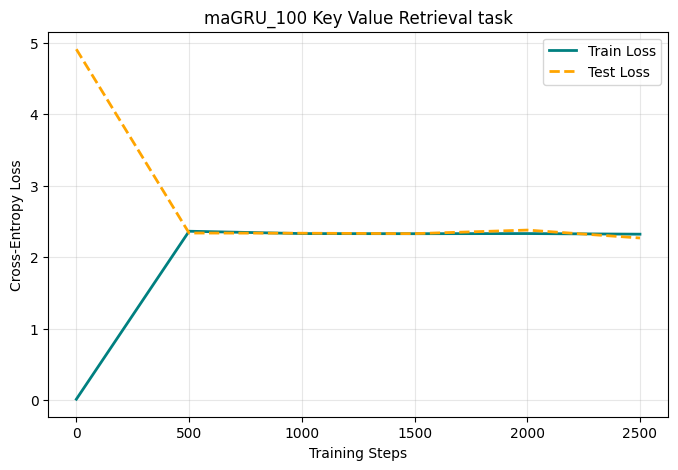

STEP: 2500 | TRAIN LOSS: 2.3215 | TEST LOSS: 2.2682


  0%|          | 0/10 [00:00<?, ?it/s]

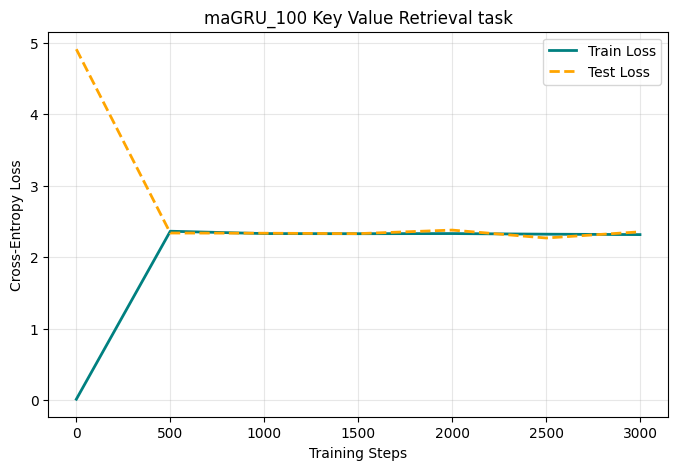

STEP: 3000 | TRAIN LOSS: 2.3156 | TEST LOSS: 2.3545


  0%|          | 0/10 [00:00<?, ?it/s]

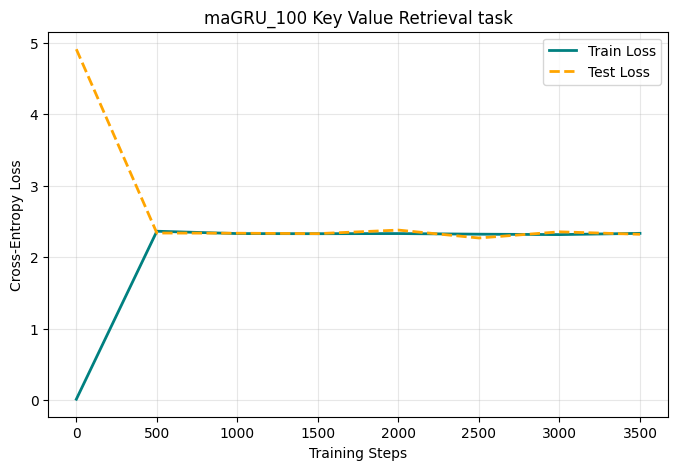

STEP: 3500 | TRAIN LOSS: 2.3333 | TEST LOSS: 2.3199


  0%|          | 0/10 [00:00<?, ?it/s]

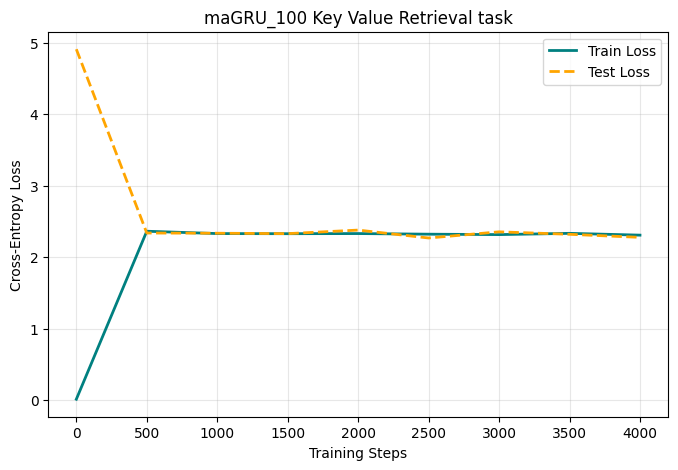

STEP: 4000 | TRAIN LOSS: 2.3081 | TEST LOSS: 2.2772


  0%|          | 0/10 [00:00<?, ?it/s]

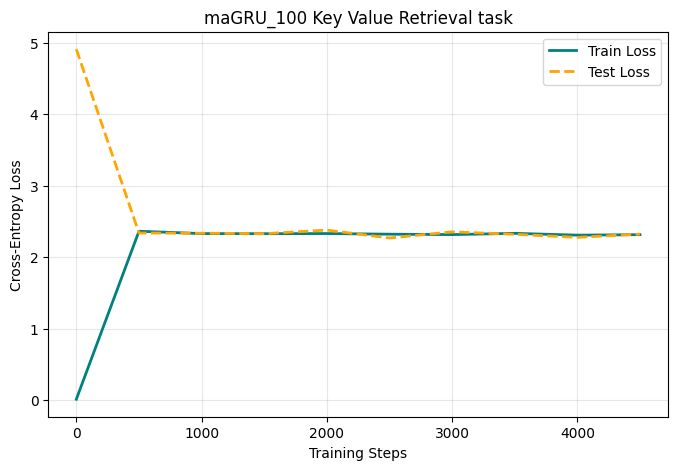

STEP: 4500 | TRAIN LOSS: 2.3147 | TEST LOSS: 2.3224


  0%|          | 0/10 [00:00<?, ?it/s]

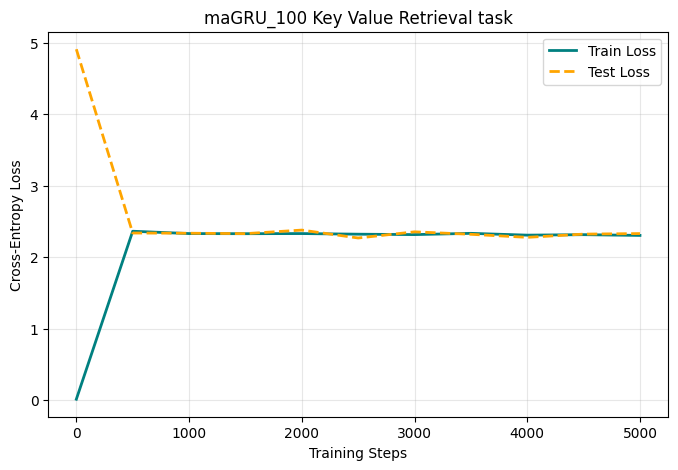

STEP: 5000 | TRAIN LOSS: 2.3042 | TEST LOSS: 2.3301


  0%|          | 0/10 [00:00<?, ?it/s]

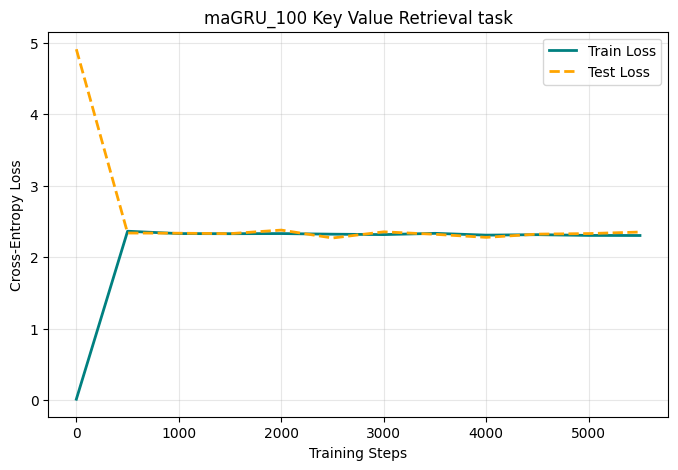

STEP: 5500 | TRAIN LOSS: 2.3032 | TEST LOSS: 2.3516


  0%|          | 0/10 [00:00<?, ?it/s]

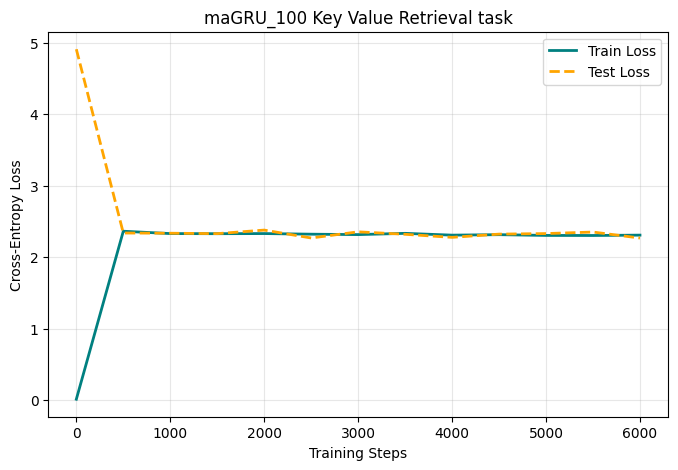

STEP: 6000 | TRAIN LOSS: 2.3083 | TEST LOSS: 2.2673


  0%|          | 0/10 [00:00<?, ?it/s]

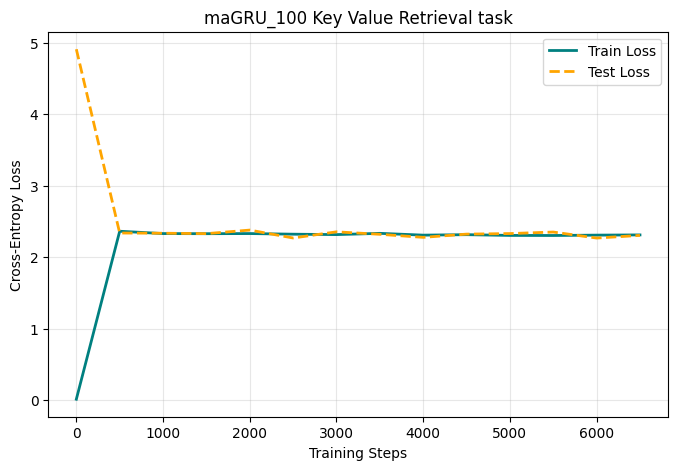

STEP: 6500 | TRAIN LOSS: 2.3112 | TEST LOSS: 2.3046


  0%|          | 0/10 [00:00<?, ?it/s]

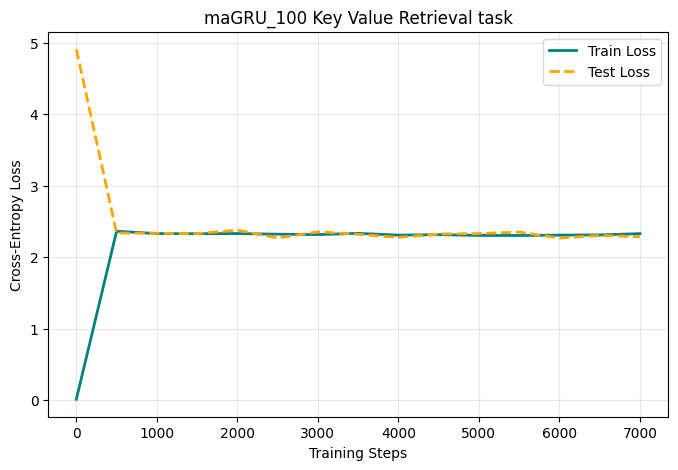

STEP: 7000 | TRAIN LOSS: 2.3293 | TEST LOSS: 2.2856


  0%|          | 0/10 [00:00<?, ?it/s]

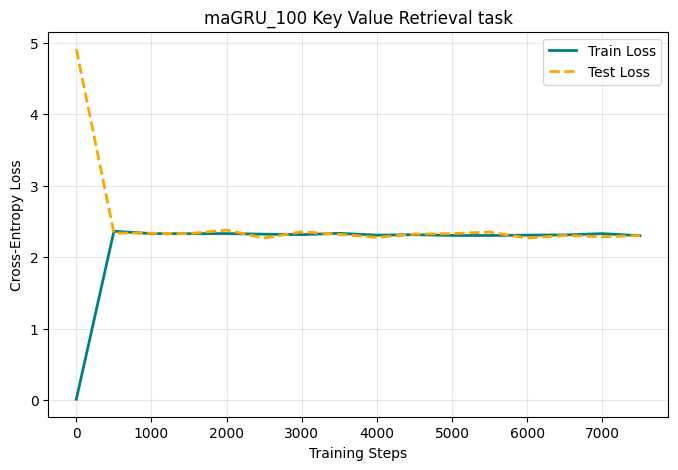

STEP: 7500 | TRAIN LOSS: 2.3002 | TEST LOSS: 2.3022


  0%|          | 0/10 [00:00<?, ?it/s]

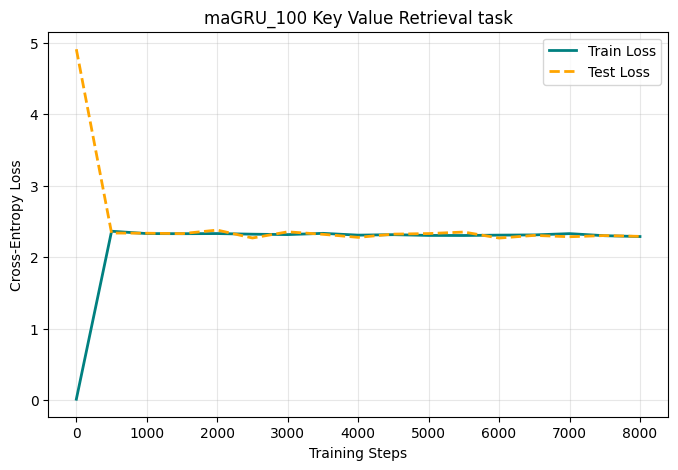

STEP: 8000 | TRAIN LOSS: 2.2885 | TEST LOSS: 2.2909


  0%|          | 0/10 [00:00<?, ?it/s]

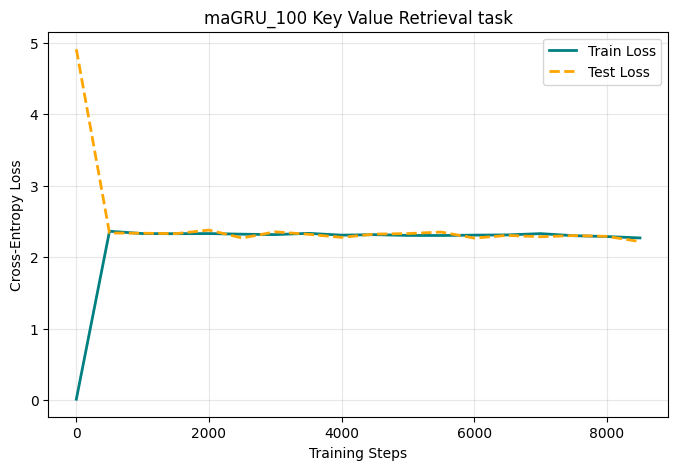

STEP: 8500 | TRAIN LOSS: 2.2688 | TEST LOSS: 2.2182


  0%|          | 0/10 [00:00<?, ?it/s]

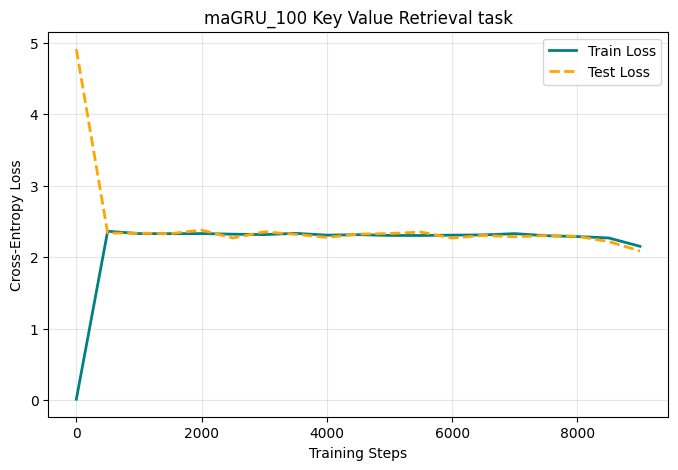

STEP: 9000 | TRAIN LOSS: 2.1516 | TEST LOSS: 2.0857


  0%|          | 0/10 [00:00<?, ?it/s]

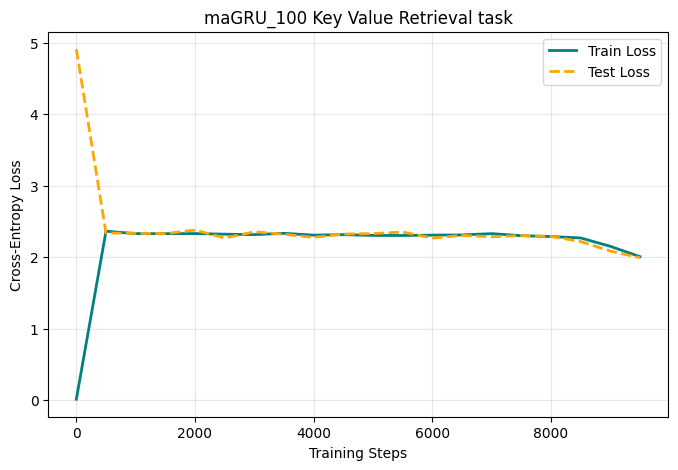

STEP: 9500 | TRAIN LOSS: 2.0067 | TEST LOSS: 1.9917


  0%|          | 0/10 [00:00<?, ?it/s]

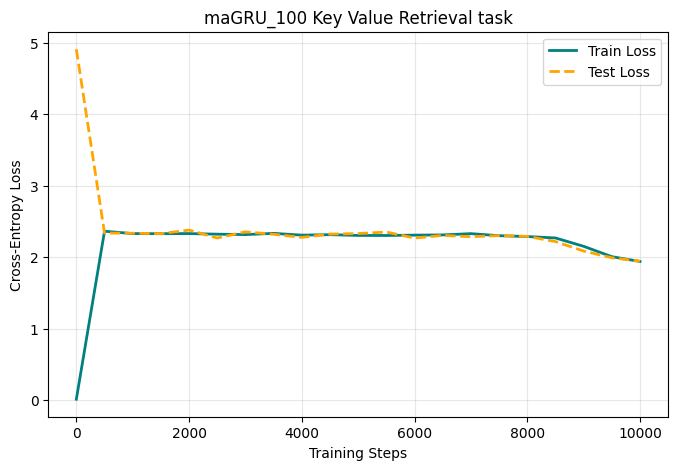

STEP: 10000 | TRAIN LOSS: 1.9391 | TEST LOSS: 1.9434


  0%|          | 0/10 [00:00<?, ?it/s]

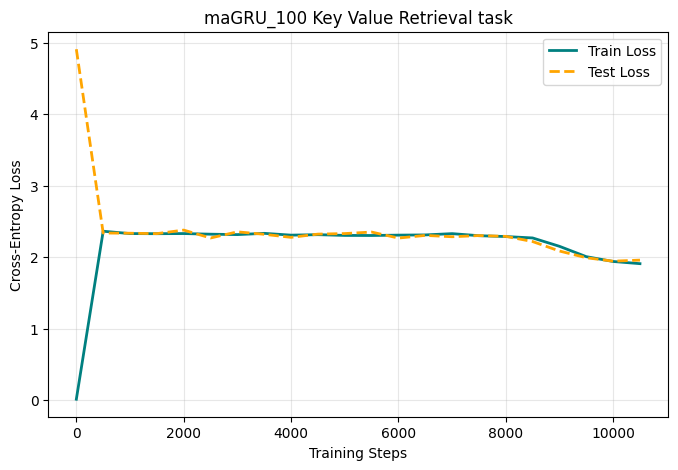

STEP: 10500 | TRAIN LOSS: 1.9086 | TEST LOSS: 1.9585


  0%|          | 0/10 [00:00<?, ?it/s]

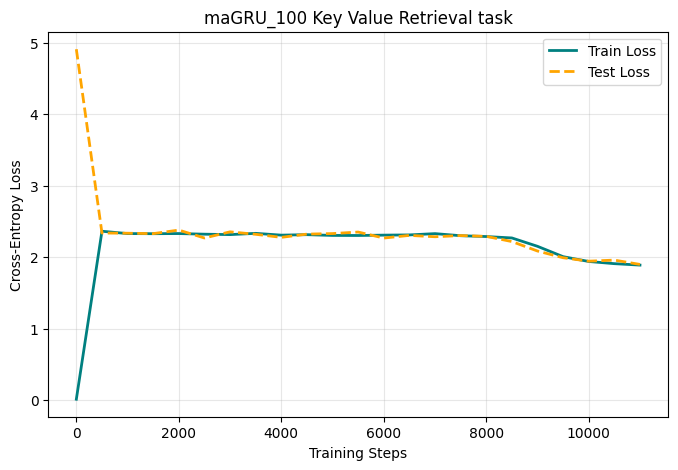

STEP: 11000 | TRAIN LOSS: 1.8886 | TEST LOSS: 1.8979


  0%|          | 0/10 [00:00<?, ?it/s]

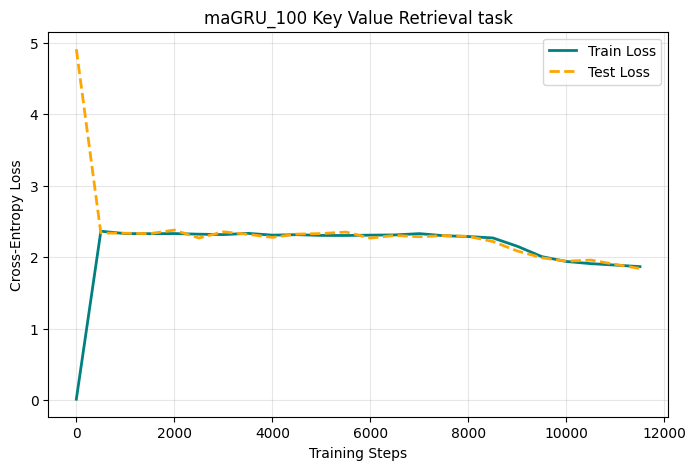

STEP: 11500 | TRAIN LOSS: 1.8669 | TEST LOSS: 1.8413


  0%|          | 0/10 [00:00<?, ?it/s]

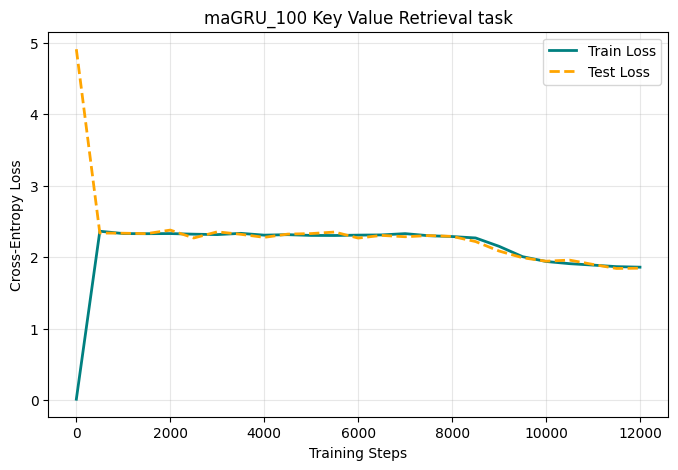

STEP: 12000 | TRAIN LOSS: 1.8595 | TEST LOSS: 1.8455


  0%|          | 0/10 [00:00<?, ?it/s]

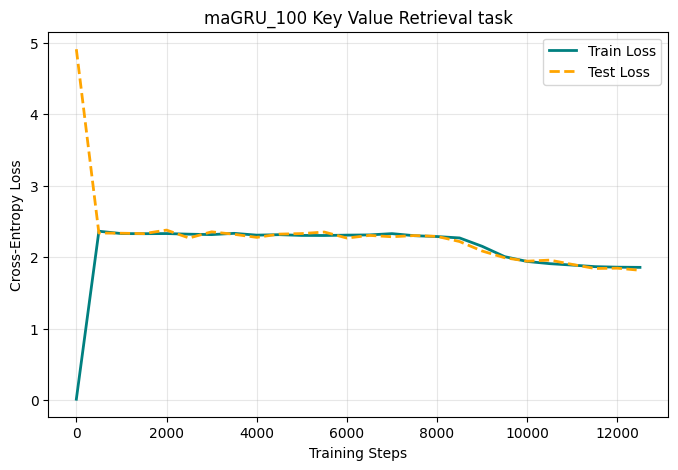

STEP: 12500 | TRAIN LOSS: 1.8568 | TEST LOSS: 1.8158


  0%|          | 0/10 [00:00<?, ?it/s]

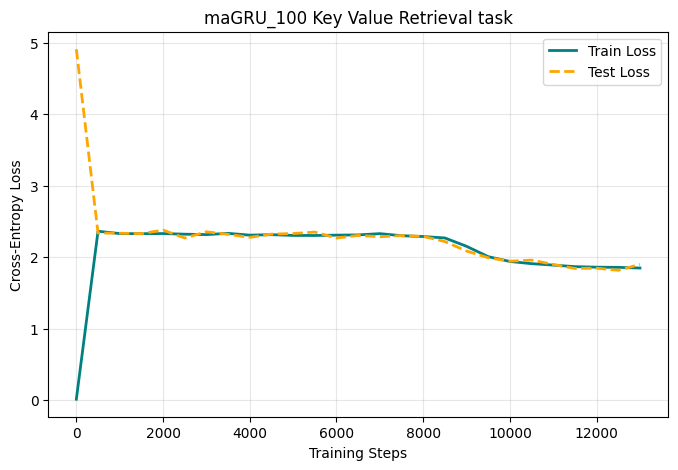

STEP: 13000 | TRAIN LOSS: 1.8474 | TEST LOSS: 1.8983


  0%|          | 0/10 [00:00<?, ?it/s]

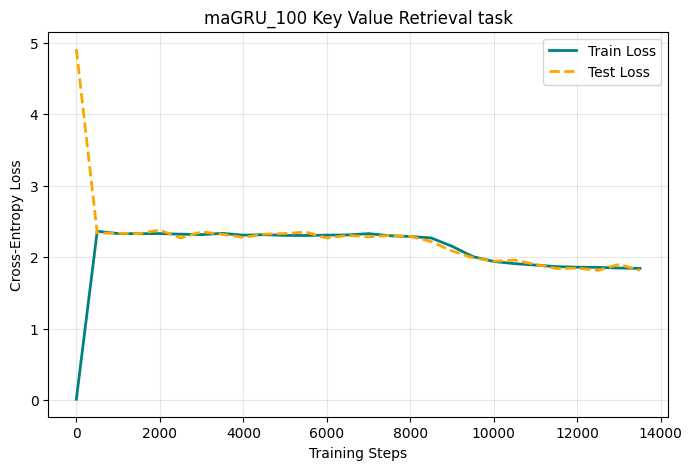

STEP: 13500 | TRAIN LOSS: 1.8420 | TEST LOSS: 1.8159


  0%|          | 0/10 [00:00<?, ?it/s]

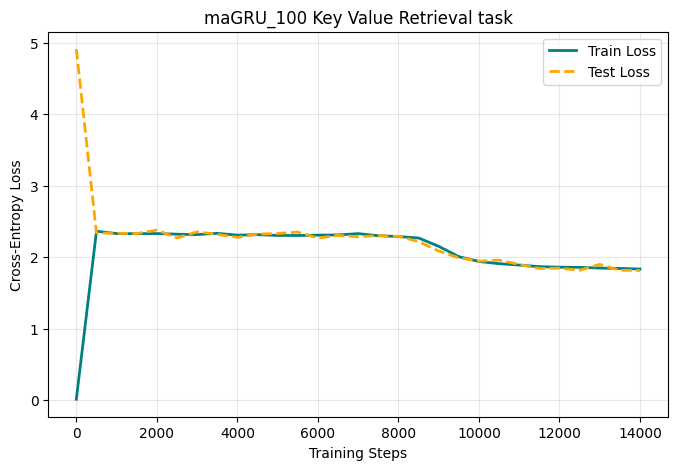

STEP: 14000 | TRAIN LOSS: 1.8331 | TEST LOSS: 1.8131


In [10]:
steps_history = []
train_history = []
test_history = []

run_training_ex5(maGRU_model, 
                 batch_size, 
                 total_batches, 
                 test_batches, 
                 copy_size, 
                 buffer_size, 
                 opt_maGRU, 
                 test_break=500, 
                 model_name="maGRU_100",
                 steps_history=steps_history,
                 train_history=train_history,
                 test_history=test_history,
                 vocab=vocab)

  0%|          | 0/14001 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

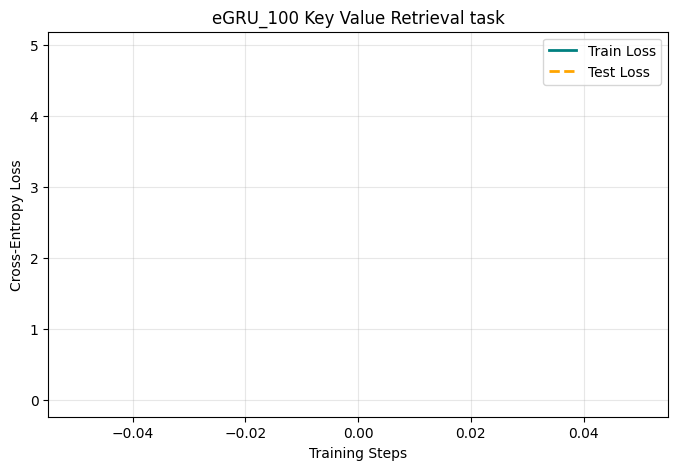

STEP: 0 | TRAIN LOSS: 0.0100 | TEST LOSS: 4.9422


  0%|          | 0/10 [00:00<?, ?it/s]

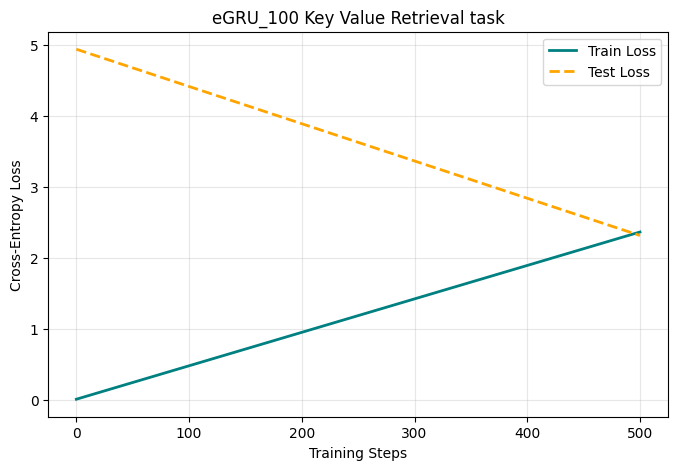

STEP: 500 | TRAIN LOSS: 2.3665 | TEST LOSS: 2.3172


  0%|          | 0/10 [00:00<?, ?it/s]

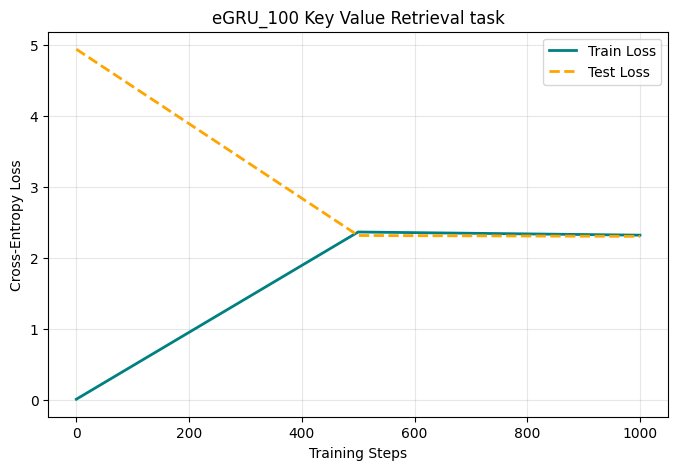

STEP: 1000 | TRAIN LOSS: 2.3220 | TEST LOSS: 2.3051


  0%|          | 0/10 [00:00<?, ?it/s]

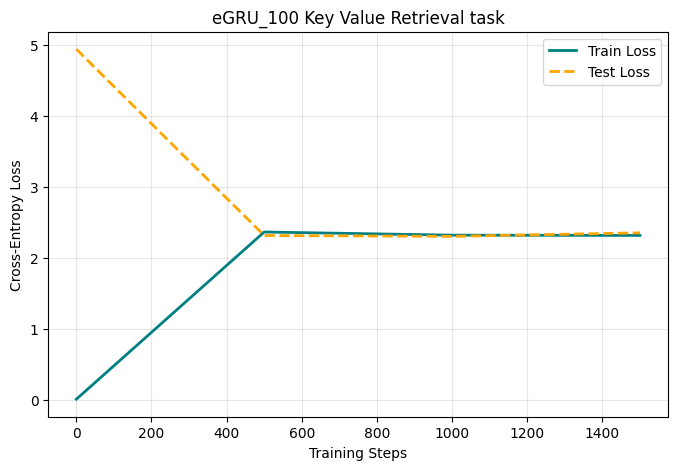

STEP: 1500 | TRAIN LOSS: 2.3181 | TEST LOSS: 2.3549


  0%|          | 0/10 [00:00<?, ?it/s]

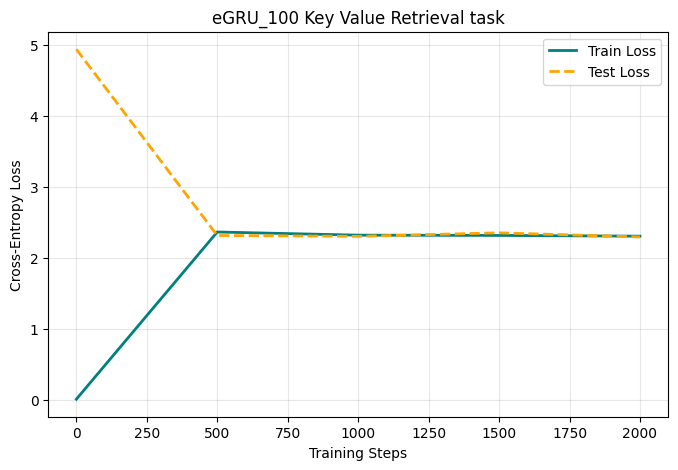

STEP: 2000 | TRAIN LOSS: 2.3078 | TEST LOSS: 2.2966


  0%|          | 0/10 [00:00<?, ?it/s]

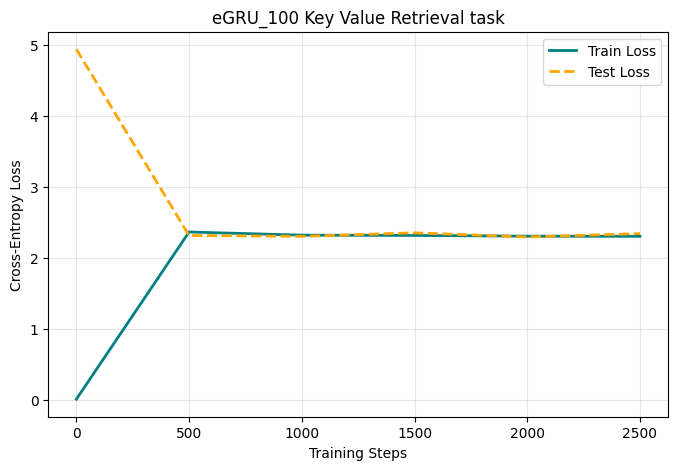

STEP: 2500 | TRAIN LOSS: 2.3056 | TEST LOSS: 2.3435


  0%|          | 0/10 [00:00<?, ?it/s]

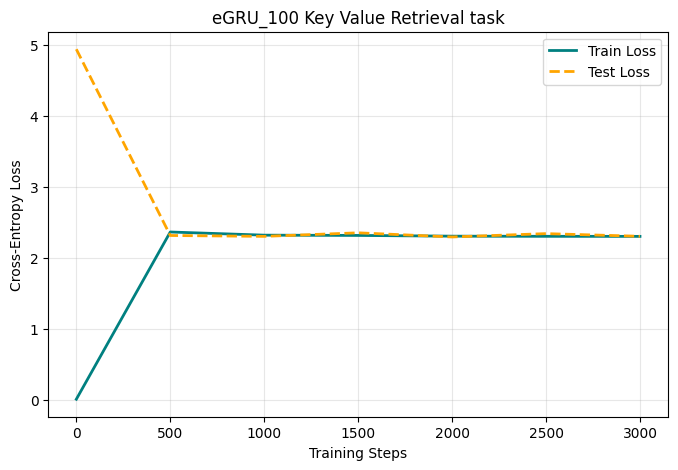

STEP: 3000 | TRAIN LOSS: 2.3047 | TEST LOSS: 2.3059


  0%|          | 0/10 [00:00<?, ?it/s]

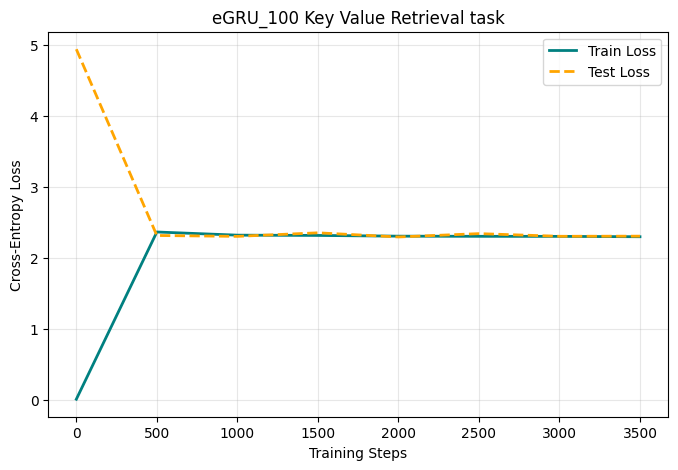

STEP: 3500 | TRAIN LOSS: 2.2998 | TEST LOSS: 2.3079


  0%|          | 0/10 [00:00<?, ?it/s]

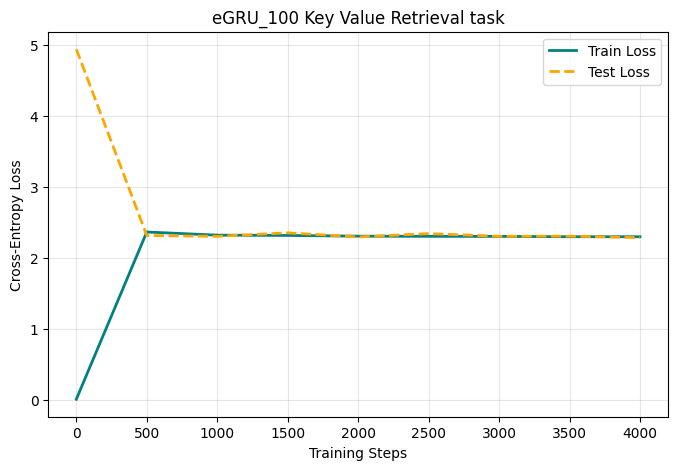

STEP: 4000 | TRAIN LOSS: 2.2998 | TEST LOSS: 2.2874


  0%|          | 0/10 [00:00<?, ?it/s]

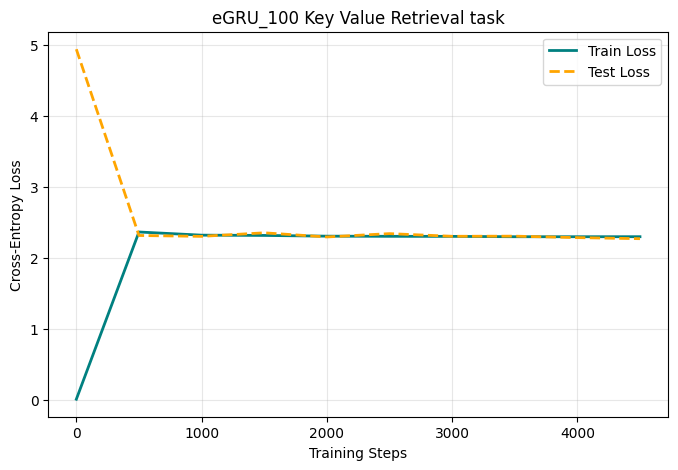

STEP: 4500 | TRAIN LOSS: 2.3003 | TEST LOSS: 2.2722


  0%|          | 0/10 [00:00<?, ?it/s]

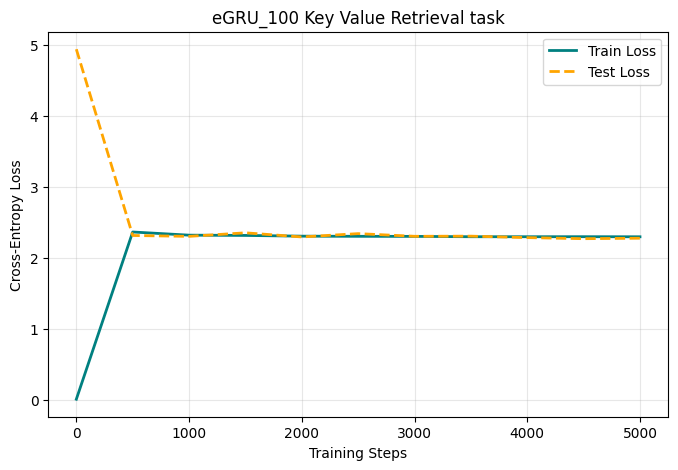

STEP: 5000 | TRAIN LOSS: 2.2991 | TEST LOSS: 2.2790


  0%|          | 0/10 [00:00<?, ?it/s]

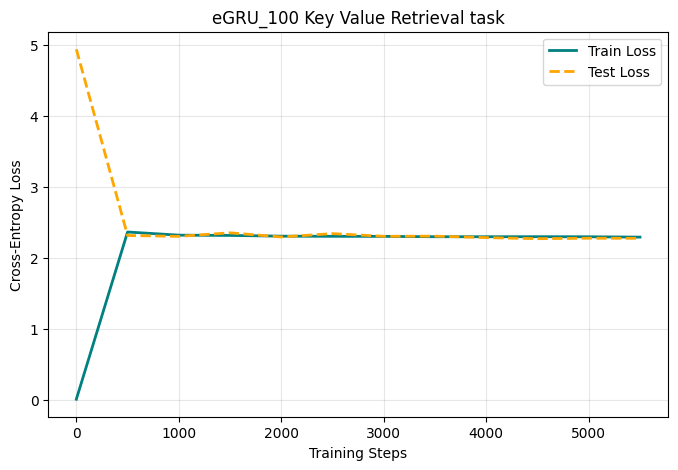

STEP: 5500 | TRAIN LOSS: 2.2944 | TEST LOSS: 2.2776


  0%|          | 0/10 [00:00<?, ?it/s]

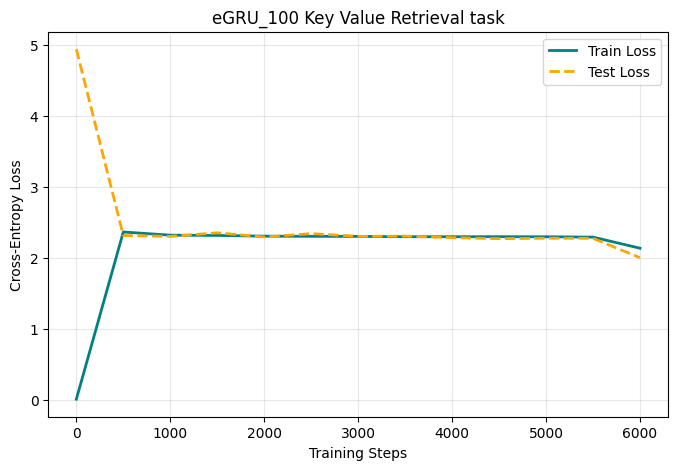

STEP: 6000 | TRAIN LOSS: 2.1383 | TEST LOSS: 2.0042


  0%|          | 0/10 [00:00<?, ?it/s]

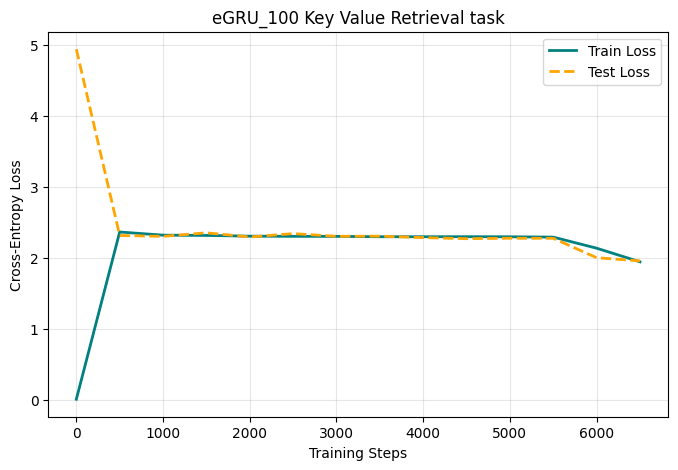

STEP: 6500 | TRAIN LOSS: 1.9460 | TEST LOSS: 1.9595


  0%|          | 0/10 [00:00<?, ?it/s]

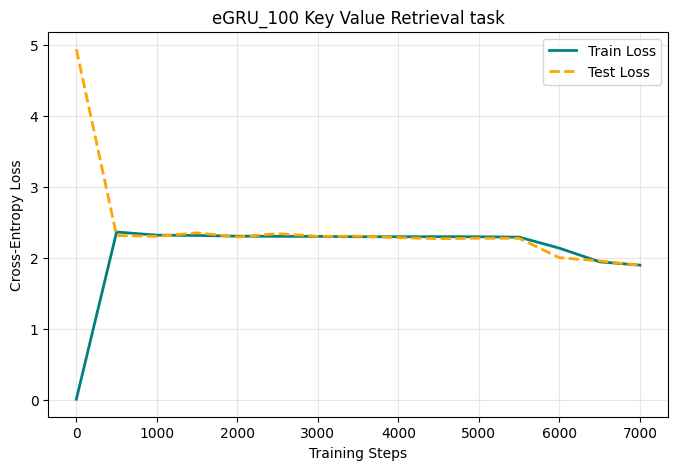

STEP: 7000 | TRAIN LOSS: 1.8992 | TEST LOSS: 1.8952


  0%|          | 0/10 [00:00<?, ?it/s]

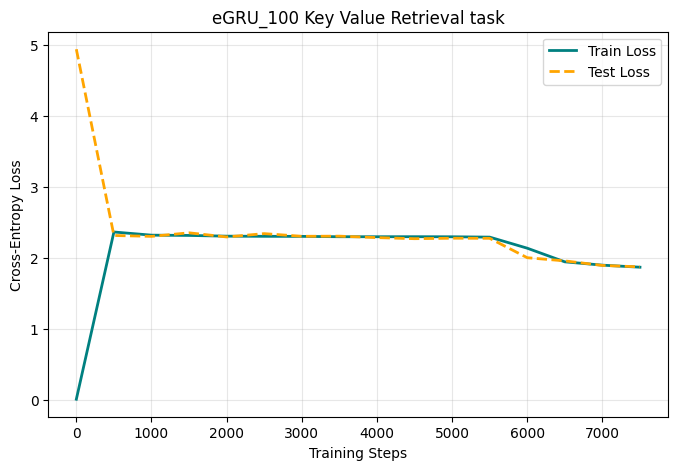

STEP: 7500 | TRAIN LOSS: 1.8704 | TEST LOSS: 1.8755


  0%|          | 0/10 [00:00<?, ?it/s]

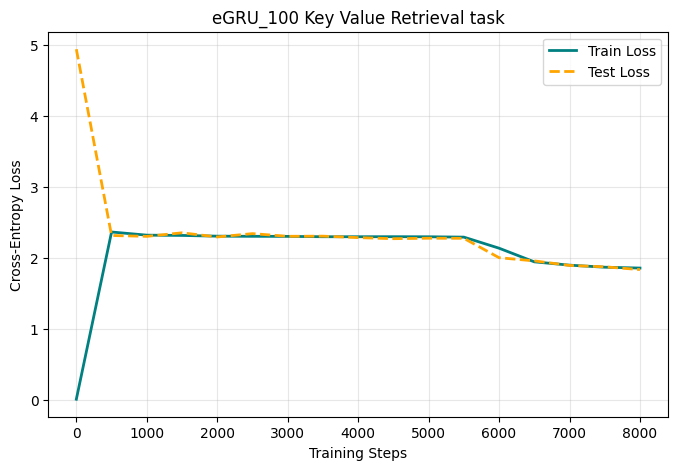

STEP: 8000 | TRAIN LOSS: 1.8583 | TEST LOSS: 1.8369


  0%|          | 0/10 [00:00<?, ?it/s]

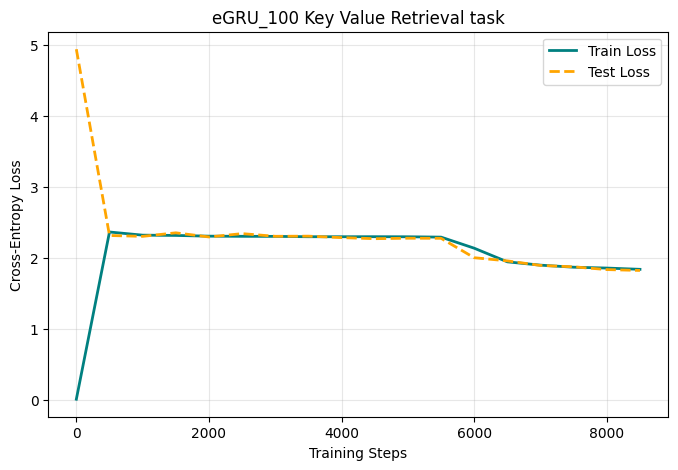

STEP: 8500 | TRAIN LOSS: 1.8404 | TEST LOSS: 1.8245


  0%|          | 0/10 [00:00<?, ?it/s]

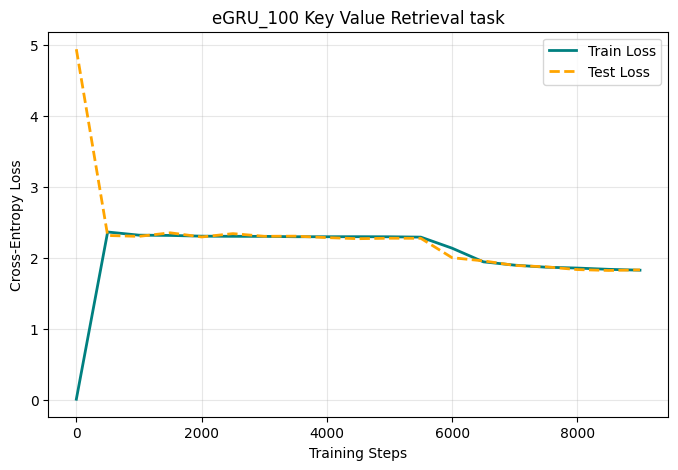

STEP: 9000 | TRAIN LOSS: 1.8283 | TEST LOSS: 1.8329


  0%|          | 0/10 [00:00<?, ?it/s]

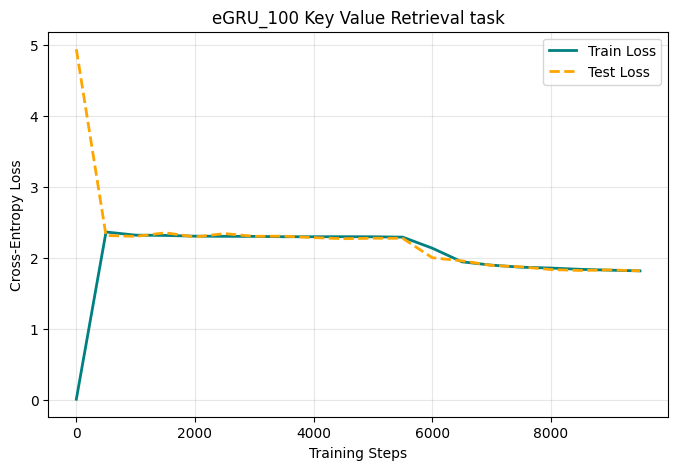

STEP: 9500 | TRAIN LOSS: 1.8186 | TEST LOSS: 1.8188


  0%|          | 0/10 [00:00<?, ?it/s]

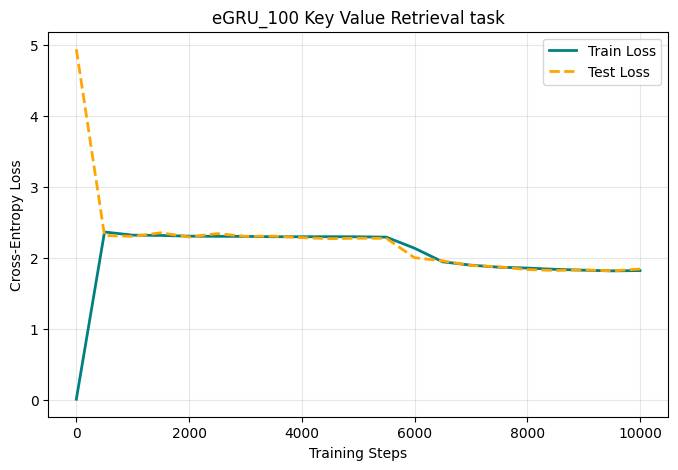

STEP: 10000 | TRAIN LOSS: 1.8230 | TEST LOSS: 1.8445


  0%|          | 0/10 [00:00<?, ?it/s]

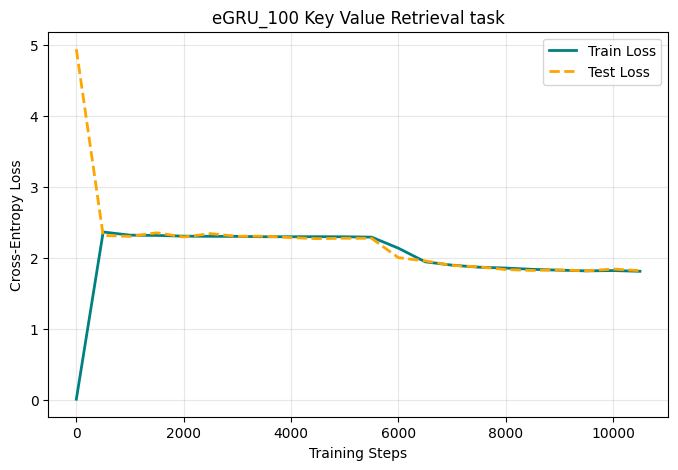

STEP: 10500 | TRAIN LOSS: 1.8126 | TEST LOSS: 1.8218


  0%|          | 0/10 [00:00<?, ?it/s]

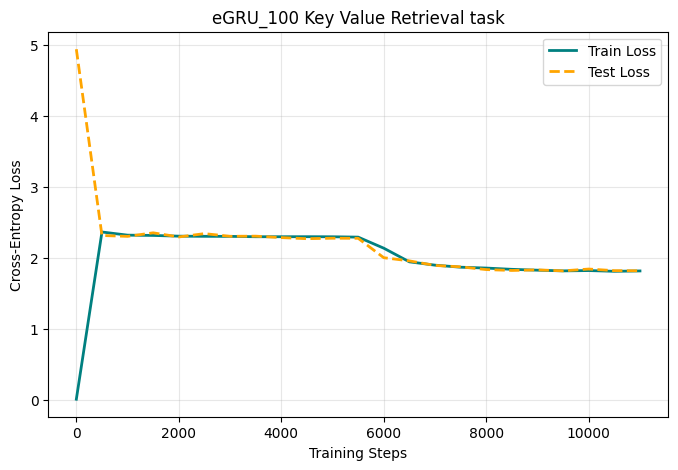

STEP: 11000 | TRAIN LOSS: 1.8178 | TEST LOSS: 1.8199


  0%|          | 0/10 [00:00<?, ?it/s]

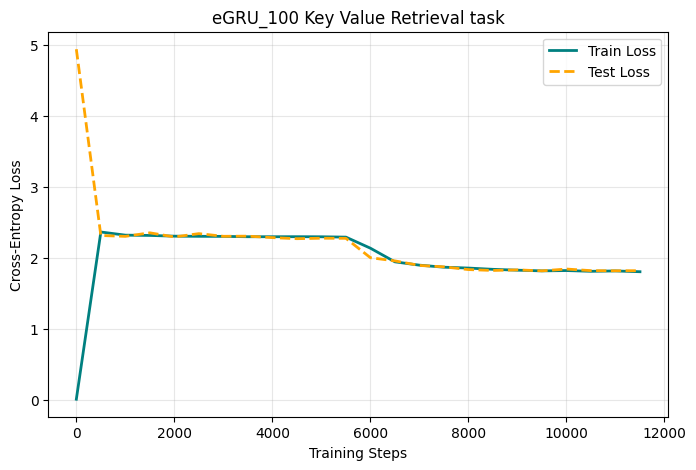

STEP: 11500 | TRAIN LOSS: 1.8067 | TEST LOSS: 1.8214


  0%|          | 0/10 [00:00<?, ?it/s]

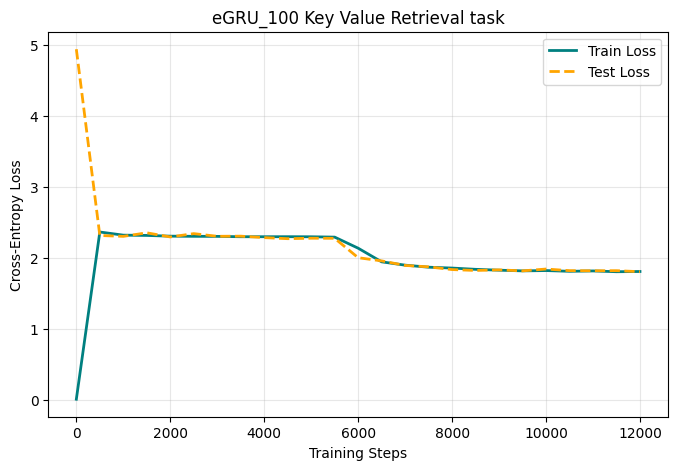

STEP: 12000 | TRAIN LOSS: 1.8099 | TEST LOSS: 1.8072


  0%|          | 0/10 [00:00<?, ?it/s]

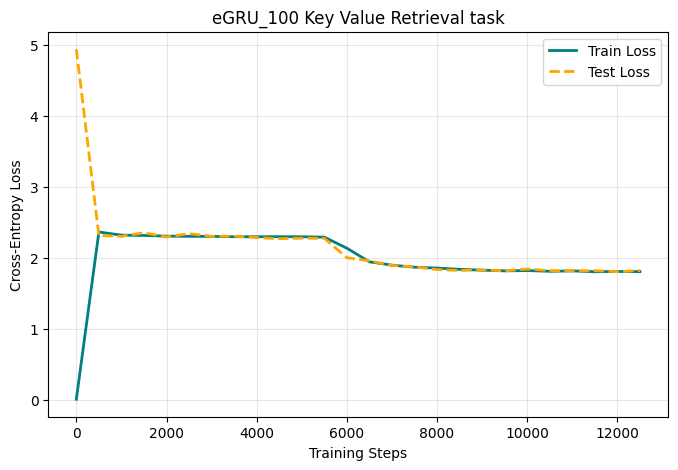

STEP: 12500 | TRAIN LOSS: 1.8080 | TEST LOSS: 1.8230


  0%|          | 0/10 [00:00<?, ?it/s]

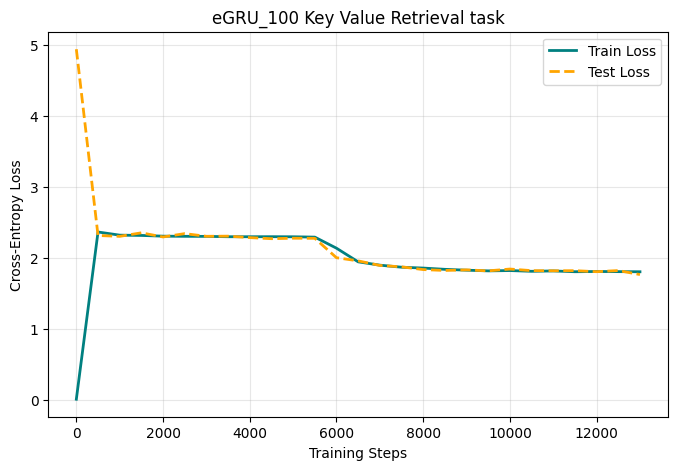

STEP: 13000 | TRAIN LOSS: 1.8062 | TEST LOSS: 1.7668


  0%|          | 0/10 [00:00<?, ?it/s]

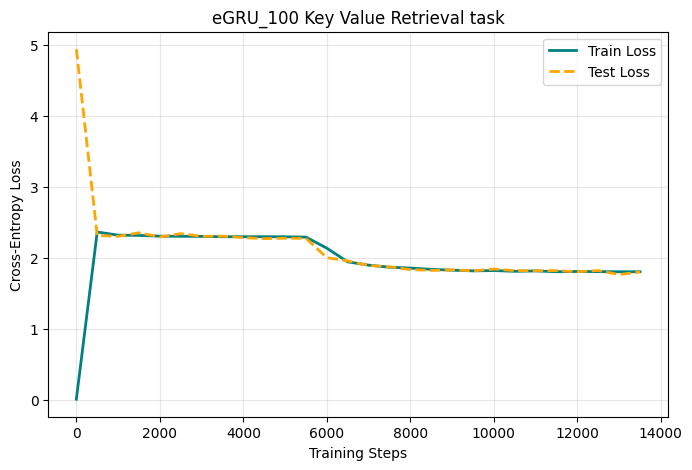

STEP: 13500 | TRAIN LOSS: 1.8068 | TEST LOSS: 1.8042


  0%|          | 0/10 [00:00<?, ?it/s]

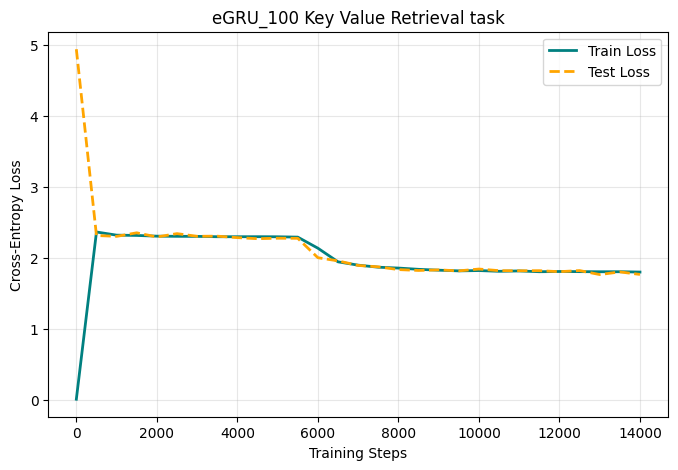

STEP: 14000 | TRAIN LOSS: 1.8019 | TEST LOSS: 1.7683


In [11]:
steps_history = []
train_history = []
test_history = []

run_training_ex5(eGRU_model, 
                 batch_size, 
                 total_batches, 
                 test_batches, 
                 copy_size, 
                 buffer_size, 
                 opt_eGRU, 
                 test_break=500, 
                 model_name="eGRU_100",
                 steps_history=steps_history,
                 train_history=train_history,
                 test_history=test_history,
                 vocab=vocab)

## Testing the models!

In [5]:
def load_model(filename, device, model, optimizer):
    checkpoint = torch.load(filename, map_location=device)
    model.load_state_dict(checkpoint["model_state_dict"])
    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
    start_epoch = checkpoint["epoch_saved"] + 1
    return start_epoch

In [6]:
hid=256
emb=len(vocab)
lr=1e-3
batch_size=32
test_batches=100

steps_history = []
train_history = []
test_history = []

In [7]:

load_model("./models/ex5/mLSTM_100_ex5_epoch_7000.pt", "cuda", mLSTM_model, opt_mLSTM)
load_model("./models/ex5/LSTM_100_ex5_epoch_7000.pt", "cuda", LSTM_model, opt_LSTM)
load_model("./models/ex5/mLSTMLite_100_ex5_epoch_7000.pt", "cuda", mLSTMLite_model, opt_mLSTMLite)
load_model("./models/ex5/sLSTM_100_ex5_epoch_7000.pt", "cuda", sLSTM_model, opt_sLSTM)
load_model("./models/ex5/MGU_100_ex5_epoch_7000.pt", "cuda", MGU_model, opt_MGU)
load_model("./models/ex5/maGRU_100_ex5_epoch_7000.pt", "cuda", maGRU_model, opt_maGRU)
load_model("./models/ex5/GRU_100_ex5_epoch_7000.pt", "cuda", GRU_model, opt_GRU)
load_model("./models/ex5/eGRU_100_ex5_epoch_7000.pt", "cuda", eGRU_model, opt_eGRU)

7001

In [19]:
ex1_mlstm_50 =   evaluate_ex5(mLSTM_model, lookup_size=1, teacher_forcing=False, pairs=5,  total_batches=test_batches, batch_size=batch_size, vocab=vocab)
ex1_mlstm_100 =  evaluate_ex5(mLSTM_model, lookup_size=1, teacher_forcing=False, pairs=10, total_batches=test_batches, batch_size=batch_size, vocab=vocab)
ex1_mlstm_250 =  evaluate_ex5(mLSTM_model, lookup_size=1, teacher_forcing=False, pairs=15, total_batches=test_batches, batch_size=batch_size, vocab=vocab)
ex1_mlstm_500 =  evaluate_ex5(mLSTM_model, lookup_size=1, teacher_forcing=False, pairs=20, total_batches=test_batches, batch_size=batch_size, vocab=vocab)
ex1_mlstm_750 =  evaluate_ex5(mLSTM_model, lookup_size=1, teacher_forcing=False, pairs=30, total_batches=test_batches, batch_size=batch_size, vocab=vocab)
ex1_mlstm_1000 = evaluate_ex5(mLSTM_model, lookup_size=1, teacher_forcing=False, pairs=50, total_batches=test_batches, batch_size=batch_size, vocab=vocab)

print("mLSTM noise sorting difference at buffer_size=50: ",   ex1_mlstm_50)
print("mLSTM noise sorting difference at buffer_size=100: ",  ex1_mlstm_100)
print("mLSTM noise sorting difference at buffer_size=250: ",  ex1_mlstm_250)
print("mLSTM noise sorting difference at buffer_size=500: ",  ex1_mlstm_500)
print("mLSTM noise sorting difference at buffer_size=750: ",  ex1_mlstm_750)
print("mLSTM noise sorting difference at buffer_size=1000: ", ex1_mlstm_1000)

Testing model at  10  buffer_size.


  0%|          | 0/101 [00:00<?, ?it/s]

Testing model at  10  buffer_size.


  0%|          | 0/101 [00:00<?, ?it/s]

Testing model at  10  buffer_size.


...

Testing model at  10  buffer_size.


  0%|          | 0/101 [00:00<?, ?it/s]

Testing model at  10  buffer_size.


  0%|          | 0/101 [00:00<?, ?it/s]

mLSTM noise sorting difference at buffer_size=50:  0.6568688118811881
mLSTM noise sorting difference at buffer_size=100:  0.7298886138613861
mLSTM noise sorting difference at buffer_size=250:  0.7589727722772277
mLSTM noise sorting difference at buffer_size=500:  0.7778465346534653
mLSTM noise sorting difference at buffer_size=750:  0.8109529702970297
mLSTM noise sorting difference at buffer_size=1000:  0.8298267326732673


In [18]:
ex1_mlstmlite_50 =   evaluate_ex5(mLSTMLite_model, lookup_size=1, teacher_forcing=False, pairs=5,  total_batches=test_batches, batch_size=batch_size, vocab=vocab)
ex1_mlstmlite_100 =  evaluate_ex5(mLSTMLite_model, lookup_size=1, teacher_forcing=False, pairs=10, total_batches=test_batches, batch_size=batch_size, vocab=vocab)
ex1_mlstmlite_250 =  evaluate_ex5(mLSTMLite_model, lookup_size=1, teacher_forcing=False, pairs=15, total_batches=test_batches, batch_size=batch_size, vocab=vocab)
ex1_mlstmlite_500 =  evaluate_ex5(mLSTMLite_model, lookup_size=1, teacher_forcing=False, pairs=20, total_batches=test_batches, batch_size=batch_size, vocab=vocab)
ex1_mlstmlite_750 =  evaluate_ex5(mLSTMLite_model, lookup_size=1, teacher_forcing=False, pairs=30, total_batches=test_batches, batch_size=batch_size, vocab=vocab)
ex1_mlstmlite_1000 = evaluate_ex5(mLSTMLite_model, lookup_size=1, teacher_forcing=False, pairs=50, total_batches=test_batches, batch_size=batch_size, vocab=vocab)

print("mLSTMLite noise sorting difference at buffer_size=50: ",   ex1_mlstmlite_50)
print("mLSTMLite noise sorting difference at buffer_size=100: ",  ex1_mlstmlite_100)
print("mLSTMLite noise sorting difference at buffer_size=250: ",  ex1_mlstmlite_250)
print("mLSTMLite noise sorting difference at buffer_size=500: ",  ex1_mlstmlite_500)
print("mLSTMLite noise sorting difference at buffer_size=750: ",  ex1_mlstmlite_750)
print("mLSTMLite noise sorting difference at buffer_size=1000: ", ex1_mlstmlite_1000)

Testing model at  10  buffer_size.


  0%|          | 0/101 [00:00<?, ?it/s]

Testing model at  10  buffer_size.


  0%|          | 0/101 [00:00<?, ?it/s]

Testing model at  10  buffer_size.


...

Testing model at  10  buffer_size.


  0%|          | 0/101 [00:00<?, ?it/s]

Testing model at  10  buffer_size.


  0%|          | 0/101 [00:00<?, ?it/s]

mLSTMLite noise sorting difference at buffer_size=50:  0.650680693069307
mLSTMLite noise sorting difference at buffer_size=100:  0.7165841584158416
mLSTMLite noise sorting difference at buffer_size=250:  0.7509282178217822
mLSTMLite noise sorting difference at buffer_size=500:  0.7691831683168316
mLSTMLite noise sorting difference at buffer_size=750:  0.812809405940594
mLSTMLite noise sorting difference at buffer_size=1000:  0.8220915841584159


In [20]:
ex1_cgru_50 =   evaluate_ex5(GRU_model, lookup_size=1, teacher_forcing=False, pairs=5,  total_batches=test_batches, batch_size=batch_size, vocab=vocab)
ex1_cgru_100 =  evaluate_ex5(GRU_model, lookup_size=1, teacher_forcing=False, pairs=10, total_batches=test_batches, batch_size=batch_size, vocab=vocab)
ex1_cgru_250 =  evaluate_ex5(GRU_model, lookup_size=1, teacher_forcing=False, pairs=15, total_batches=test_batches, batch_size=batch_size, vocab=vocab)
ex1_cgru_500 =  evaluate_ex5(GRU_model, lookup_size=1, teacher_forcing=False, pairs=20, total_batches=test_batches, batch_size=batch_size, vocab=vocab)
ex1_cgru_750 =  evaluate_ex5(GRU_model, lookup_size=1, teacher_forcing=False, pairs=30, total_batches=test_batches, batch_size=batch_size, vocab=vocab)
ex1_cgru_1000 = evaluate_ex5(GRU_model, lookup_size=1, teacher_forcing=False, pairs=50, total_batches=test_batches, batch_size=batch_size, vocab=vocab)

print("GRU noise sorting difference at buffer_size=50: ", ex1_cgru_50)
print("GRU noise sorting difference at buffer_size=100: ", ex1_cgru_100)
print("GRU noise sorting difference at buffer_size=250: ", ex1_cgru_250)
print("GRU noise sorting difference at buffer_size=500: ", ex1_cgru_500)
print("GRU noise sorting difference at buffer_size=750: ", ex1_cgru_750)
print("GRU noise sorting difference at buffer_size=1000: ", ex1_cgru_1000)

Testing model at  10  buffer_size.


  0%|          | 0/101 [00:00<?, ?it/s]

Testing model at  10  buffer_size.


  0%|          | 0/101 [00:00<?, ?it/s]

Testing model at  10  buffer_size.


...

Testing model at  10  buffer_size.


  0%|          | 0/101 [00:00<?, ?it/s]

Testing model at  10  buffer_size.


  0%|          | 0/101 [00:00<?, ?it/s]

GRU noise sorting difference at buffer_size=50:  0.6466584158415841
GRU noise sorting difference at buffer_size=100:  0.7441212871287128
GRU noise sorting difference at buffer_size=250:  0.7685643564356436
GRU noise sorting difference at buffer_size=500:  0.7908415841584159
GRU noise sorting difference at buffer_size=750:  0.8131188118811881
GRU noise sorting difference at buffer_size=1000:  0.8152846534653465


In [21]:
ex1_mgu_50 =   evaluate_ex5(MGU_model, lookup_size=1, teacher_forcing=False, pairs=5,   total_batches=test_batches, batch_size=batch_size, vocab=vocab)
ex1_mgu_100 =  evaluate_ex5(MGU_model, lookup_size=1, teacher_forcing=False, pairs=10, total_batches=test_batches, batch_size=batch_size, vocab=vocab)
ex1_mgu_250 =  evaluate_ex5(MGU_model, lookup_size=1, teacher_forcing=False, pairs=15, total_batches=test_batches, batch_size=batch_size, vocab=vocab)
ex1_mgu_500 =  evaluate_ex5(MGU_model, lookup_size=1, teacher_forcing=False, pairs=20, total_batches=test_batches, batch_size=batch_size, vocab=vocab)
ex1_mgu_750 =  evaluate_ex5(MGU_model, lookup_size=1, teacher_forcing=False, pairs=30, total_batches=test_batches, batch_size=batch_size, vocab=vocab)
ex1_mgu_1000 = evaluate_ex5(MGU_model, lookup_size=1, teacher_forcing=False, pairs=50, total_batches=test_batches, batch_size=batch_size, vocab=vocab)

print("MGU noise sorting difference at buffer_size=50: ",   ex1_mgu_50)
print("MGU noise sorting difference at buffer_size=100: ",  ex1_mgu_100)
print("MGU noise sorting difference at buffer_size=250: ",  ex1_mgu_250)
print("MGU noise sorting difference at buffer_size=500: ",  ex1_mgu_500)
print("MGU noise sorting difference at buffer_size=750: ",  ex1_mgu_750)
print("MGU noise sorting difference at buffer_size=1000: ", ex1_mgu_1000)

Testing model at  10  buffer_size.


  0%|          | 0/101 [00:00<?, ?it/s]

Testing model at  10  buffer_size.


  0%|          | 0/101 [00:00<?, ?it/s]

Testing model at  10  buffer_size.


...

Testing model at  10  buffer_size.


  0%|          | 0/101 [00:00<?, ?it/s]

Testing model at  10  buffer_size.


  0%|          | 0/101 [00:00<?, ?it/s]

MGU noise sorting difference at buffer_size=50:  0.7945544554455446
MGU noise sorting difference at buffer_size=100:  0.8483910891089109
MGU noise sorting difference at buffer_size=250:  0.8737623762376238
MGU noise sorting difference at buffer_size=500:  0.8845915841584159
MGU noise sorting difference at buffer_size=750:  0.8845915841584159
MGU noise sorting difference at buffer_size=1000:  0.8972772277227723


In [22]:
ex1_slstm_50 =   evaluate_ex5(sLSTM_model, lookup_size=1, teacher_forcing=False, pairs=5,   total_batches=test_batches, batch_size=batch_size, vocab=vocab)
ex1_slstm_100 =  evaluate_ex5(sLSTM_model, lookup_size=1, teacher_forcing=False, pairs=10, total_batches=test_batches, batch_size=batch_size, vocab=vocab)
ex1_slstm_250 =  evaluate_ex5(sLSTM_model, lookup_size=1, teacher_forcing=False, pairs=15, total_batches=test_batches, batch_size=batch_size, vocab=vocab)
ex1_slstm_500 =  evaluate_ex5(sLSTM_model, lookup_size=1, teacher_forcing=False, pairs=20, total_batches=test_batches, batch_size=batch_size, vocab=vocab)
ex1_slstm_750 =  evaluate_ex5(sLSTM_model, lookup_size=1, teacher_forcing=False, pairs=30, total_batches=test_batches, batch_size=batch_size, vocab=vocab)
ex1_slstm_1000 = evaluate_ex5(sLSTM_model, lookup_size=1, teacher_forcing=False, pairs=50, total_batches=test_batches, batch_size=batch_size, vocab=vocab)

print("sLSTM noise sorting difference at buffer_size=50: ",   ex1_slstm_50)
print("sLSTM noise sorting difference at buffer_size=100: ",  ex1_slstm_100)
print("sLSTM noise sorting difference at buffer_size=250: ",  ex1_slstm_250)
print("sLSTM noise sorting difference at buffer_size=500: ",  ex1_slstm_500)
print("sLSTM noise sorting difference at buffer_size=750: ",  ex1_slstm_750)
print("sLSTM noise sorting difference at buffer_size=1000: ", ex1_slstm_1000)

Testing model at  10  buffer_size.


  0%|          | 0/101 [00:00<?, ?it/s]

Testing model at  10  buffer_size.


  0%|          | 0/101 [00:00<?, ?it/s]

Testing model at  10  buffer_size.


...

Testing model at  10  buffer_size.


  0%|          | 0/101 [00:00<?, ?it/s]

Testing model at  10  buffer_size.


  0%|          | 0/101 [00:00<?, ?it/s]

sLSTM noise sorting difference at buffer_size=50:  0.6534653465346535
sLSTM noise sorting difference at buffer_size=100:  0.7342202970297029
sLSTM noise sorting difference at buffer_size=250:  0.7883663366336634
sLSTM noise sorting difference at buffer_size=500:  0.8189975247524752
sLSTM noise sorting difference at buffer_size=750:  0.854269801980198
sLSTM noise sorting difference at buffer_size=1000:  0.885519801980198


In [23]:
ex1_magru_50 =   evaluate_ex5(maGRU_model, lookup_size=1, teacher_forcing=False, pairs=5,   total_batches=test_batches, batch_size=batch_size, vocab=vocab)
ex1_magru_100 =  evaluate_ex5(maGRU_model, lookup_size=1, teacher_forcing=False, pairs=10, total_batches=test_batches, batch_size=batch_size, vocab=vocab)
ex1_magru_250 =  evaluate_ex5(maGRU_model, lookup_size=1, teacher_forcing=False, pairs=15, total_batches=test_batches, batch_size=batch_size, vocab=vocab)
ex1_magru_500 =  evaluate_ex5(maGRU_model, lookup_size=1, teacher_forcing=False, pairs=20, total_batches=test_batches, batch_size=batch_size, vocab=vocab)
ex1_magru_750 =  evaluate_ex5(maGRU_model, lookup_size=1, teacher_forcing=False, pairs=30, total_batches=test_batches, batch_size=batch_size, vocab=vocab)
ex1_magru_1000 = evaluate_ex5(maGRU_model, lookup_size=1, teacher_forcing=False, pairs=50, total_batches=test_batches, batch_size=batch_size, vocab=vocab)

print("maGRU noise sorting difference at buffer_size=50: ",   ex1_magru_50)
print("maGRU noise sorting difference at buffer_size=100: ",  ex1_magru_100)
print("maGRU noise sorting difference at buffer_size=250: ",  ex1_magru_250)
print("maGRU noise sorting difference at buffer_size=500: ",  ex1_magru_500)
print("maGRU noise sorting difference at buffer_size=750: ",  ex1_magru_750)
print("maGRU noise sorting difference at buffer_size=1000: ", ex1_magru_1000)

Testing model at  10  buffer_size.


  0%|          | 0/101 [00:00<?, ?it/s]

Testing model at  10  buffer_size.


  0%|          | 0/101 [00:00<?, ?it/s]

Testing model at  10  buffer_size.


...

Testing model at  10  buffer_size.


  0%|          | 0/101 [00:00<?, ?it/s]

Testing model at  10  buffer_size.


  0%|          | 0/101 [00:00<?, ?it/s]

maGRU noise sorting difference at buffer_size=50:  0.7323638613861386
maGRU noise sorting difference at buffer_size=100:  0.8211633663366337
maGRU noise sorting difference at buffer_size=250:  0.8524133663366337
maGRU noise sorting difference at buffer_size=500:  0.8722153465346535
maGRU noise sorting difference at buffer_size=750:  0.8898514851485149
maGRU noise sorting difference at buffer_size=1000:  0.8889232673267327


In [24]:
ex1_eGRU_50 =   evaluate_ex5(eGRU_model, lookup_size=1, teacher_forcing=False, pairs=5,   total_batches=test_batches, batch_size=batch_size, vocab=vocab)
ex1_eGRU_100 =  evaluate_ex5(eGRU_model, lookup_size=1, teacher_forcing=False, pairs=10, total_batches=test_batches, batch_size=batch_size, vocab=vocab)
ex1_eGRU_250 =  evaluate_ex5(eGRU_model, lookup_size=1, teacher_forcing=False, pairs=15, total_batches=test_batches, batch_size=batch_size, vocab=vocab)
ex1_eGRU_500 =  evaluate_ex5(eGRU_model, lookup_size=1, teacher_forcing=False, pairs=20, total_batches=test_batches, batch_size=batch_size, vocab=vocab)
ex1_eGRU_750 =  evaluate_ex5(eGRU_model, lookup_size=1, teacher_forcing=False, pairs=30, total_batches=test_batches, batch_size=batch_size, vocab=vocab)
ex1_eGRU_1000 = evaluate_ex5(eGRU_model, lookup_size=1, teacher_forcing=False, pairs=50, total_batches=test_batches, batch_size=batch_size, vocab=vocab)

print("eGRU noise sorting difference at buffer_size=50: ",   ex1_eGRU_50)
print("eGRU noise sorting difference at buffer_size=100: ",  ex1_eGRU_100)
print("eGRU noise sorting difference at buffer_size=250: ",  ex1_eGRU_250)
print("eGRU noise sorting difference at buffer_size=500: ",  ex1_eGRU_500)
print("eGRU noise sorting difference at buffer_size=750: ",  ex1_eGRU_750)
print("eGRU noise sorting difference at buffer_size=1000: ", ex1_eGRU_1000)

Testing model at  10  buffer_size.


  0%|          | 0/101 [00:00<?, ?it/s]

Testing model at  10  buffer_size.


  0%|          | 0/101 [00:00<?, ?it/s]

Testing model at  10  buffer_size.


...

Testing model at  10  buffer_size.


  0%|          | 0/101 [00:00<?, ?it/s]

Testing model at  10  buffer_size.


  0%|          | 0/101 [00:00<?, ?it/s]

eGRU noise sorting difference at buffer_size=50:  0.6531559405940595
eGRU noise sorting difference at buffer_size=100:  0.7453589108910891
eGRU noise sorting difference at buffer_size=250:  0.7954826732673267
eGRU noise sorting difference at buffer_size=500:  0.8276608910891089
eGRU noise sorting difference at buffer_size=750:  0.8536509900990099
eGRU noise sorting difference at buffer_size=1000:  0.8830445544554455


In [8]:
ex1_LSTM_50 =   evaluate_ex5(LSTM_model, lookup_size=1, teacher_forcing=False, pairs=5,   total_batches=test_batches, batch_size=batch_size, vocab=vocab)
ex1_LSTM_100 =  evaluate_ex5(LSTM_model, lookup_size=1, teacher_forcing=False, pairs=10, total_batches=test_batches, batch_size=batch_size, vocab=vocab)
ex1_LSTM_250 =  evaluate_ex5(LSTM_model, lookup_size=1, teacher_forcing=False, pairs=15, total_batches=test_batches, batch_size=batch_size, vocab=vocab)
ex1_LSTM_500 =  evaluate_ex5(LSTM_model, lookup_size=1, teacher_forcing=False, pairs=20, total_batches=test_batches, batch_size=batch_size, vocab=vocab)
ex1_LSTM_750 =  evaluate_ex5(LSTM_model, lookup_size=1, teacher_forcing=False, pairs=30, total_batches=test_batches, batch_size=batch_size, vocab=vocab)
ex1_LSTM_1000 = evaluate_ex5(LSTM_model, lookup_size=1, teacher_forcing=False, pairs=50, total_batches=test_batches, batch_size=batch_size, vocab=vocab)

print("LSTM noise sorting difference at buffer_size=50: ",   ex1_LSTM_50)
print("LSTM noise sorting difference at buffer_size=100: ",  ex1_LSTM_100)
print("LSTM noise sorting difference at buffer_size=250: ",  ex1_LSTM_250)
print("LSTM noise sorting difference at buffer_size=500: ",  ex1_LSTM_500)
print("LSTM noise sorting difference at buffer_size=750: ",  ex1_LSTM_750)
print("LSTM noise sorting difference at buffer_size=1000: ", ex1_LSTM_1000)

Testing model at  10  buffer_size.


  0%|          | 0/101 [00:00<?, ?it/s]

Testing model at  10  buffer_size.


  0%|          | 0/101 [00:00<?, ?it/s]

Testing model at  10  buffer_size.


...

Testing model at  10  buffer_size.


  0%|          | 0/101 [00:00<?, ?it/s]

Testing model at  10  buffer_size.


  0%|          | 0/101 [00:00<?, ?it/s]

LSTM noise sorting difference at buffer_size=50:  1.0
LSTM noise sorting difference at buffer_size=100:  0.7261757425742574
LSTM noise sorting difference at buffer_size=250:  0.7964108910891089
LSTM noise sorting difference at buffer_size=500:  0.8372524752475248
LSTM noise sorting difference at buffer_size=750:  0.8589108910891089
LSTM noise sorting difference at buffer_size=1000:  0.8821163366336634


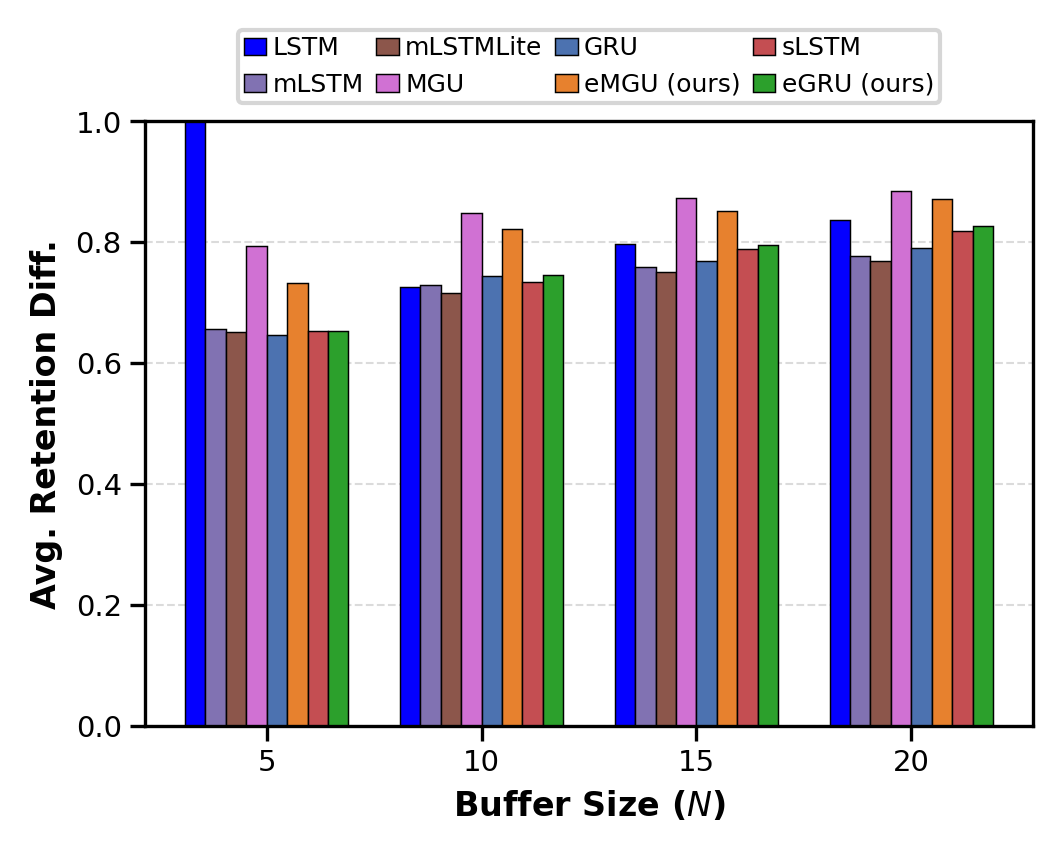

In [10]:
standard_gru = [
    0.6466584158415841,
     0.7441212871287128,
     0.7685643564356436,
     0.7908415841584159,
     0.8131188118811881,
      0.8152846534653465
]

standard_lstm = [
    1.0,
     0.7261757425742574,
     0.7964108910891089,
     0.8372524752475248,
     0.8589108910891089,
      0.8821163366336634
]

egru = [
    0.6531559405940595,
     0.7453589108910891,
     0.7954826732673267,
     0.8276608910891089,
     0.8536509900990099,
      0.8830445544554455
]

magru = [
    0.7323638613861386,
     0.8211633663366337,
     0.8524133663366337,
     0.8722153465346535,
     0.8898514851485149,
      0.8889232673267327
]

MGU = [
    0.7945544554455446,
     0.8483910891089109,
     0.8737623762376238,
     0.8845915841584159,
     0.8845915841584159,
      0.8972772277227723
]

sLSTM = [
    0.6534653465346535,
     0.7342202970297029,
     0.7883663366336634,
     0.8189975247524752,
     0.854269801980198,
      0.885519801980198
]

mLSTM = [
    0.6568688118811881,
     0.7298886138613861,
     0.7589727722772277,
     0.7778465346534653,
     0.8109529702970297,
      0.8298267326732673
]
mLSTMLite = [
 0.650680693069307,
  0.7165841584158416,
  0.7509282178217822,
  0.7691831683168316,
  0.812809405940594,
   0.8220915841584159
]


import matplotlib.pyplot as plt
import numpy as np

# Data
buffer_sizes = ["5", "10", "15", "20", 
                #"30", "50"
                ]
idx = [0, 1, 2, 3]  # Picks 50, 100, 500, 1000 from the 6 datapoints

# Slicing the arrays
data_lstm = [standard_lstm[i] for i in idx]
data_mlstm = [mLSTM[i] for i in idx]
data_mlite = [mLSTMLite[i] for i in idx]
data_mgu = [MGU[i] for i in idx]
data_gru = [standard_gru[i] for i in idx]
data_magru = [magru[i] for i in idx]
data_slstm = [sLSTM[i] for i in idx]
data_egru = [egru[i] for i in idx]

# --- 2. Figure Setup for 1-Column ---
fig, ax = plt.subplots(figsize=(3.4, 2.7), dpi=300)

x = np.arange(len(buffer_sizes))
width = 0.095  # Total group width = 8 * 0.095 = 0.76 (leaves 0.24 gap between groups)

# 8 models with contrasting colors and clean short names
models = [
    ("LSTM", data_lstm, "#0400FF"),
    ("mLSTM", data_mlstm, "#8172B2"),
    ("mLSTMLite", data_mlite, "#8C564B"),
    ("MGU", data_mgu, "#D071D3"),
    ("GRU", data_gru, "#4C72B0"),
    ("eMGU (ours)", data_magru, "#E7812E"),
    ("sLSTM", data_slstm, "#C44E52"),
    ("eGRU (ours)", data_egru, "#2CA02C"),
]

# Offsets for 8 bars centered at x: [-3.5, -2.5, -1.5, -0.5, 0.5, 1.5, 2.5, 3.5] * width
offsets = (np.arange(len(models)) - 3.5) * width

for (label, data, color), offset in zip(models, offsets):
    ax.bar(
        x + offset,
        data,
        width,
        label=label,
        color=color,
        edgecolor="black",
        linewidth=0.35,  # Razor-thin edge to separate touching bars
    )

# --- 3. Axes, Grid & Scale ---
ax.set_xlabel("Buffer Size ($N$)", fontsize=8, fontweight="bold", labelpad=3)
ax.set_ylabel("Avg. Retention Diff.", fontsize=8, fontweight="bold", labelpad=3)

ax.set_xticks(x)
ax.set_xticklabels(buffer_sizes, fontsize=7.5)

# Full headroom up to 1.0 (since standard_lstm reaches ~0.91)
ax.set_ylim(0, 1.0)
ax.set_yticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
ax.tick_params(axis="both", labelsize=7, pad=2)

ax.grid(axis="y", linestyle="--", alpha=0.45, linewidth=0.5)
ax.set_axisbelow(True)

# --- 4. Symmetrical 4-col x 2-row Legend ---
ax.legend(
    loc="lower center",
    bbox_to_anchor=(0.5, 1.01),
    ncol=4,  # Exactly 4 per row
    fontsize=6.0,
    frameon=True,
    handlelength=0.9,
    handletextpad=0.25,
    columnspacing=0.5,
    borderpad=0.25,
)

plt.tight_layout(pad=0.2)
plt.savefig("test5.pdf", bbox_inches="tight")
plt.show()
